# 저소득층 비율과 방 개수로 보스턴 주택가격을 설명할 수 있는가

**작성자:** OOO &nbsp;&nbsp;|&nbsp;&nbsp; **작성일:** 2026-07-28 

## #1. 분석 개요

**분석 주제**

> 공개 데이터인 Boston Housing Dataset으로 **지역 특성이 주택 중위가격을 얼마나 설명하는지** 확인한다.
> 실제 이해관계자가 있는 과제가 아니라, 선형회귀의 전 과정(품질 점검 → EDA → 모델링 → 진단 → 해석)을 연습하기 위한 분석이다.

**분석 질문**

- **Q1.** 주택 중위가격을 가장 크게 좌우하는 요인은 무엇인가?
- **Q2.** 주택 자체의 특성(방 개수 `RM`)과 동네의 사회경제적 특성(저소득층 비율 `LSTAT`) 중 무엇이 가격을 더 잘 설명하는가?
- **Q3.** 기계적인 변수 선택(VIF·후진소거)과 도메인 지식에 근거한 변수 제거 중 어느 쪽이 더 나은 모형을 만드는가?

**종속변수:** `MEDV` (연속형, 주택 중위가격 / 단위 $1,000) → 예측(회귀) 문제

**이번 노트북에서 연습할 기법**

> 왜도·첨도에 근거한 **로그 변환 자동 판정**, **VIF 기반 다중공선성 제거**, **후진소거법**,
> 전처리를 하나씩 누적한 **체크포인트 비교**, 선형회귀 **4대 가정 검정**과 위반 시의 조치(HC3 로버스트 표준오차),
> 그리고 **표준화계수(β)** 를 통한 영향력 비교를 연습한다.

#### 1-1. 분석 환경 설정

> 분석에 필요한 개별 함수 **import**

In [1]:
from jussam import load_data
from helpers import *
from IPython.display import display, Markdown

## 노트북에서 직접 호출하지는 않지만, 분석 환경(버전) 확인용으로 함께 참조한다.
import pandas as pd
import numpy as np
import statsmodels.api as sm

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


---
## #2. 데이터 소개

#### 2-1. 데이터 로딩

In [2]:
origin = load_data("boston")
origin.head()

📚 보스턴 인근 지역의 인구·환경·교육·범죄·세금 정보 등을 기반으로 주택의 중위가격(MEDV)을 예측하기 위해 수집된 대표적인 회귀 분석용 주택시장 데이터 (출처: https://www.kaggle.com/datasets/altavish/boston-housing-dataset)

    field    description
--  -------  ---------------------------------------------------------------------------------------------
 0  CRIM     타운별 1인당 범죄율 (Per capita crime rate by town)
 1  ZN       25,000 sqft 이상 주거용 대지 비율 (Proportion of residential land zoned for large lots)
 2  INDUS    비소매 상업구역 비율 (Proportion of non-retail business acres per town)
 3  CHAS     명목형, 찰스강 인접 여부 (Charles River dummy variable: 1 if tract bounds river; 0 otherwise)
 4  NOX      대기 오염 정도 (Nitric oxides concentration, parts per 10 million)
 5  RM       주택당 평균 방(Room) 수 (Average number of rooms per dwelling)
 6  AGE      1940년 이전 건축 비율 (Proportion of owner-occupied units built prior to 1940)
 7  DIS      5개 주요 고용센터까지의 거리 (Weighted distances to five Boston employment centers)
 8  RAD      고속도로 접근성 지수 (Index of accessibility to radial highways)
 9  T

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0,0.538,6.575,65.200,4.090,1,296,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0,0.469,6.421,78.900,4.967,2,242,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0,0.469,7.185,61.100,4.967,2,242,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0,0.458,6.998,45.800,6.062,3,222,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0,0.458,7.147,54.200,6.062,3,222,18.700,396.900,5.330,36.200


In [3]:
origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


#### 2-2. 출처와 분석 단위

- **출처:** Boston Housing Dataset (Harrison & Rubinfeld, 1978) — Kaggle 재배포본 `altavish/boston-housing-dataset`
- **수집 기간:** 1970년 미국 인구조사(U.S. Census) 자료 기준
- **분석 단위:** 1행 = ( 보스턴 광역권의 인구조사 구역(census tract) 1곳 )

#### 2-3. 변수 정의서

| 변수명 | 의미 | 역할 | 척도 | 단위 |
|---|---|---|---|---|
| `MEDV` | 주택 중위가격 | 종속변수 | 연속형 | 천 달러($1,000) |
| `CRIM` | 1인당 범죄율 | 독립변수 | 연속형 | 건/인 |
| `ZN` | 25,000 sqft 이상 주거용 대지 비율 | 독립변수 | 연속형 | % |
| `INDUS` | 비소매 상업구역 비율 | 독립변수 | 연속형 | % |
| `CHAS` | 찰스강 인접 여부 | 독립변수 | **명목형(2집단)** | 1=인접 / 0=비인접 |
| `NOX` | 질소산화물 농도(대기오염) | 독립변수 | 연속형 | 1천만분율 |
| `RM` | 주택당 평균 방 개수 | 독립변수 | 연속형 | 개 |
| `AGE` | 1940년 이전 건축 비율 | 독립변수 | 연속형 | % |
| `DIS` | 5개 고용센터까지 가중거리 | 독립변수 | 연속형 | 거리지수 |
| `RAD` | 고속도로 접근성 지수 | 독립변수 | 연속형(사실상 서열) | 지수(1~24) |
| `TAX` | 재산세율 | 독립변수 | 연속형 | $/$10,000 |
| `PTRATIO` | 학생-교사 비율 | 독립변수 | 연속형 | 명/명 |
| `B` | 흑인 비율 지수 1000(Bk−0.63)² | 독립변수 | 연속형 | 지수 |
| `LSTAT` | 저소득층 인구 비율 | 독립변수 | 연속형 | % |

#### 2-4. 초기 가설

- **H1.** 방 개수(`RM`)가 많을수록 주택가격이 높을 것이다.
- **H2.** 저소득층 비율(`LSTAT`)이 높을수록 주택가격이 낮을 것이다.
- **H3.** 대기오염(`NOX`)이 심하고 범죄율(`CRIM`)이 높을수록 주택가격이 낮을 것이다.
- **H4.** 찰스강에 인접(`CHAS`=1)하면 주택가격이 높을 것이다.

#### 2-5. 데이터의 한계

- **시점:** 1970년 인구조사 기반의 **횡단면 데이터**다. 현재 시장에 그대로 적용할 수 없고, 시간에 따른 변화도 볼 수 없다.
- **관측 단위:** 개별 주택이 아니라 **인구조사 구역**이다. 결과는 "동네 평균"에 대한 설명이며 개별 주택 가격 예측에는 쓸 수 없다.
- **종속변수 절단:** `MEDV`가 50에서 **상한 절단(censoring)** 되어 있다(50에 정확히 겹친 관측치 16건). 고가 구간의 정보가 손실되어 있다.
- **윤리적 문제:** `B`는 인종 구성을 지수화한 변수로 오늘날 기준에서 사용이 부적절하다고 평가되어, scikit-learn 1.2에서 이 데이터셋 자체가 제거되었다.
  - 이 노트북에서는 **기법 연습 목적**으로만 데이터를 사용하며, `B`의 계수를 사회적 해석의 근거로 삼지 않는다.

---
## #3. 품질 점검 및 기본 전처리

> 이 장에서는 **삭제만** 수행한다. 결측치·이상치의 **대체는 #6**의 전처리 파이프라인에서 한다.
> 전처리 기준이 분석 설계보다 앞서면 판단 근거가 사라지기 때문이다.

#### 3-1. 데이터 구조 점검

##### 1) 자료형 확인

In [4]:
origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


##### 2) 자료형 변환

`CHAS`는 0/1로 기록된 코드값이므로 연속형이 아니라 명목형으로 변환한다.

In [5]:
df1 = my_qtcheck.set_type(origin, as_category=['CHAS'])
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    int64   
 9   TAX      506 non-null    int64   
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(1), float64(11), int64(2)
memory usage: 52.1 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0,0.538,6.575,65.200,4.090,1,296,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0,0.469,6.421,78.900,4.967,2,242,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0,0.469,7.185,61.100,4.967,2,242,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0,0.458,6.998,45.800,6.062,3,222,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0,0.458,7.147,54.200,6.062,3,222,18.700,396.900,5.330,36.200


##### 3) 중복 검사 및 중복 데이터 삭제

In [6]:
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0,0.538,6.575,65.200,4.090,1,296,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0,0.469,6.421,78.900,4.967,2,242,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0,0.469,7.185,61.100,4.967,2,242,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0,0.458,6.998,45.800,6.062,3,222,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0,0.458,7.147,54.200,6.062,3,222,18.700,396.900,5.330,36.200


**해석**

- **자료형:** `CHAS` 하나만 명목형으로 변환하면 되고, 나머지 13개는 모두 수치형 그대로 사용한다.
- **중복 행:** **0건** — 삭제 대상이 없다.
- **불필요한 열:** `info()` 로 확인한 14개 열은 모두 지역 특성을 담은 실측값이다. ID·인덱스 같은 **식별자 열이 없으므로 삭제할 열도 없다.**
- **주의할 변수:** `RAD`는 1~24의 접근성 **지수**이므로 연속형으로 두되, 사실상 서열형에 가깝다는 점을 기억하고 진행한다.

#### 3-2. 데이터 품질 점검

##### 1) 결측치 확인

In [7]:
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
CRIM,0,0.000
ZN,0,0.000
INDUS,0,0.000
CHAS,0,0.000
NOX,0,0.000
RM,0,0.000
AGE,0,0.000
DIS,0,0.000
RAD,0,0.000
TAX,0,0.000


##### 2) 이상치 확인 (IQR 기준)

`numerical_summary()` 는 기술통계량과 함께 **IQR × 1.5 경계**를 벗어난 이상치의 개수·비율을 계산한다.

In [8]:
num_desc = my_qtcheck.numerical_summary(df2)
num_desc

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
CRIM,506.000,3.614,8.602,0.006,0.082,0.257,3.677,88.976,13.087,large_diff,3.595,9.070,-5.311,66,0.130,0,0.000,66,0.130,5.223,right tail,37.131,leptokurtic,log
ZN,506.000,11.364,23.322,0.000,0.000,0.000,12.500,100.000,inf,large_diff,12.500,31.250,-18.750,68,0.134,0,0.000,68,0.134,2.226,right tail,4.032,leptokurtic,log1p
INDUS,506.000,11.137,6.860,0.460,5.190,9.690,18.100,27.740,0.149,diff,12.910,37.465,-14.175,0,0.000,0,0.000,0,0.000,0.295,symmetric,-1.234,platykurtic,none
NOX,506.000,0.555,0.116,0.385,0.449,0.538,0.624,0.871,0.031,similar,0.175,0.886,0.187,0,0.000,0,0.000,0,0.000,0.729,right tail,-0.065,platykurtic,none
RM,506.000,6.285,0.703,3.561,5.885,6.208,6.623,8.780,0.012,similar,0.738,7.731,4.778,22,0.043,8,0.016,30,0.059,0.404,symmetric,1.892,leptokurtic,none
AGE,506.000,68.575,28.149,2.900,45.025,77.500,94.075,100.000,0.115,diff,49.050,167.650,-28.550,0,0.000,0,0.000,0,0.000,-0.599,left tail,-0.968,platykurtic,none
DIS,506.000,3.795,2.106,1.130,2.100,3.207,5.188,12.127,0.183,diff,3.088,9.821,-2.532,5,0.010,0,0.000,5,0.010,1.012,right tail,0.488,leptokurtic,log
RAD,506.000,9.549,8.707,1.000,4.000,5.000,24.000,24.000,0.910,large_diff,20.000,54.000,-26.000,0,0.000,0,0.000,0,0.000,1.005,right tail,-0.867,platykurtic,log
TAX,506.000,408.237,168.537,187.000,279.000,330.000,666.000,711.000,0.237,diff,387.000,1246.500,-301.500,0,0.000,0,0.000,0,0.000,0.670,right tail,-1.142,platykurtic,none
PTRATIO,506.000,18.456,2.165,12.600,17.400,19.050,20.200,22.000,0.031,similar,2.800,24.400,13.200,0,0.000,15,0.030,15,0.030,-0.802,left tail,-0.285,platykurtic,none


**해석** — 결측치 ( 0 )건, 이상치 ( 0 )건 삭제. 관측치 ( 506 ) → ( 506 ).

삭제 기준과 그렇게 정한 이유

- **결측치는 0건**이라 삭제 대상이 없었다.
- **IQR 이상치는 삭제하지 않았다.**
  - `B` 77건(15.2%), `ZN` 68건(13.4%), `CRIM` 66건(13.0%), `MEDV` 40건(7.9%) 등 총 300건 가까이 검출된다.
  - 이들은 오류값이 아니라 **범죄율이 극단적으로 높은 도심 구역**처럼 실재하는 지역 특성이다.
  - 전량 삭제하면 표본의 절반 가까이가 사라지고 분석 대상 모집단 자체가 바뀐다.
  - → 삭제 대신 **#6의 `2_이상치대체` 체크포인트에서 IQR 경계값으로 대체**하고, 그 효과를 성능표로 검증한다.
- **`MEDV` = 50 인 16건(상한 절단값)도 남겼다.**
  - 삭제가 타당한 후보이지만, 삭제 여부에 따라 결과가 달라지는 것을 감추지 않기 위해 **원자료 그대로 두고 #7-3 한계에 명시**한다.

#### 3-3. 기술통계량

##### 1) 연속형 변수의 기술 통계량을 전치 형태로 출력

In [9]:
num_desc.T

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000
mean,3.614,11.364,11.137,0.555,6.285,68.575,3.795,9.549,408.237,18.456,356.674,12.653,22.533
std,8.602,23.322,6.860,0.116,0.703,28.149,2.106,8.707,168.537,2.165,91.295,7.141,9.197
min,0.006,0.000,0.460,0.385,3.561,2.900,1.130,1.000,187.000,12.600,0.320,1.730,5.000
25%,0.082,0.000,5.190,0.449,5.885,45.025,2.100,4.000,279.000,17.400,375.377,6.950,17.025
50%,0.257,0.000,9.690,0.538,6.208,77.500,3.207,5.000,330.000,19.050,391.440,11.360,21.200
75%,3.677,12.500,18.100,0.624,6.623,94.075,5.188,24.000,666.000,20.200,396.225,16.955,25.000
max,88.976,100.000,27.740,0.871,8.780,100.000,12.127,24.000,711.000,22.000,396.900,37.970,50.000
rel_diff,13.087,inf,0.149,0.031,0.012,0.115,0.183,0.910,0.237,0.031,0.089,0.114,0.063
rdiff_flag,large_diff,large_diff,diff,similar,similar,diff,diff,large_diff,diff,similar,similar,diff,similar


##### 2) 명목형 변수의 기술 통계량 확인

In [10]:
cat_desc = my_qtcheck.categorical_summary(df2)
cat_desc

📊 컬럼 'CHAS'의 value_counts():


,count
CHAS,
0,471
1,35


,CHAS
count,506
unique,2
top,0
freq,471


**해석**

- **중심수준:** `MEDV`의 평균은 22.5천 달러, 중앙값은 21.2천 달러로 비슷하다(상대 차이 6.3%).
  독립변수는 단위가 제각각이다 — `TAX`는 평균 408, `NOX`는 0.55로 **약 700배 차이**가 난다. 계수를 직접 비교할 수 없으므로 #8에서 표준화계수(β)로 본다.
- **퍼짐 정도:** `CRIM`(표준편차 8.60, 최댓값 88.98)과 `ZN`(23.32)의 산포가 압도적으로 크다. 두 변수 모두 0 근처에 대부분이 몰려 있고 소수의 극단값이 꼬리를 만든다.
- **비대칭 신호:** 왜도 기준 변환 후보는 `CRIM`(+5.22), `ZN`(+2.23), `MEDV`(+1.11), `DIS`(+1.01), `RAD`(+1.01), `LSTAT`(+0.91)로 **우측 꼬리**이고,
  `B`(−2.89)만 **좌측 꼬리**다. `log_need` 열이 각각 `log` / `log1p` / `reverse_log1p`로 판정해 준다 → **#6의 `1_로그변환` 체크포인트 대상**.
- **첨도:** `CRIM`(37.13)과 `B`(7.23)가 극단적으로 뾰족하다. 로그 변환으로 완화될 것으로 기대한다.
- 명목형 `CHAS`는 506건 중 인접(1)이 35건뿐인 **불균형 변수**다. 집단 크기 차이가 크므로 검정 결과를 조심해서 읽어야 한다.

#### 3-4. 이 장의 결론

- 분석용 데이터 최종 크기: **506행 × 14열** (삭제 없음)
- 삭제 내역과 근거:
  - 중복 0건 / 결측 0건 → 삭제 없음
  - 식별자 열 없음 → 삭제할 열 없음
  - IQR 이상치는 **삭제하지 않고 #6에서 경계값 대체 여부를 성능으로 비교** → 오류값이 아니라 실재하는 지역 특성이고, 삭제하면 표본이 절반 가까이 사라짐

---
## #4. 탐색적 데이터 분석 (EDA)

#### 4-1. 분포 확인

##### 1) 타입 변환 (명목형 확정)

명목형 기술통계량 표의 컬럼명이 명목형 변수 목록이다.

In [11]:
df = my_qtcheck.set_type(df2, as_category=cat_desc.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    int64   
 9   TAX      506 non-null    int64   
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(1), float64(11), int64(2)
memory usage: 52.1 KB


##### 2) 변수 유형 분류

In [12]:
## 종속변수
target = "MEDV"
## 종속변수 연속형 여부
target_is_continuous = True

## 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df)
## 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)

if target_is_continuous:
    ## 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    ## 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)

종속변수 : MEDV
종속변수 유형: 연속형
명목형   : ['CHAS']
연속형   : ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


##### 3) 컬럼 의미를 정리한 딕셔너리

In [13]:
column_means = {
    "MEDV":    "주택 중위가격($1,000)",
    "CRIM":    "1인당 범죄율",
    "ZN":      "대형 주거용지 비율(%)",
    "INDUS":   "비소매 상업구역 비율(%)",
    "CHAS":    "찰스강 인접 여부",     ## 1 = 인접, 0 = 비인접
    "NOX":     "질소산화물 농도",
    "RM":      "평균 방 개수",
    "AGE":     "1940년 이전 건축 비율(%)",
    "DIS":     "고용센터까지의 거리",
    "RAD":     "고속도로 접근성 지수",
    "TAX":     "재산세율",
    "PTRATIO": "학생-교사 비율",
    "B":       "흑인 비율 지수",
    "LSTAT":   "저소득층 비율(%)",
}

##### 4) EDA 범위 정리

| 종속유형 | 독립유형 | 분석 유형 | 대상 변수 | 적용 여부 | 비고 |
|---|---|---|---|---|---|
| 연속형 | 연속형 | 상관분석 | 연속형 독립변수 12종 → MEDV | ✅ 적용 | 종속·설명 모두 연속형 |
| 연속형 | 명목형(2집단) | T검정 | CHAS → MEDV | ✅ 적용 | 2집단 명목형 1종 |
| 연속형 | 명목형(3집단+) | ANOVA | — | ❌ 미적용 | 3집단 이상 명목형 없음 |
| 명목형(2집단) | 연속형 | T검정 | — | ❌ 미적용 | 종속변수 타입이 연속형 |
| 명목형(2집단) | 명목형(2집단) | 교차분석 | — | ❌ 미적용 | 종속변수 타입이 연속형 |
| 명목형(2집단) | 명목형(3집단+) | 교차분석 | — | ❌ 미적용 | 종속변수 타입이 연속형 |
| 명목형(3집단+) | 연속형 | ANOVA | — | ❌ 미적용 | 종속변수 타입이 연속형 |
| 명목형(3집단+) | 명목형(2집단) | 교차분석 | — | ❌ 미적용 | 종속변수 타입이 연속형 |
| 명목형(3집단+) | 명목형(3집단+) | 교차분석 | — | ❌ 미적용 | 종속변수 타입이 연속형 |

- 종속변수 `MEDV`가 **연속형**이므로 상위 3개 행만 후보가 되고, 그 중 해당 독립유형 변수가 실제로 존재하는 행만 적용된다.
- 연속형 독립변수 12종: `CRIM`, `ZN`, `INDUS`, `NOX`, `RM`, `AGE`, `DIS`, `RAD`, `TAX`, `PTRATIO`, `B`, `LSTAT`

##### 5) 연속형 종속변수에 대한 단변량 분석

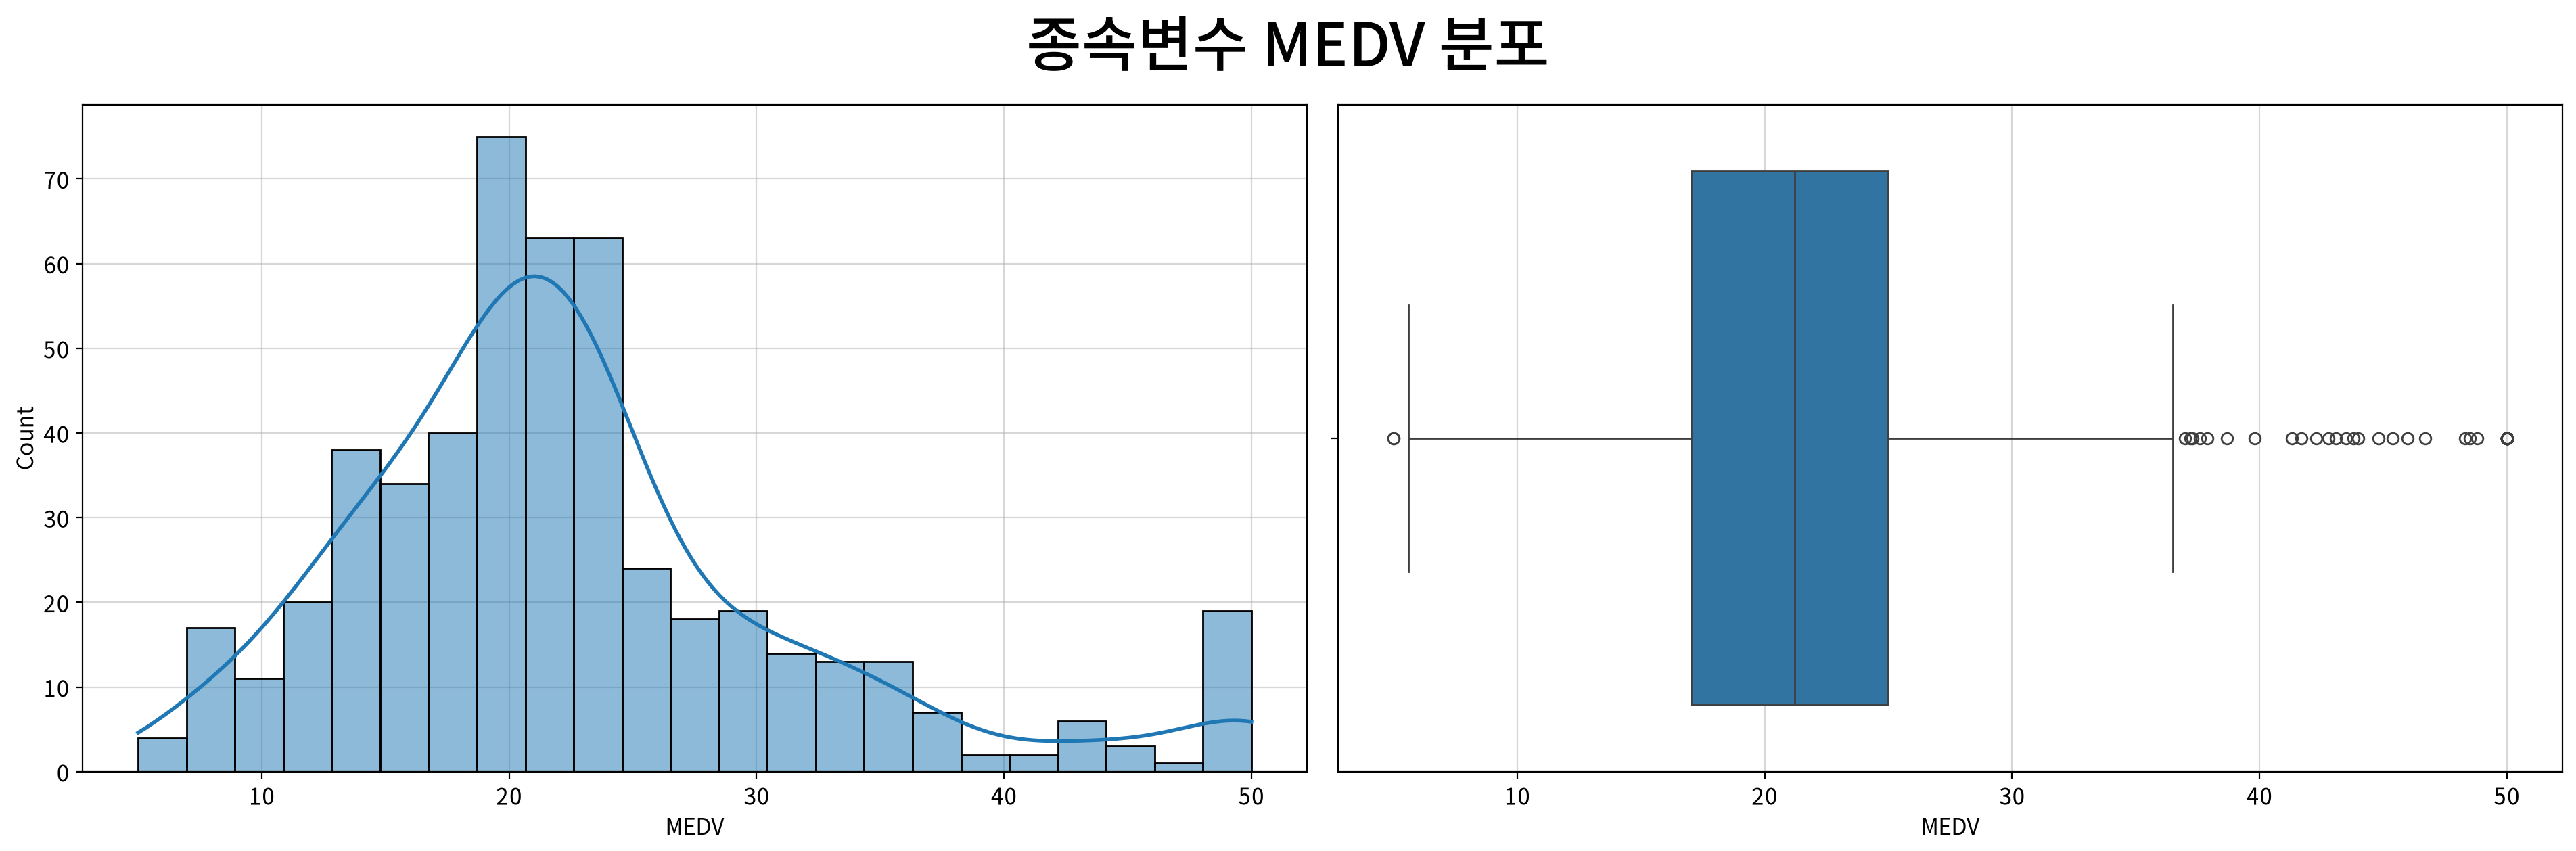

,MEDV
count,506.000
mean,22.533
std,9.197
min,5.000
25%,17.025
50%,21.200
75%,25.000
max,50.000
rel_diff,0.063
rdiff_flag,similar


In [14]:
## 1행 2열 서브플롯 구성
## -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2,
            title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

## 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

**해석**

- **분포 모양:** **단봉·우편향**(왜도 +1.11, 첨도 +1.50). 20천 달러 부근에 봉우리가 있고 오른쪽으로 꼬리가 길다.
- **이상치:** IQR 기준 상단 38건 / 하단 2건, 합계 40건(7.9%).
- **이산점(군집):** 최댓값 50에 **16건이 정확히 겹쳐 있다.** 분포의 꼬리가 아니라 조사 당시 **상한에서 값을 잘라 기록한 절단(censoring)** 이다.
- **조치:** 우측 꼬리가 뚜렷하므로 **로그변환 대상**이다(`log_need` = `log`).
- **해석 방식의 변화:** 종속변수를 로그로 바꾸면 계수는 **절대 금액이 아니라 % 변화**로 읽어야 한다.

##### 6) 연속형 독립변수에 대한 단변량 분석

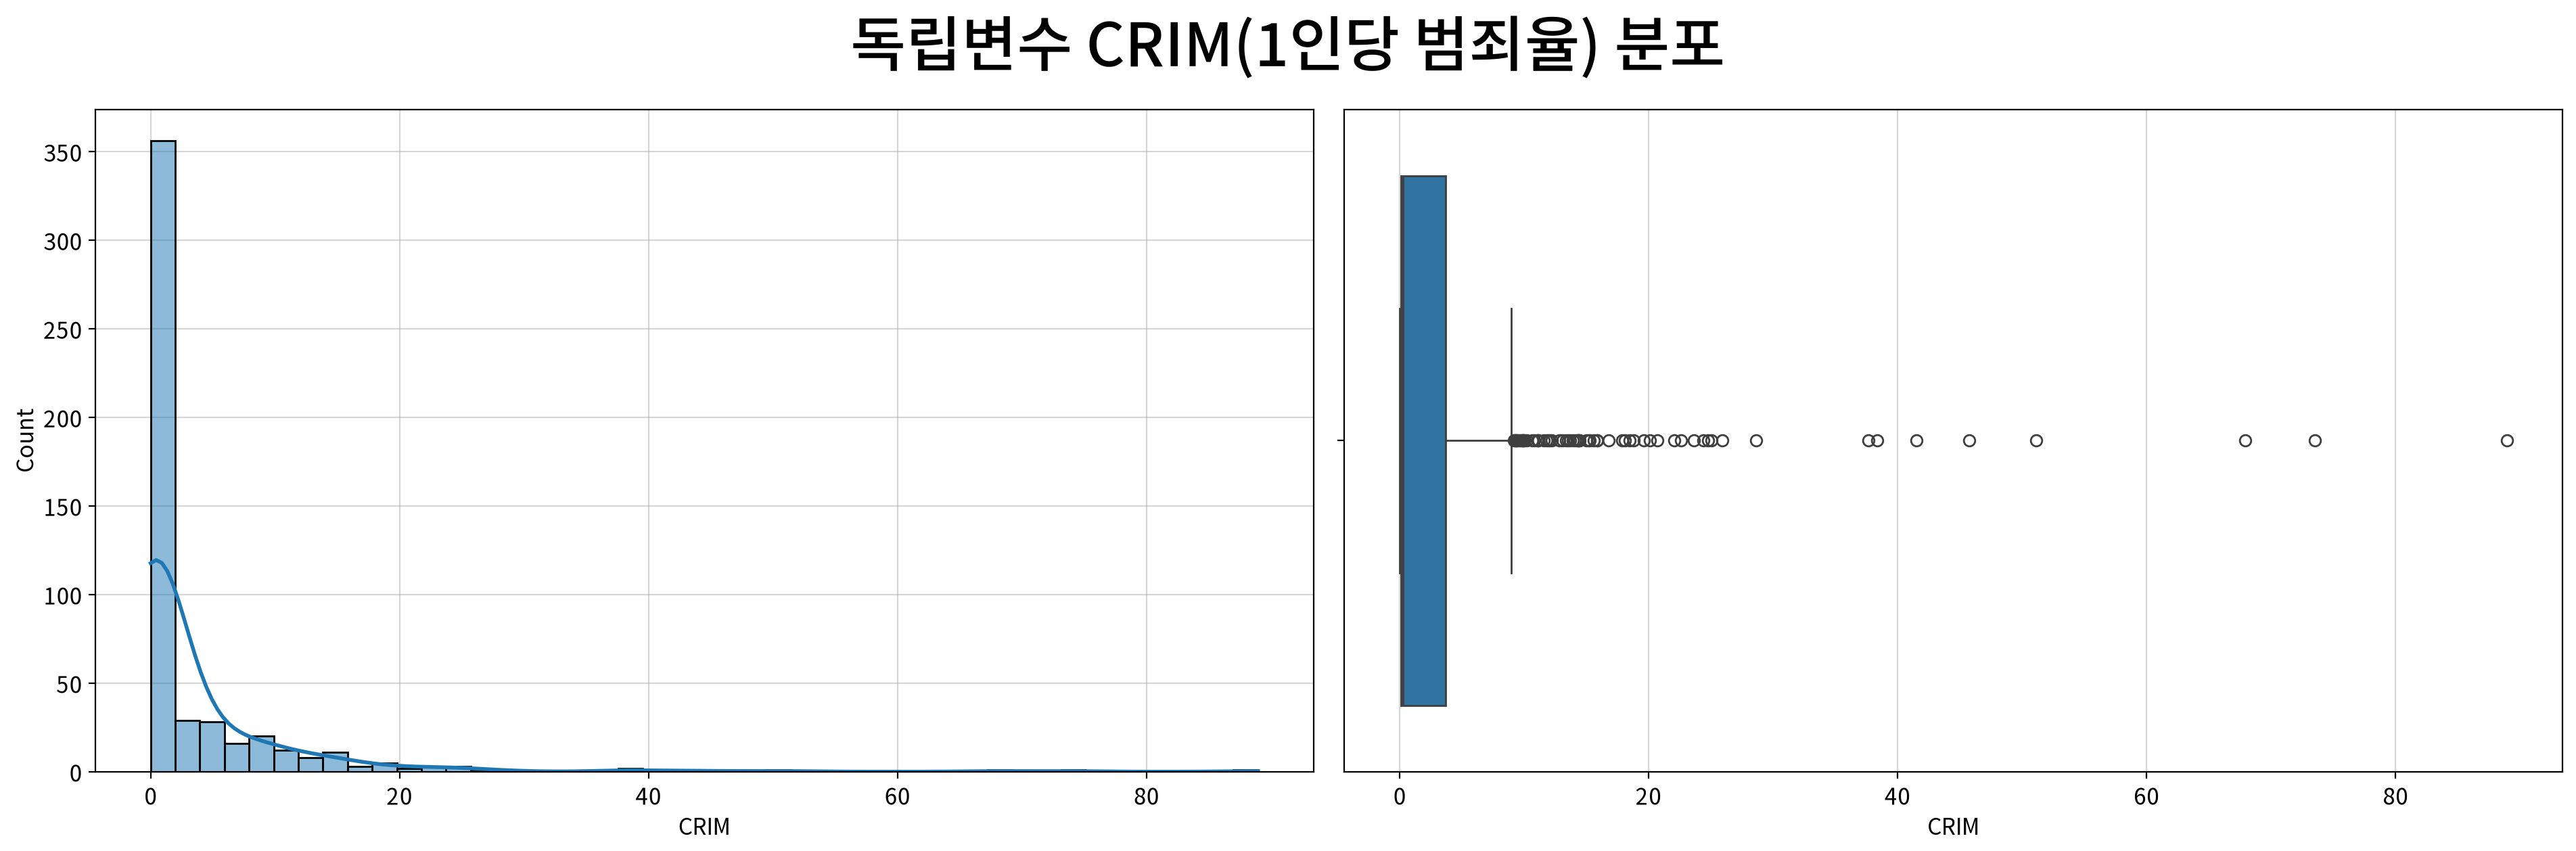

,CRIM
count,506.000
mean,3.614
std,8.602
min,0.006
25%,0.082
50%,0.257
75%,3.677
max,88.976
rel_diff,13.087
rdiff_flag,large_diff


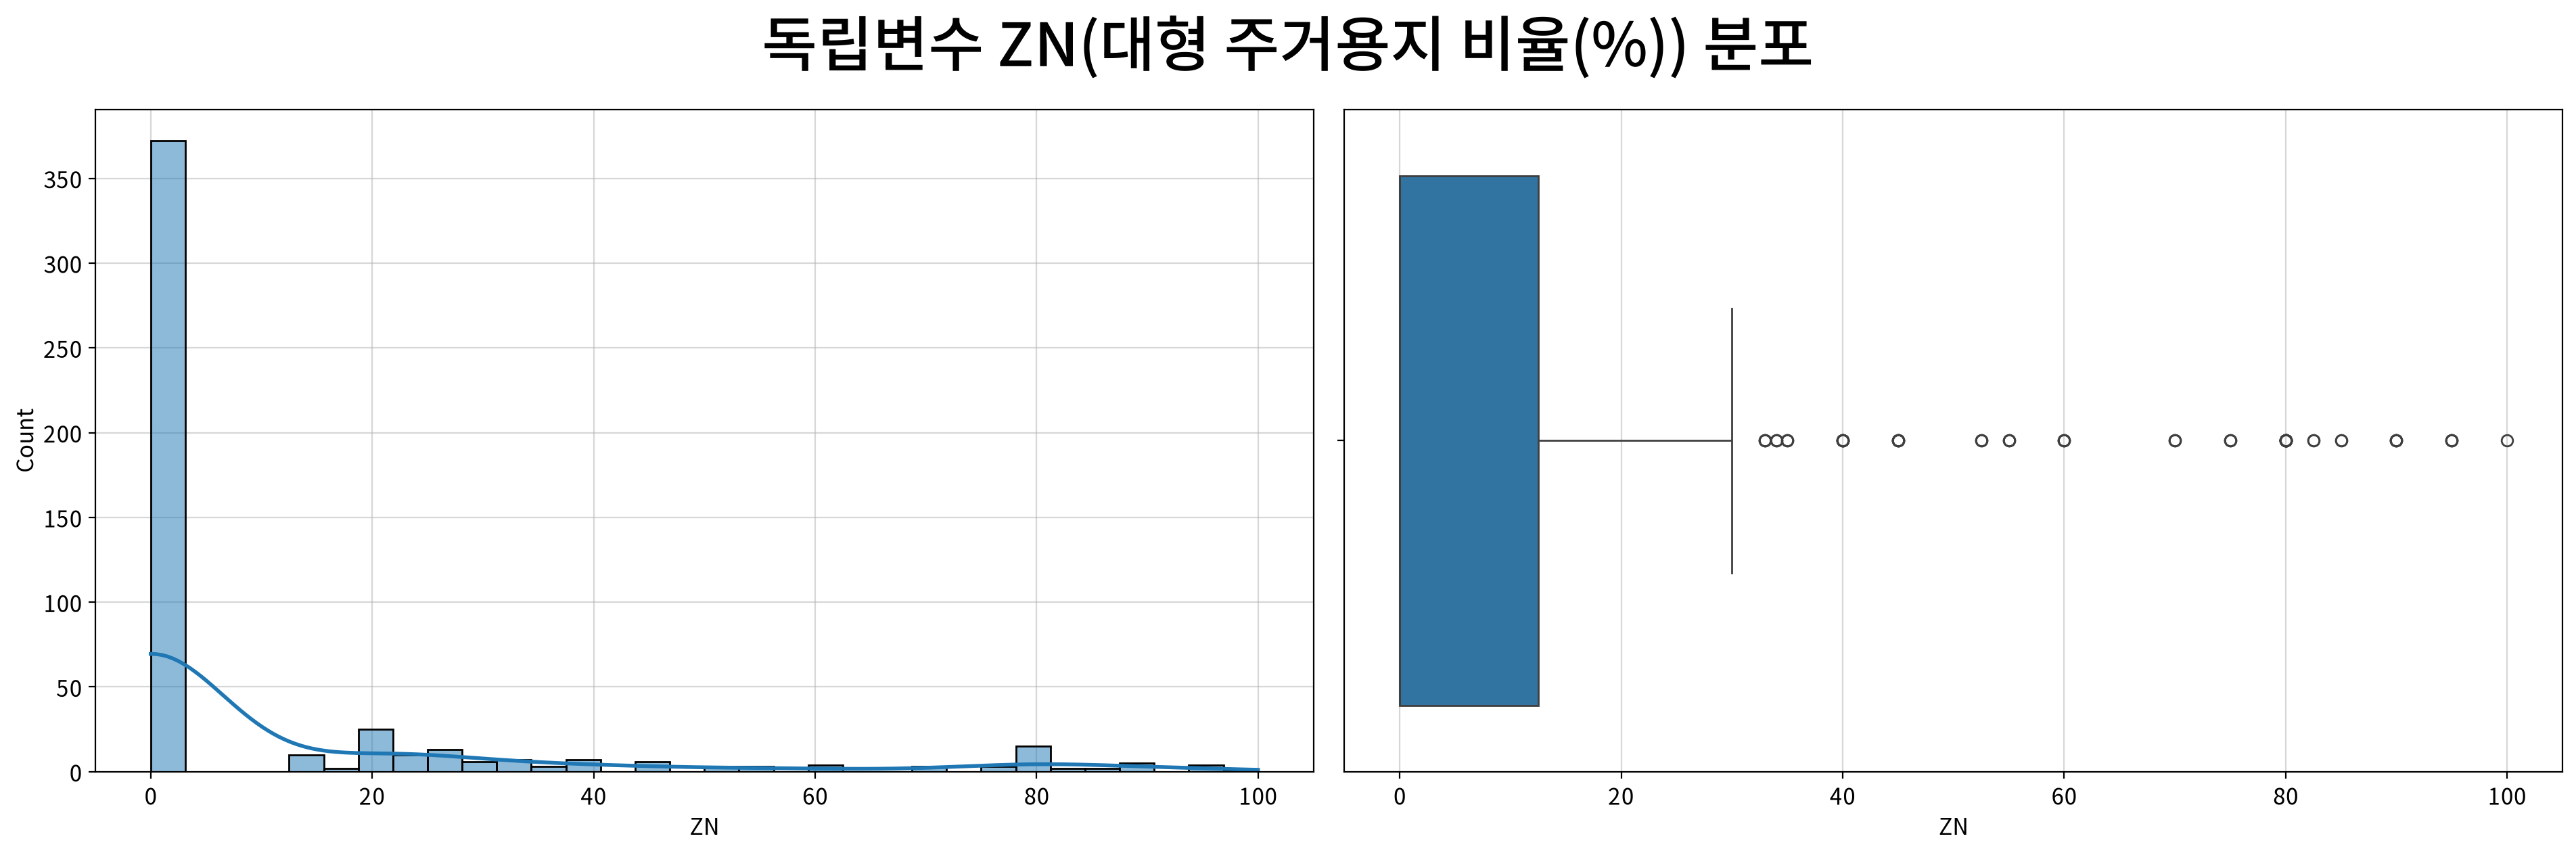

,ZN
count,506.000
mean,11.364
std,23.322
min,0.000
25%,0.000
50%,0.000
75%,12.500
max,100.000
rel_diff,inf
rdiff_flag,large_diff


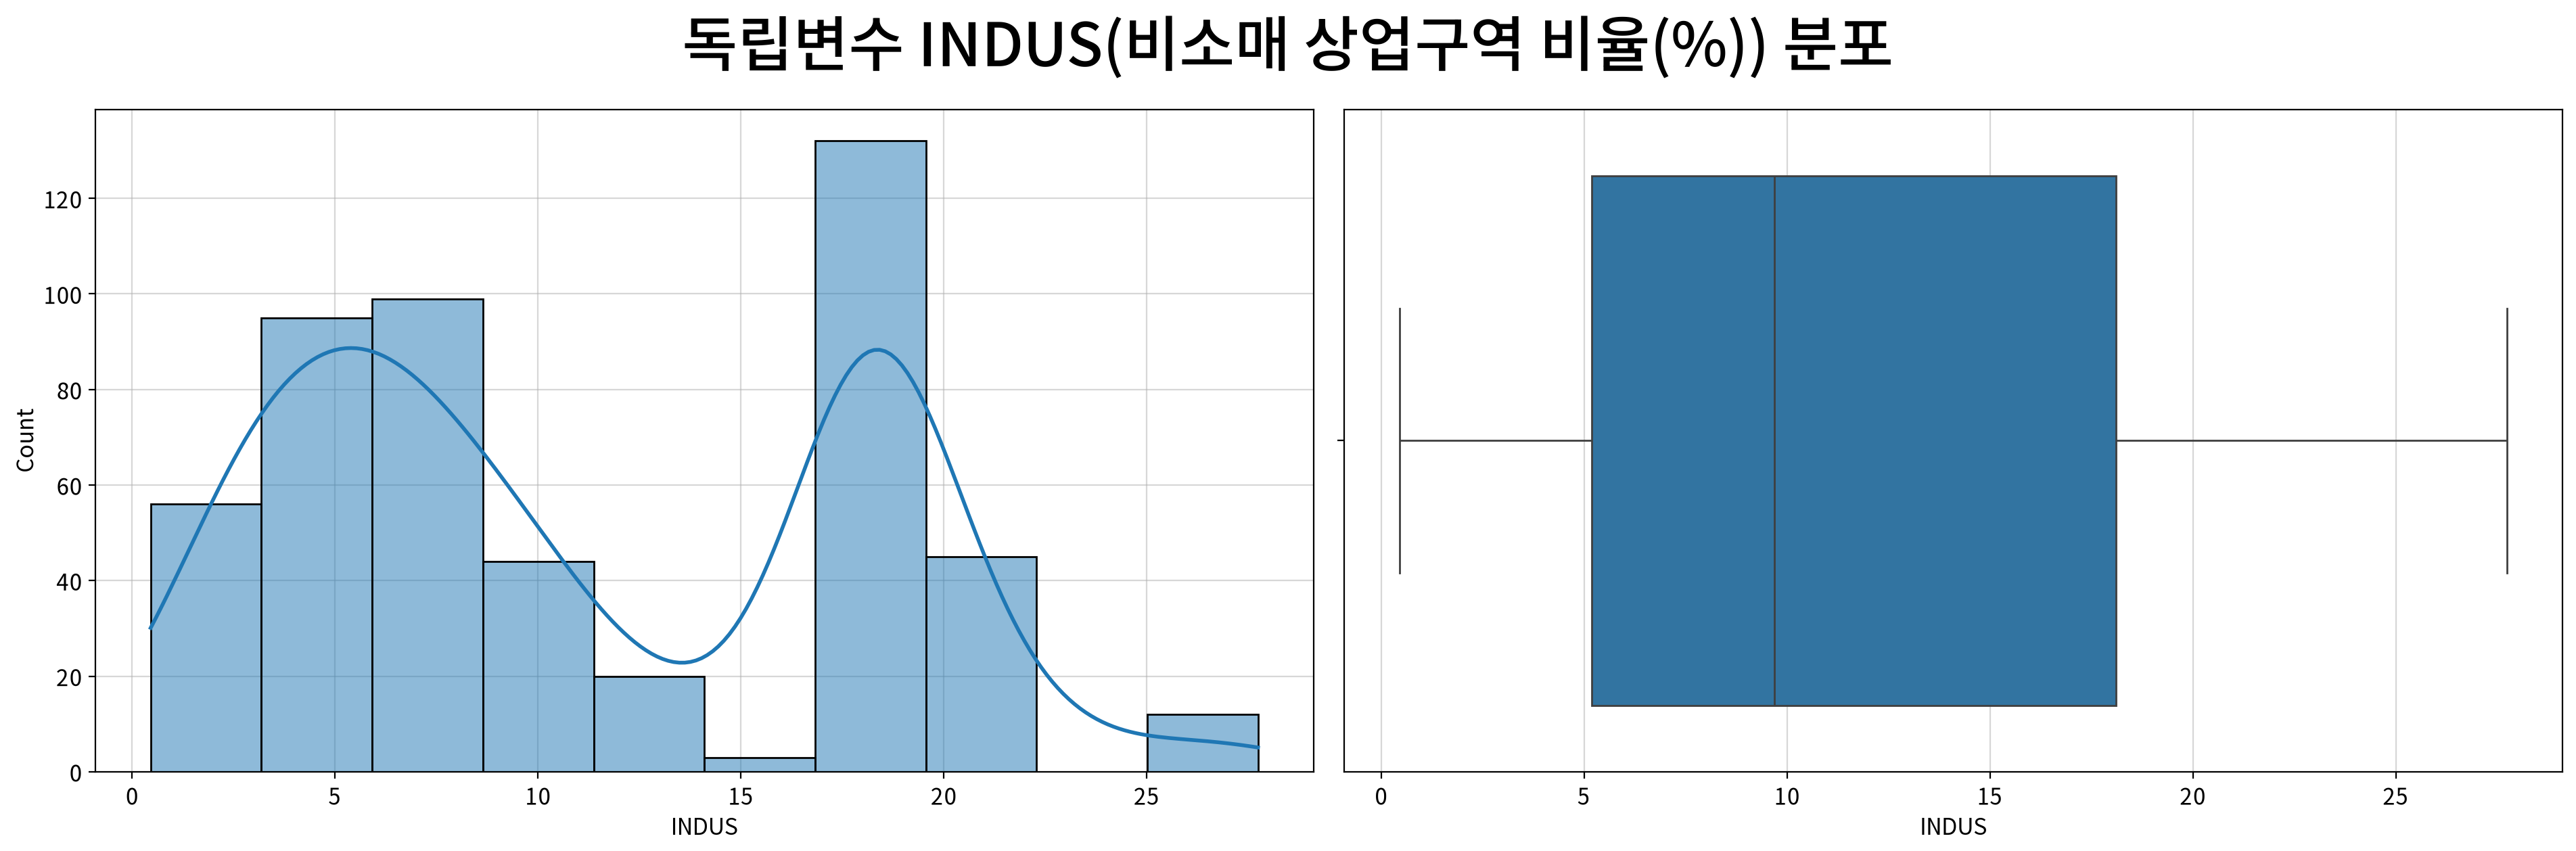

,INDUS
count,506.000
mean,11.137
std,6.860
min,0.460
25%,5.190
50%,9.690
75%,18.100
max,27.740
rel_diff,0.149
rdiff_flag,diff


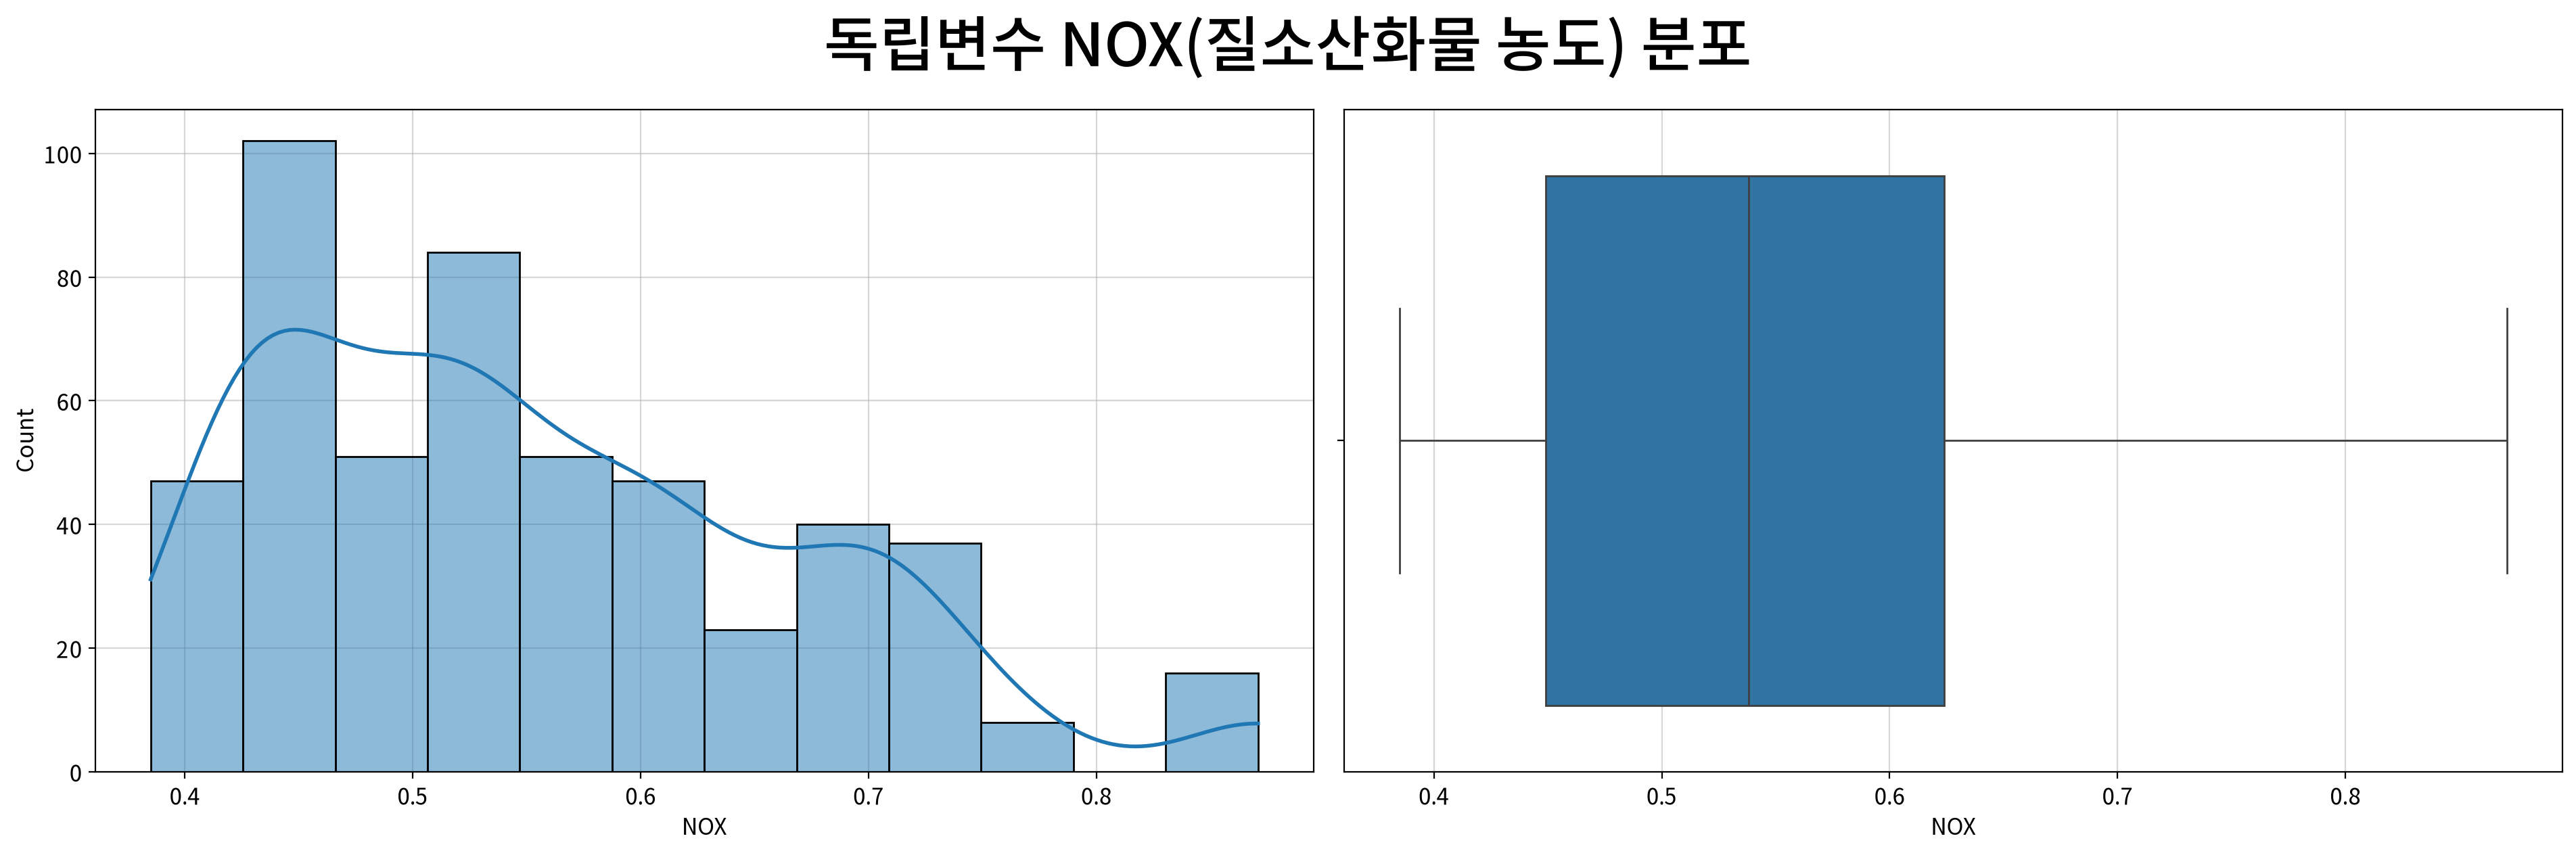

,NOX
count,506.000
mean,0.555
std,0.116
min,0.385
25%,0.449
50%,0.538
75%,0.624
max,0.871
rel_diff,0.031
rdiff_flag,similar


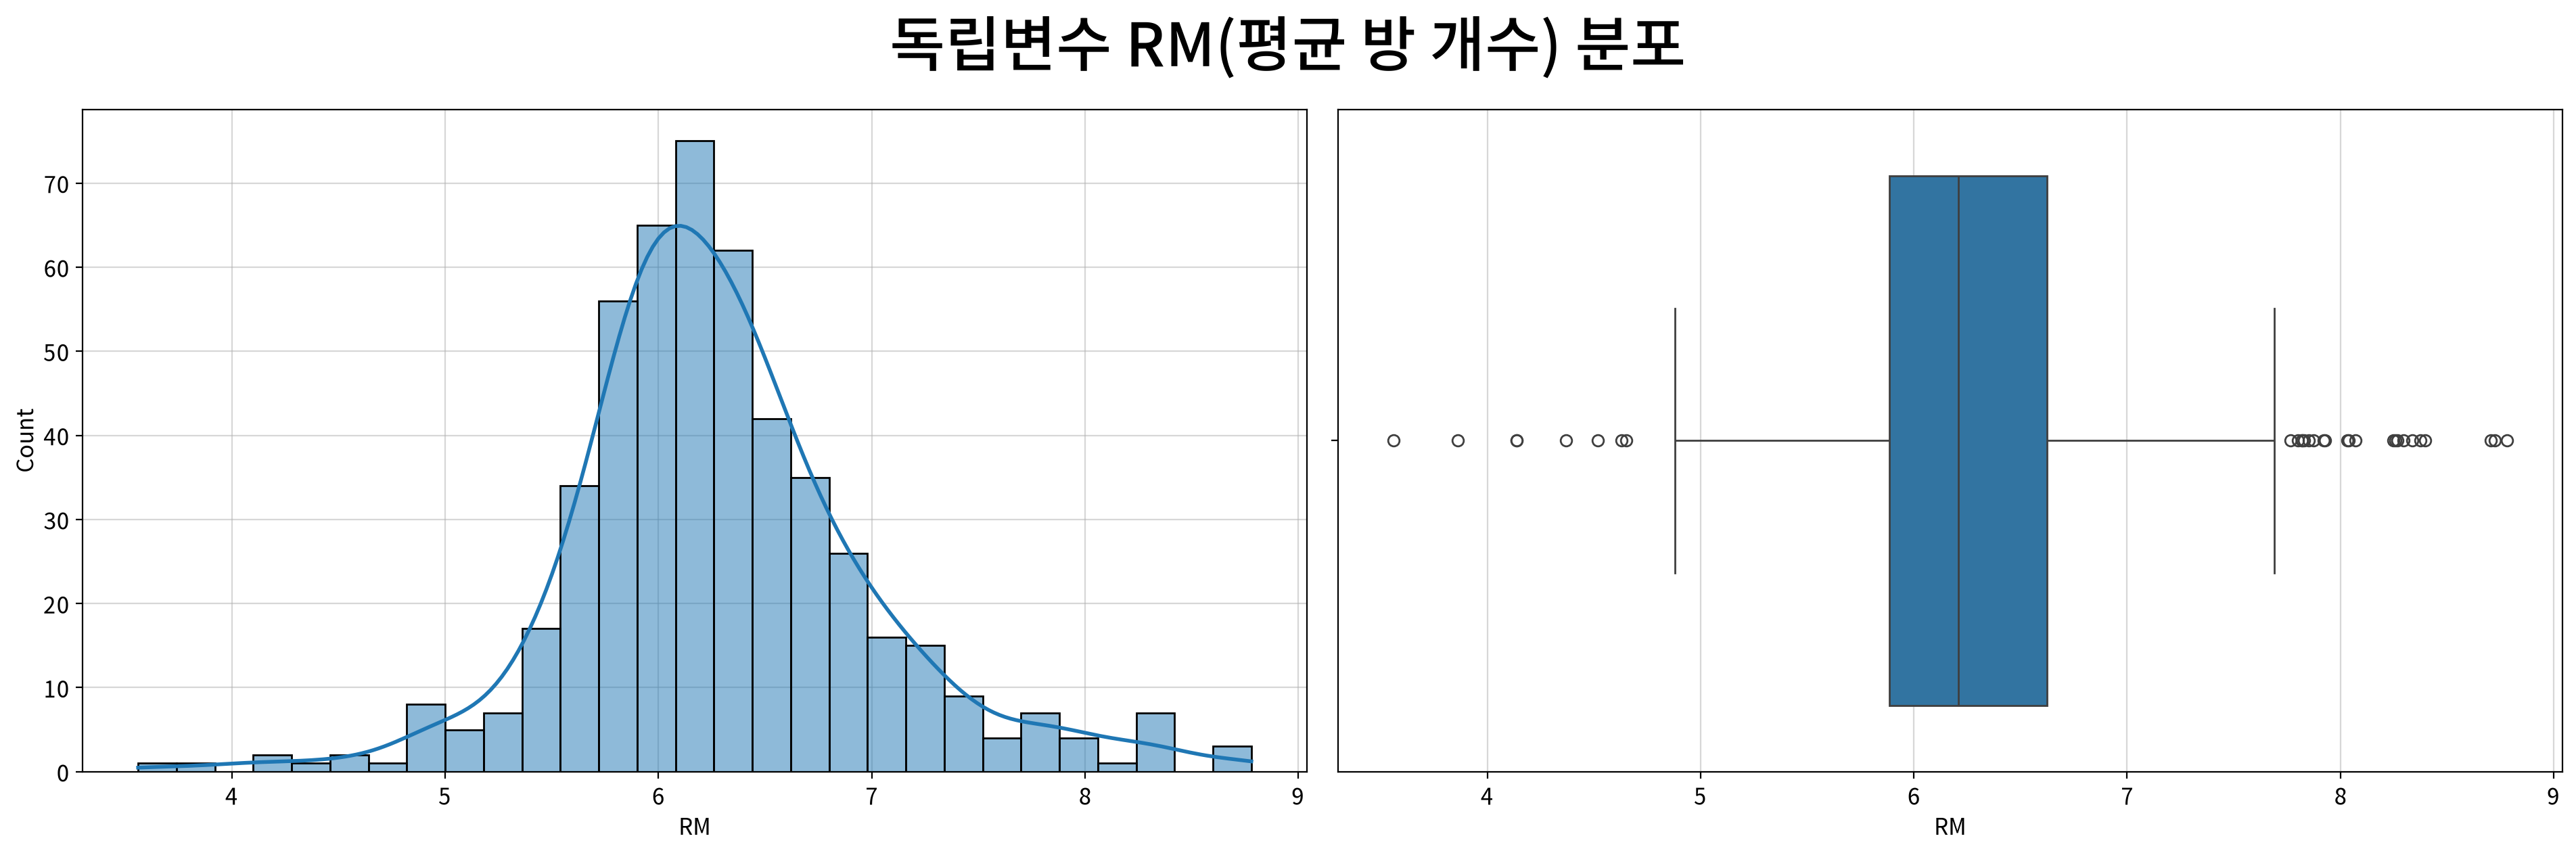

,RM
count,506.000
mean,6.285
std,0.703
min,3.561
25%,5.885
50%,6.208
75%,6.623
max,8.780
rel_diff,0.012
rdiff_flag,similar


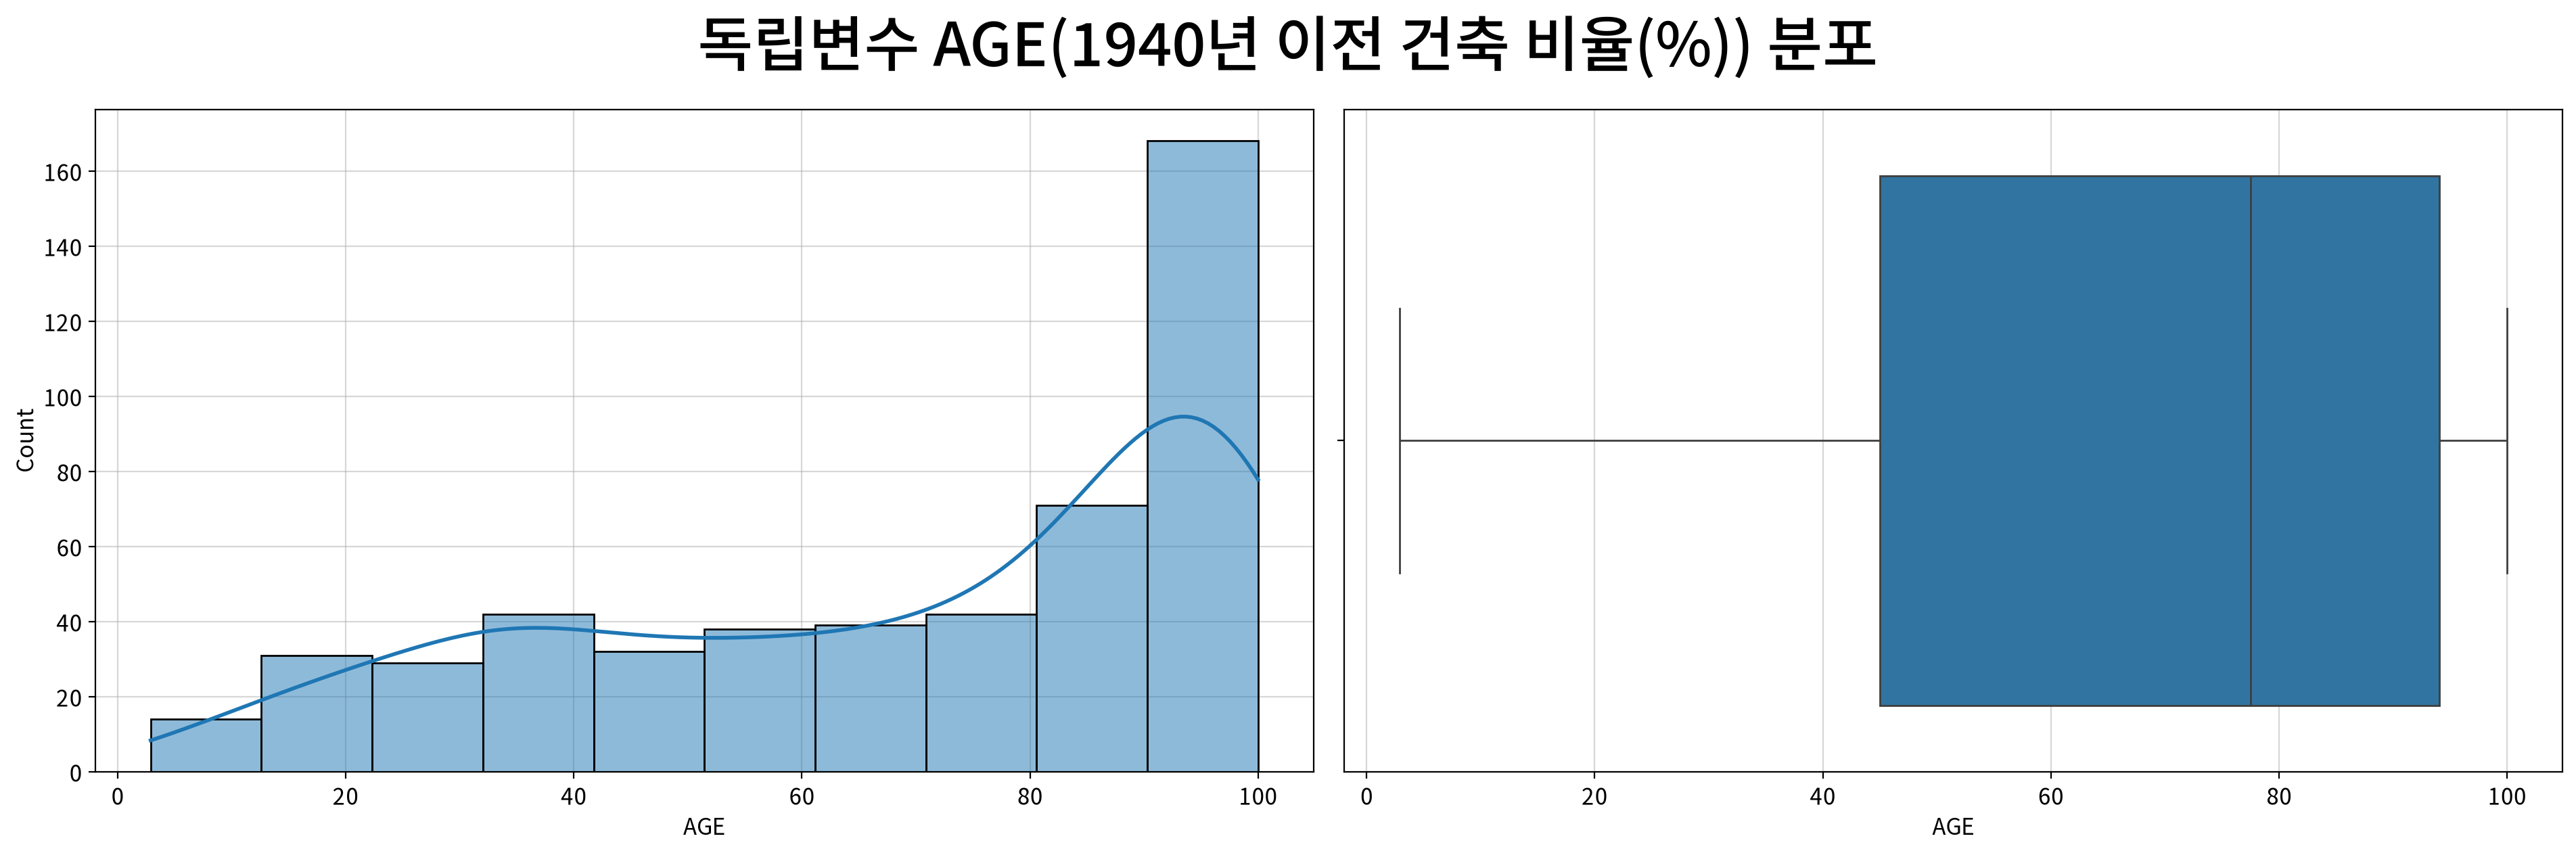

,AGE
count,506.000
mean,68.575
std,28.149
min,2.900
25%,45.025
50%,77.500
75%,94.075
max,100.000
rel_diff,0.115
rdiff_flag,diff


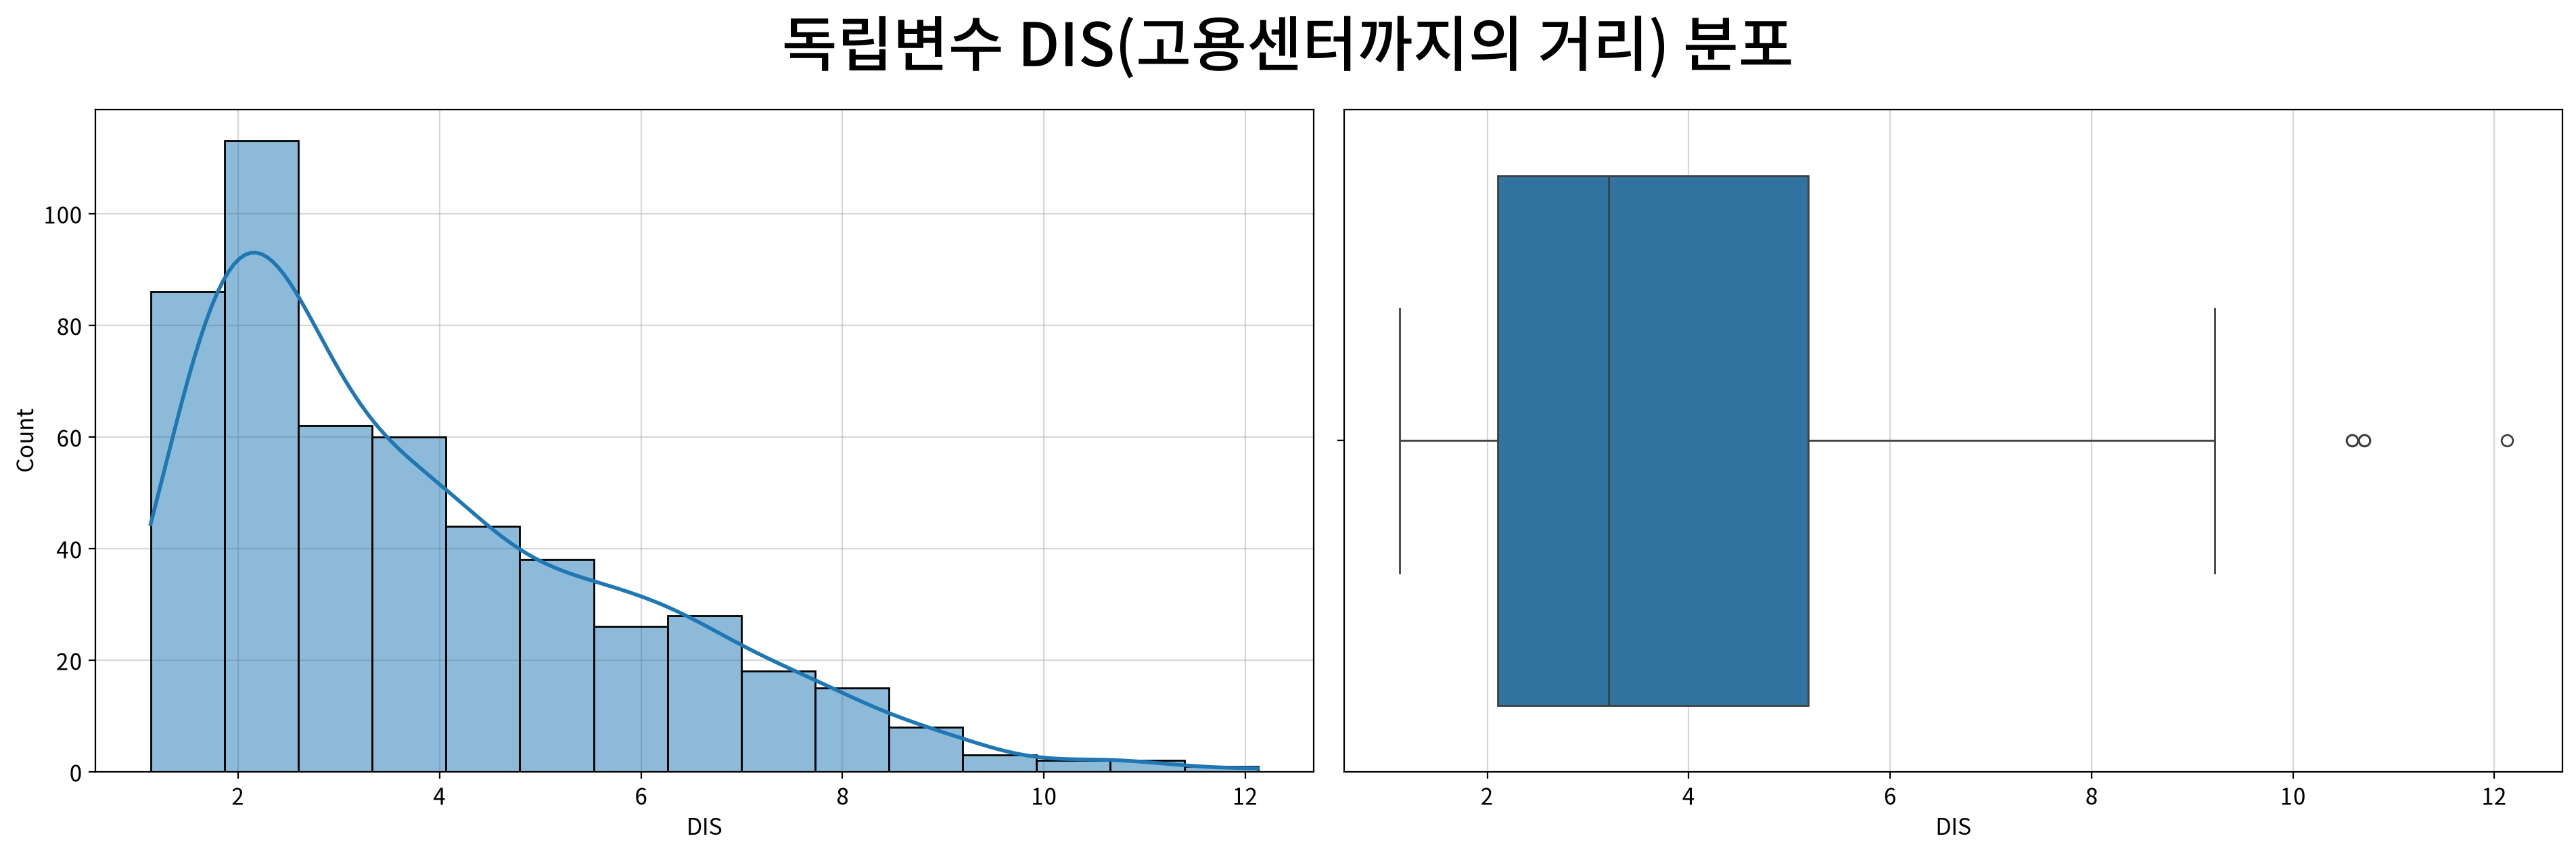

,DIS
count,506.000
mean,3.795
std,2.106
min,1.130
25%,2.100
50%,3.207
75%,5.188
max,12.127
rel_diff,0.183
rdiff_flag,diff


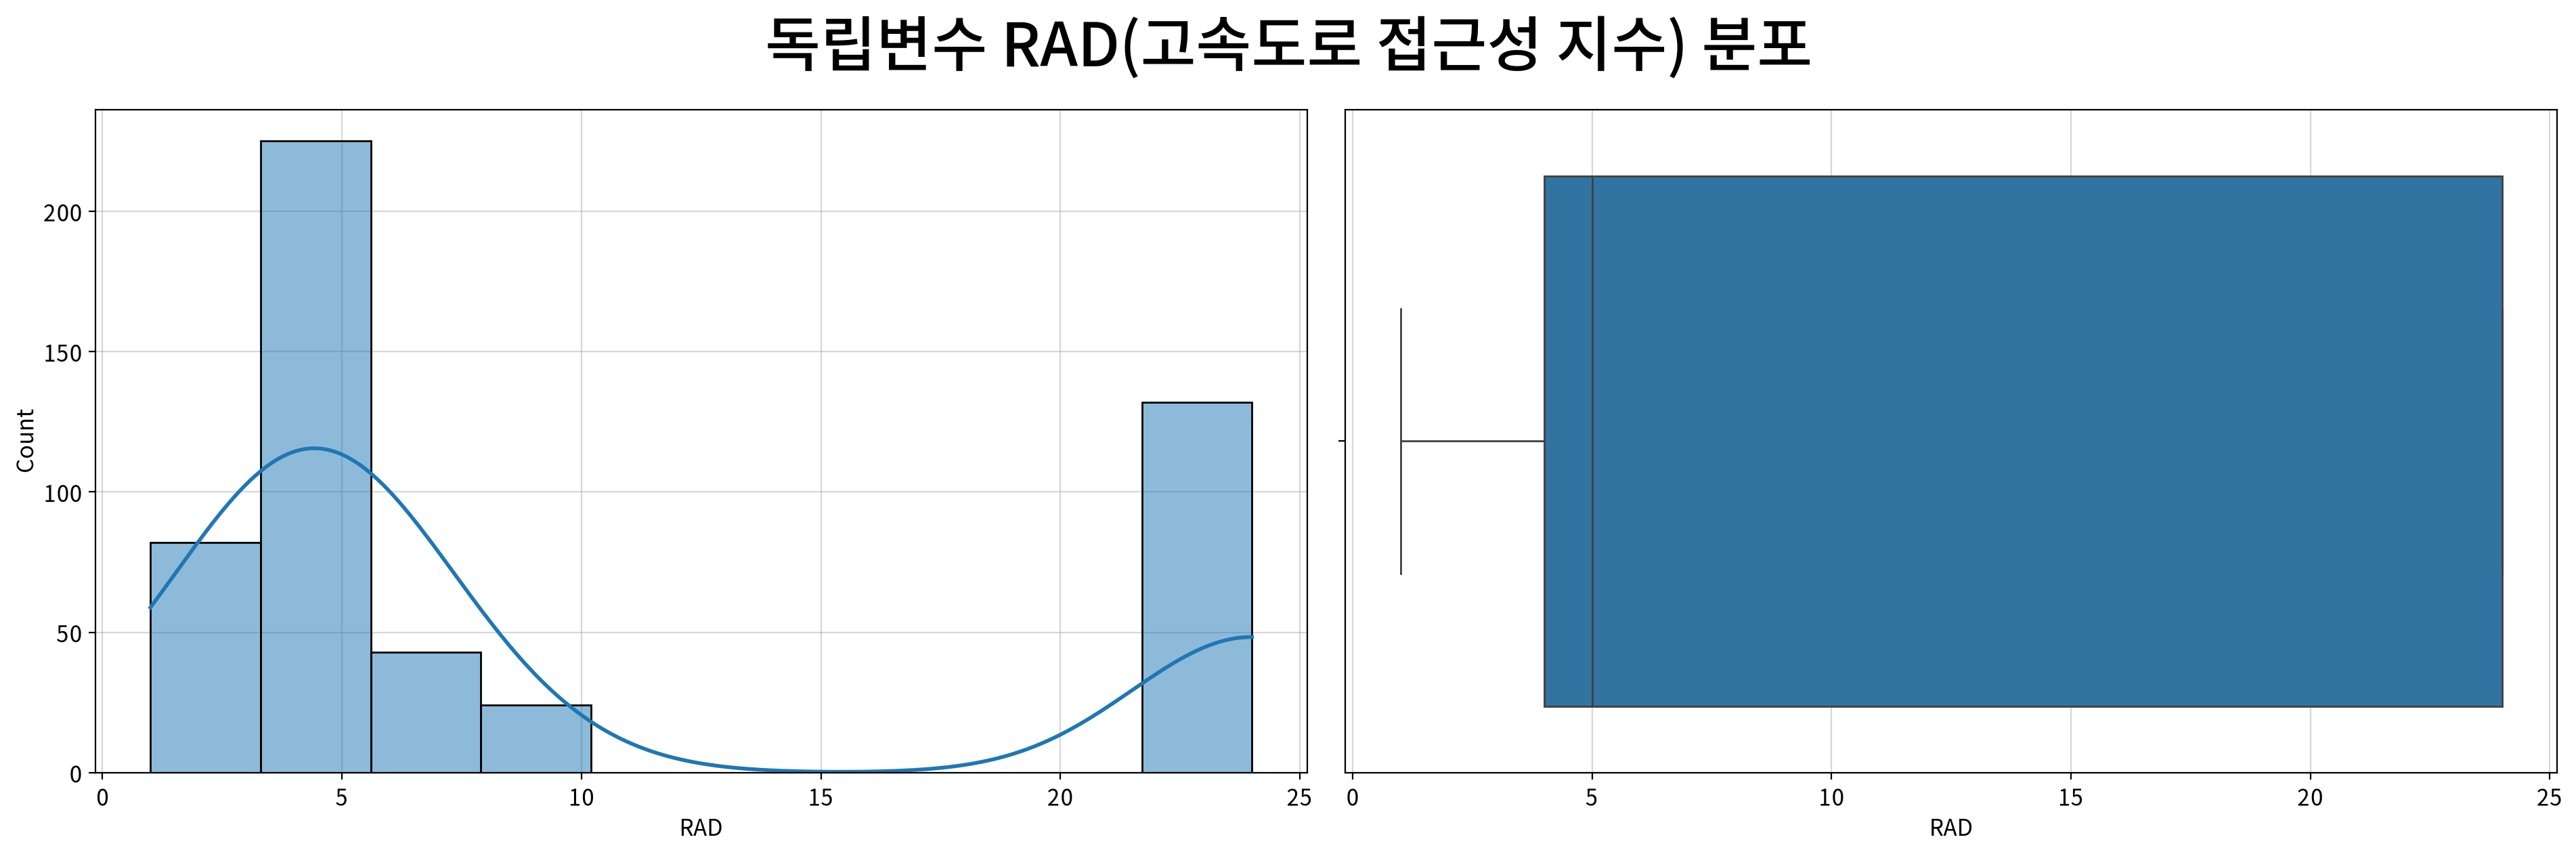

,RAD
count,506.000
mean,9.549
std,8.707
min,1.000
25%,4.000
50%,5.000
75%,24.000
max,24.000
rel_diff,0.910
rdiff_flag,large_diff


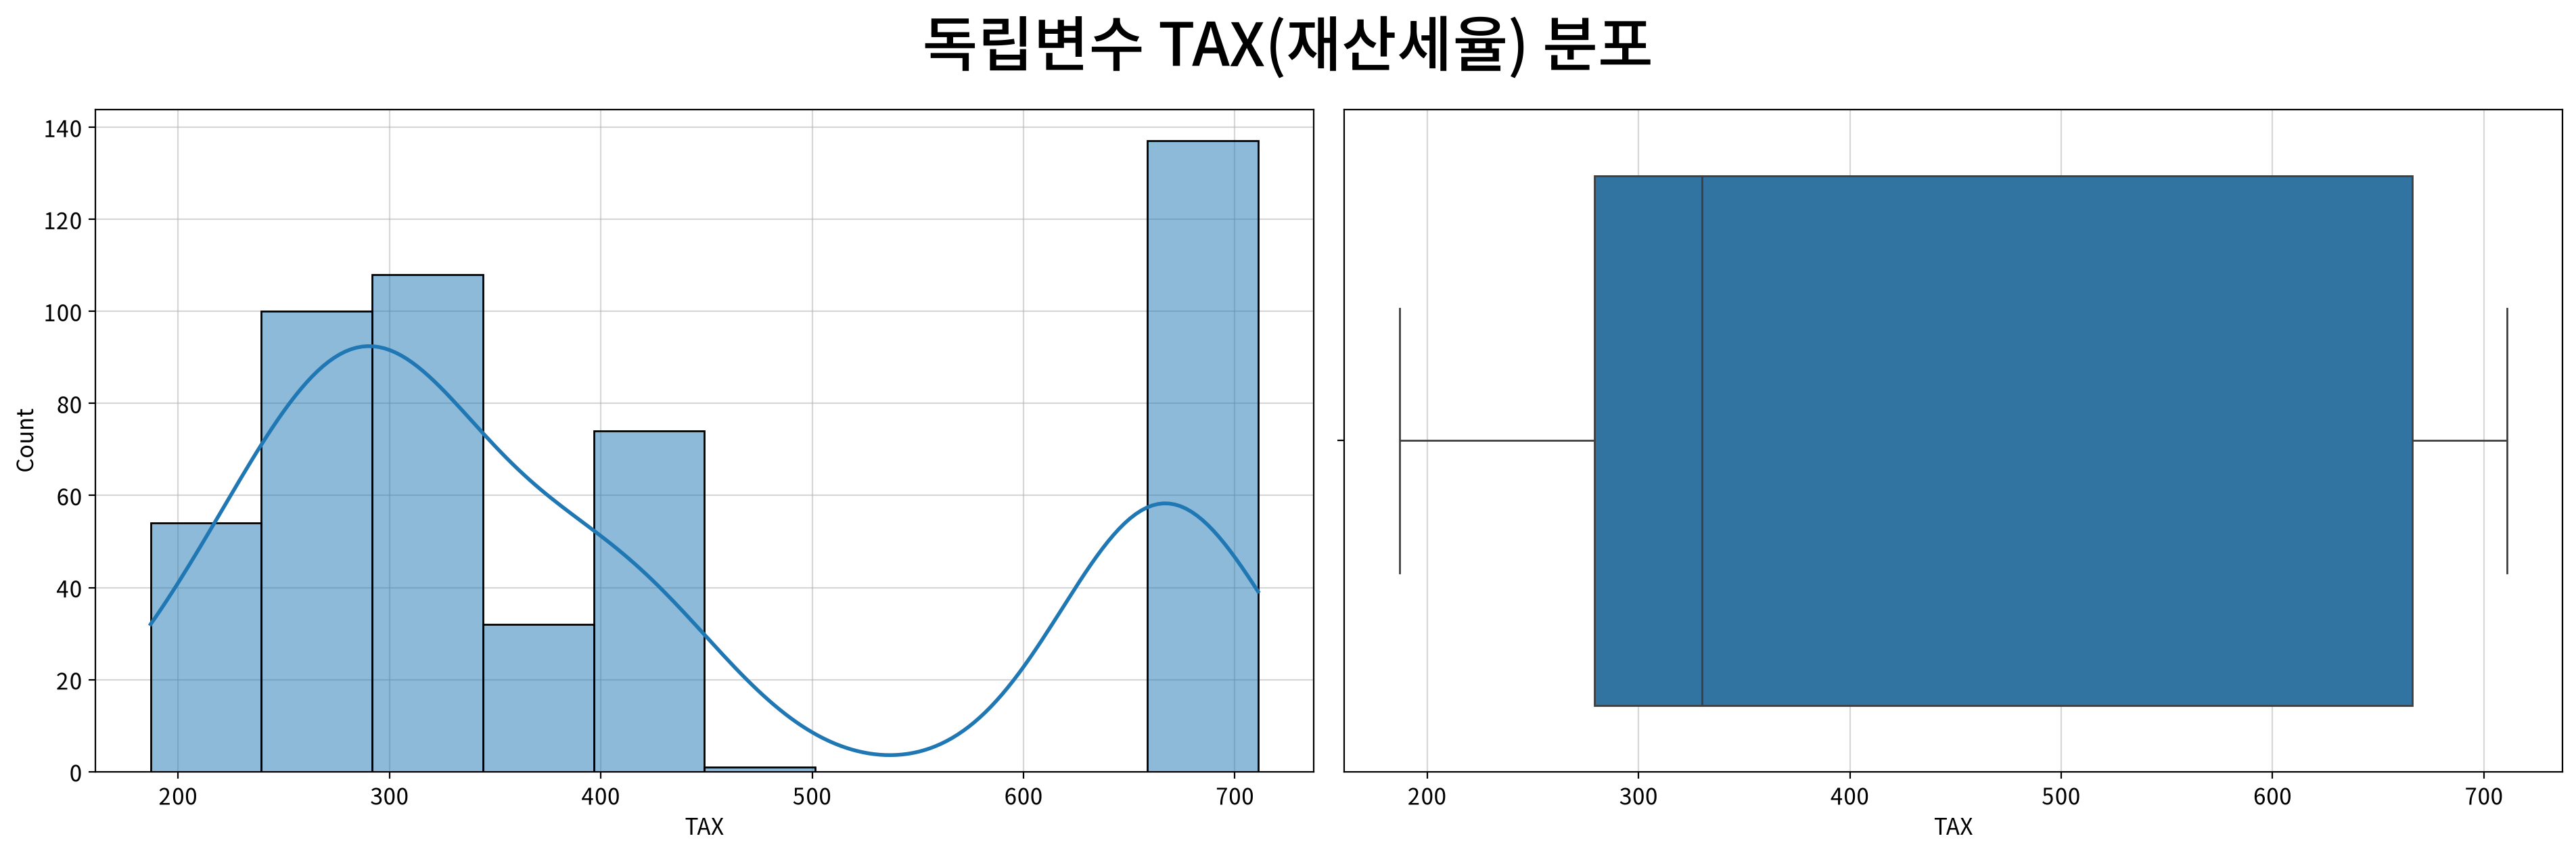

,TAX
count,506.000
mean,408.237
std,168.537
min,187.000
25%,279.000
50%,330.000
75%,666.000
max,711.000
rel_diff,0.237
rdiff_flag,diff


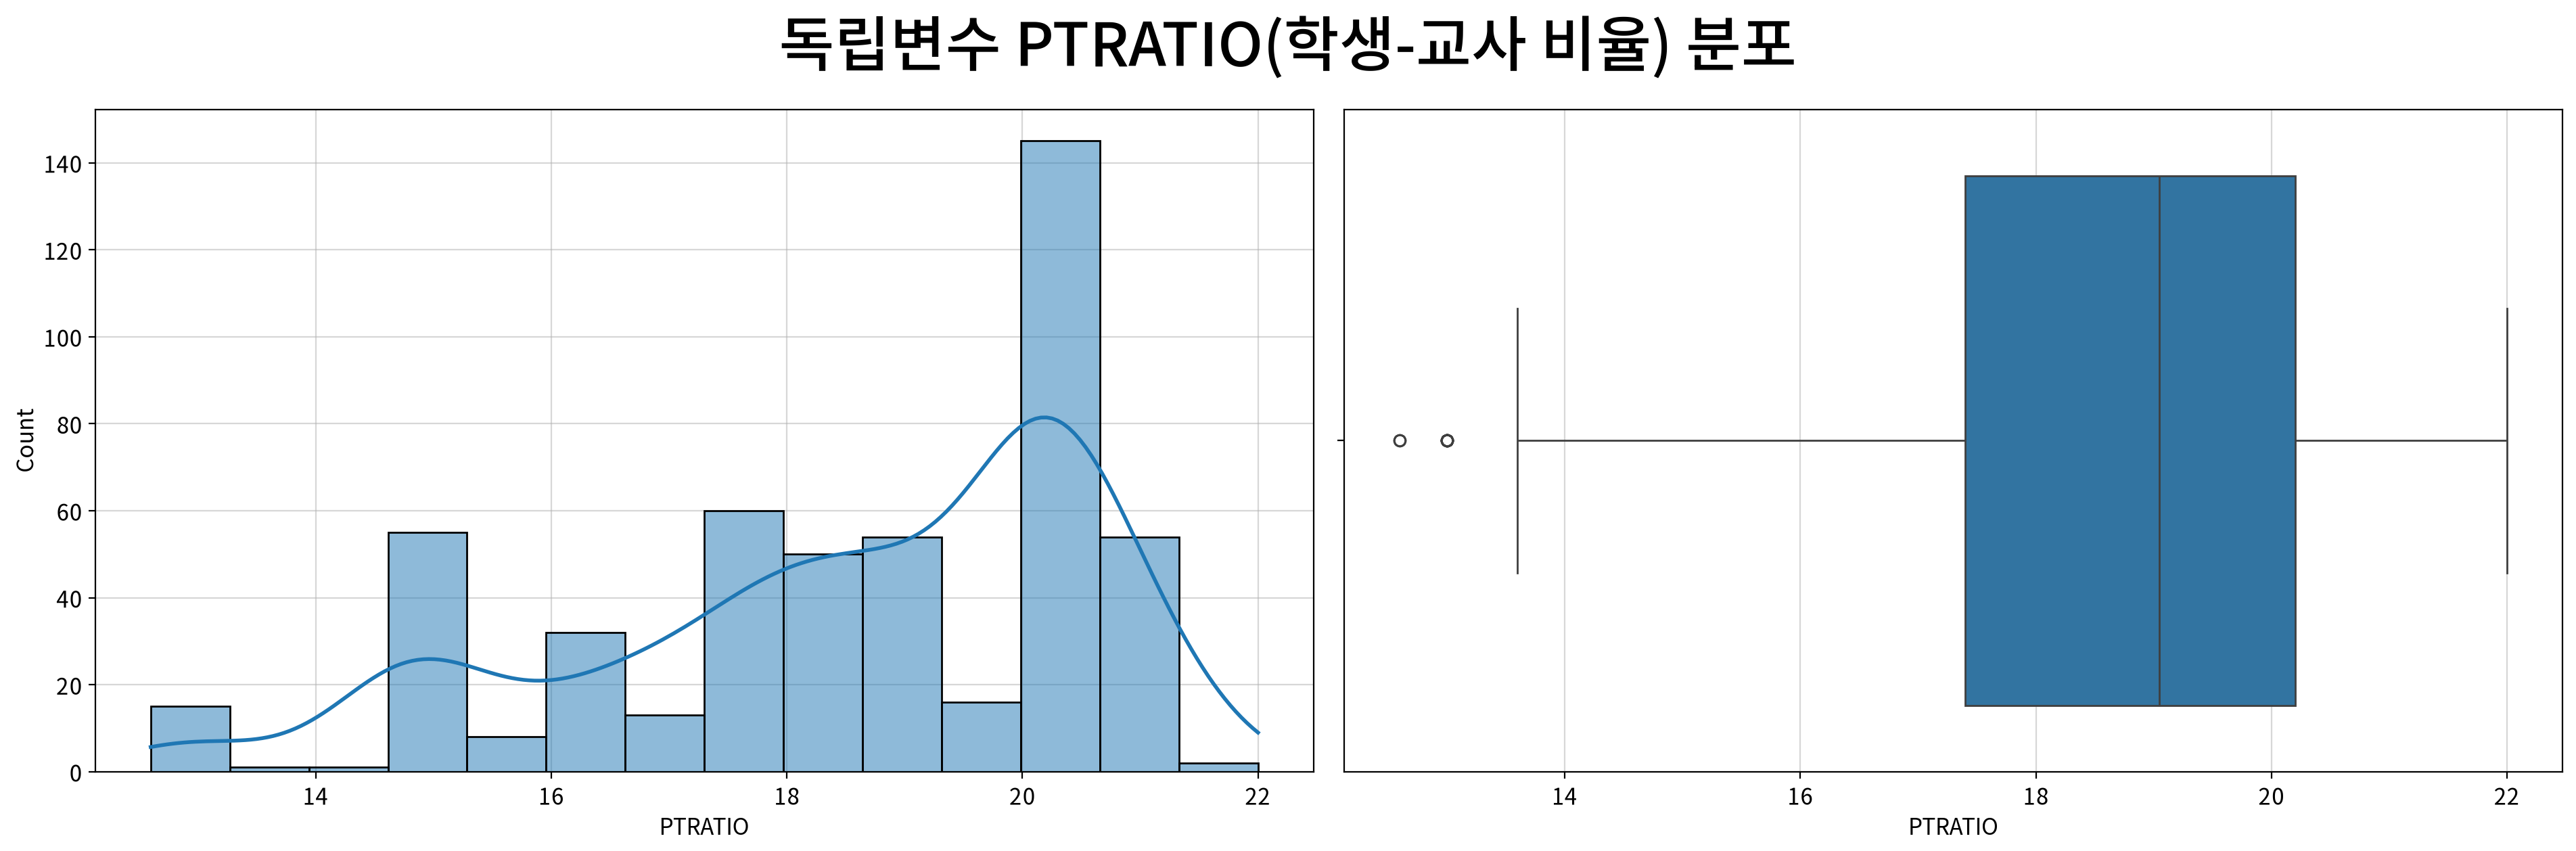

,PTRATIO
count,506.000
mean,18.456
std,2.165
min,12.600
25%,17.400
50%,19.050
75%,20.200
max,22.000
rel_diff,0.031
rdiff_flag,similar


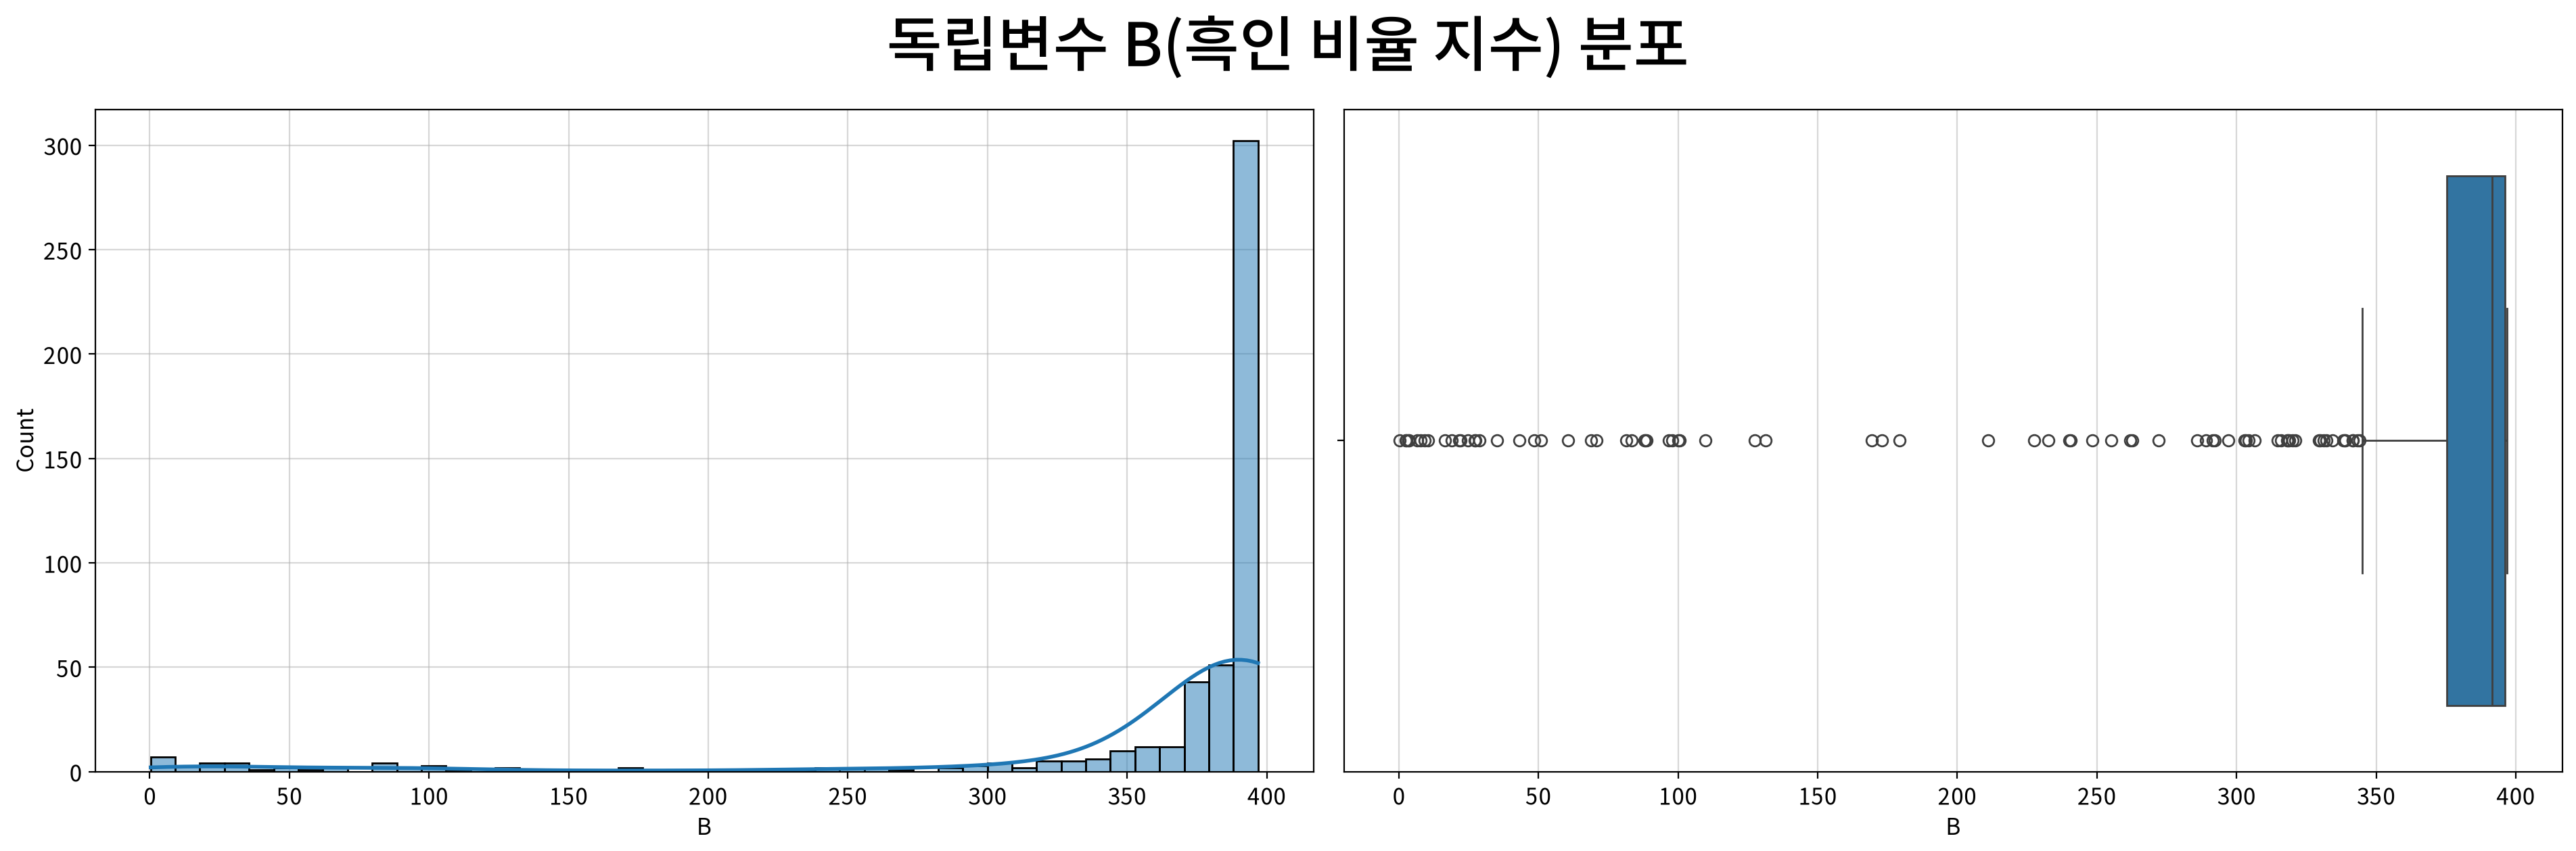

,B
count,506.000
mean,356.674
std,91.295
min,0.320
25%,375.377
50%,391.440
75%,396.225
max,396.900
rel_diff,0.089
rdiff_flag,similar


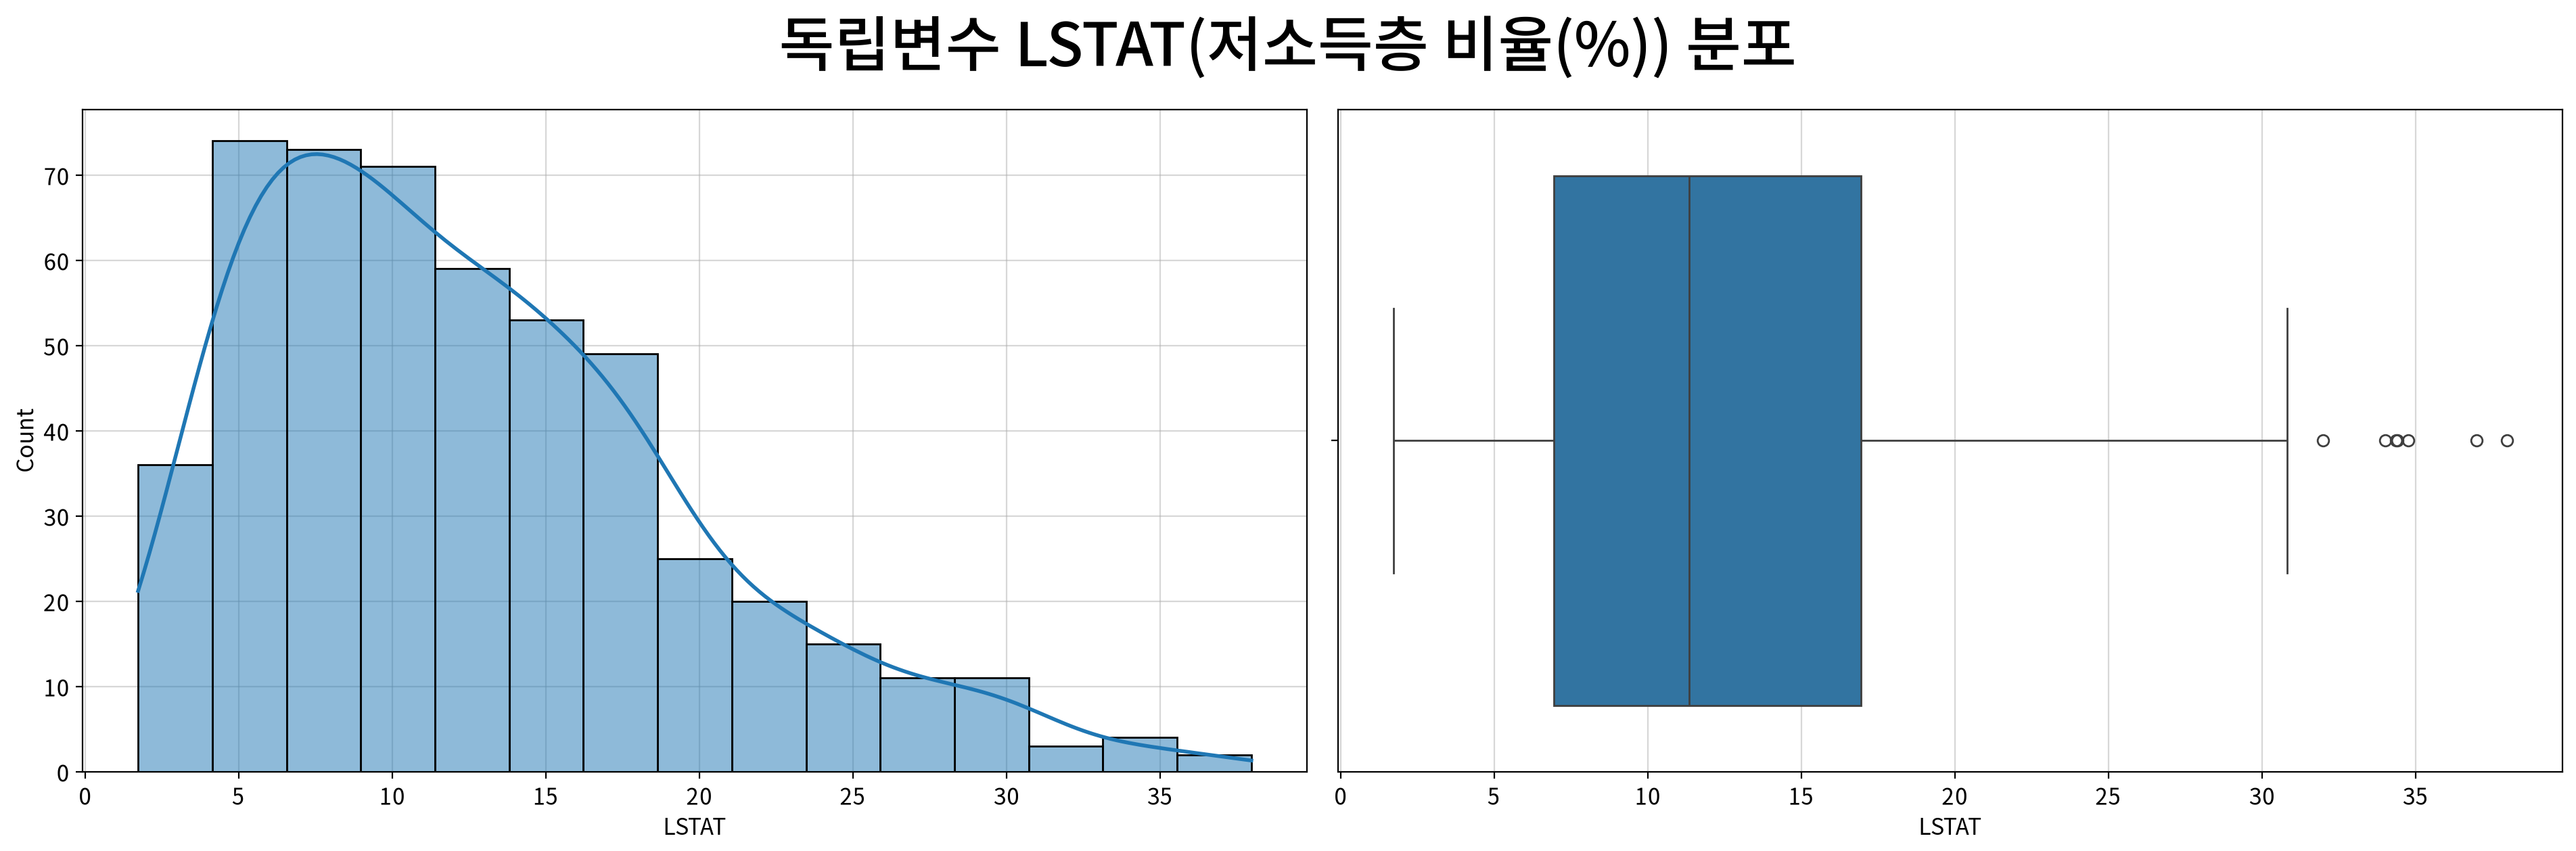

,LSTAT
count,506.000
mean,12.653
std,7.141
min,1.730
25%,6.950
50%,11.360
75%,16.955
max,37.970
rel_diff,0.114
rdiff_flag,diff


In [15]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

##### 7) 명목형 독립변수에 대한 단변량 분석

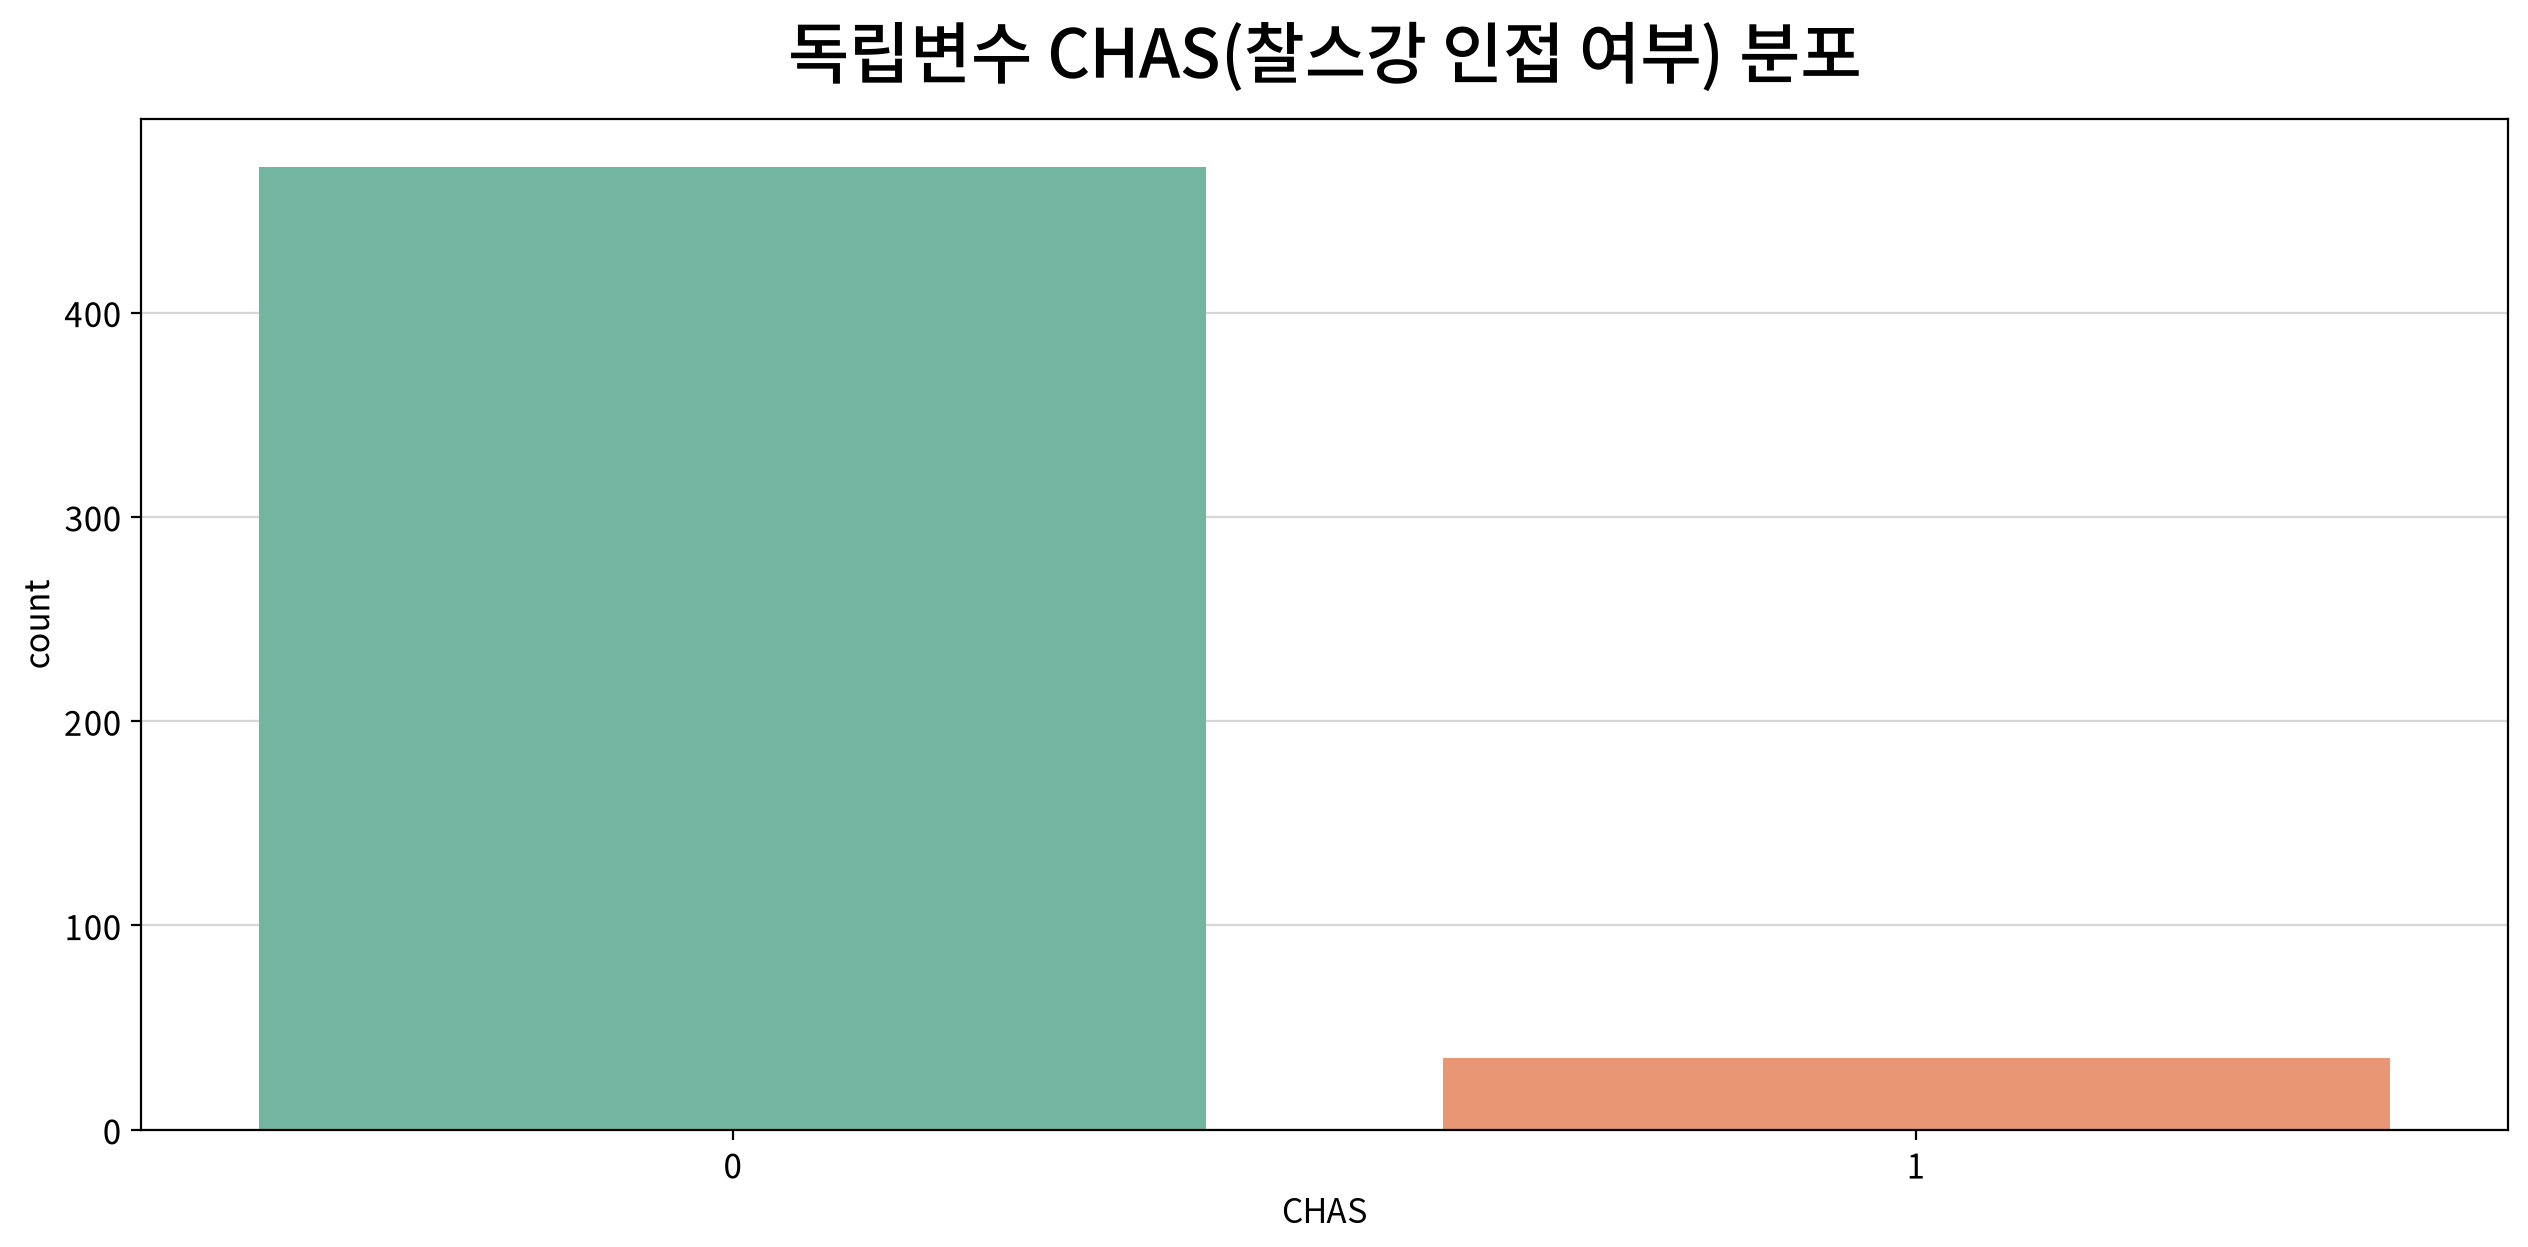

,count,unique,top,freq
CHAS,506,2,0,471


,빈도,비율
CHAS,,
0,471,0.931
1,35,0.069


In [16]:
for n in nominal_cols:
    ## 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2", title=f"독립변수 {n}({column_means[n]}) 분포")

    ## 명목형 기술통계량
    display(cat_desc[[n]].T)

    ## 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    ## value_counts(normalize=True)
    ## --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

**해석**

| 변수 | 분포 모양(왜도) | 봉우리 | 이상치 | 판단·조치 |
|---|---|---|---|---|
| `CRIM` | **극단적 우편향** (+5.22), 첨도 37.13 | 0 근처 단봉 | 66건(13.0%) | **로그 변환**(log) |
| `ZN` | 강한 우편향 (+2.23) | 0에 몰림(중앙값 0) | 68건(13.4%) | **로그 변환**(log1p) — 0이 많아 log1p 필요 |
| `INDUS` | 거의 대칭 (+0.30) | **이봉** (5% 부근 / 18% 부근) | 0건 | 변환 불필요 |
| `NOX` | 우편향 (+0.73) | 단봉 | 0건 | 변환 불필요 |
| `RM` | 대칭 (+0.40), 첨도 1.89 | 단봉(종형) | 30건(5.9%) | 변환 불필요, 이상치 대체 후보 |
| `AGE` | 좌편향 (−0.60) | 100% 쪽에 몰림 | 0건 | 변환 불필요 |
| `DIS` | 우편향 (+1.01) | 단봉 | 5건(1.0%) | **로그 변환**(log) |
| `RAD` | 우편향 (+1.01) | **이봉** (5 이하 / 24에 집중) | 0건 | 사실상 이산 지수 — log 판정되나 해석 주의 |
| `TAX` | 우편향 (+0.67) | **이봉** (300 부근 / 666에 집중) | 0건 | `RAD`와 같은 구조(지수 24 = 세율 666) |
| `PTRATIO` | 좌편향 (−0.80) | 20 부근 집중 | 15건(3.0%) | 이상치 대체 후보 |
| `B` | **강한 좌편향** (−2.89), 첨도 7.23 | 396 부근 집중 | 77건(15.2%) | **반사 후 로그 변환**(reverse_log1p) |
| `LSTAT` | 우편향 (+0.91) | 단봉 | 7건(1.4%) | **로그 변환**(log) |
| `CHAS` | — | 인접 35건(6.9%) | — | **심한 불균형** — 검정 결과 해석 주의 |

- `RAD`·`TAX`가 **똑같이 이봉**인 것이 눈에 띈다. 고속도로 접근성 지수가 24인 구역이 세율 666에 그대로 대응한다 → **공선성 신호**(4-2에서 확인).
- `INDUS`도 이봉이며 18% 부근의 덩어리가 위 두 변수의 덩어리와 같은 구역일 가능성이 크다.

#### 4-2. 변수 간 관계

##### 1) 상관분석 (x: 연속형 독립변수 → y: 연속형 종속변수)

##### ▶︎ CRIM(1인당 범죄율) → MEDV

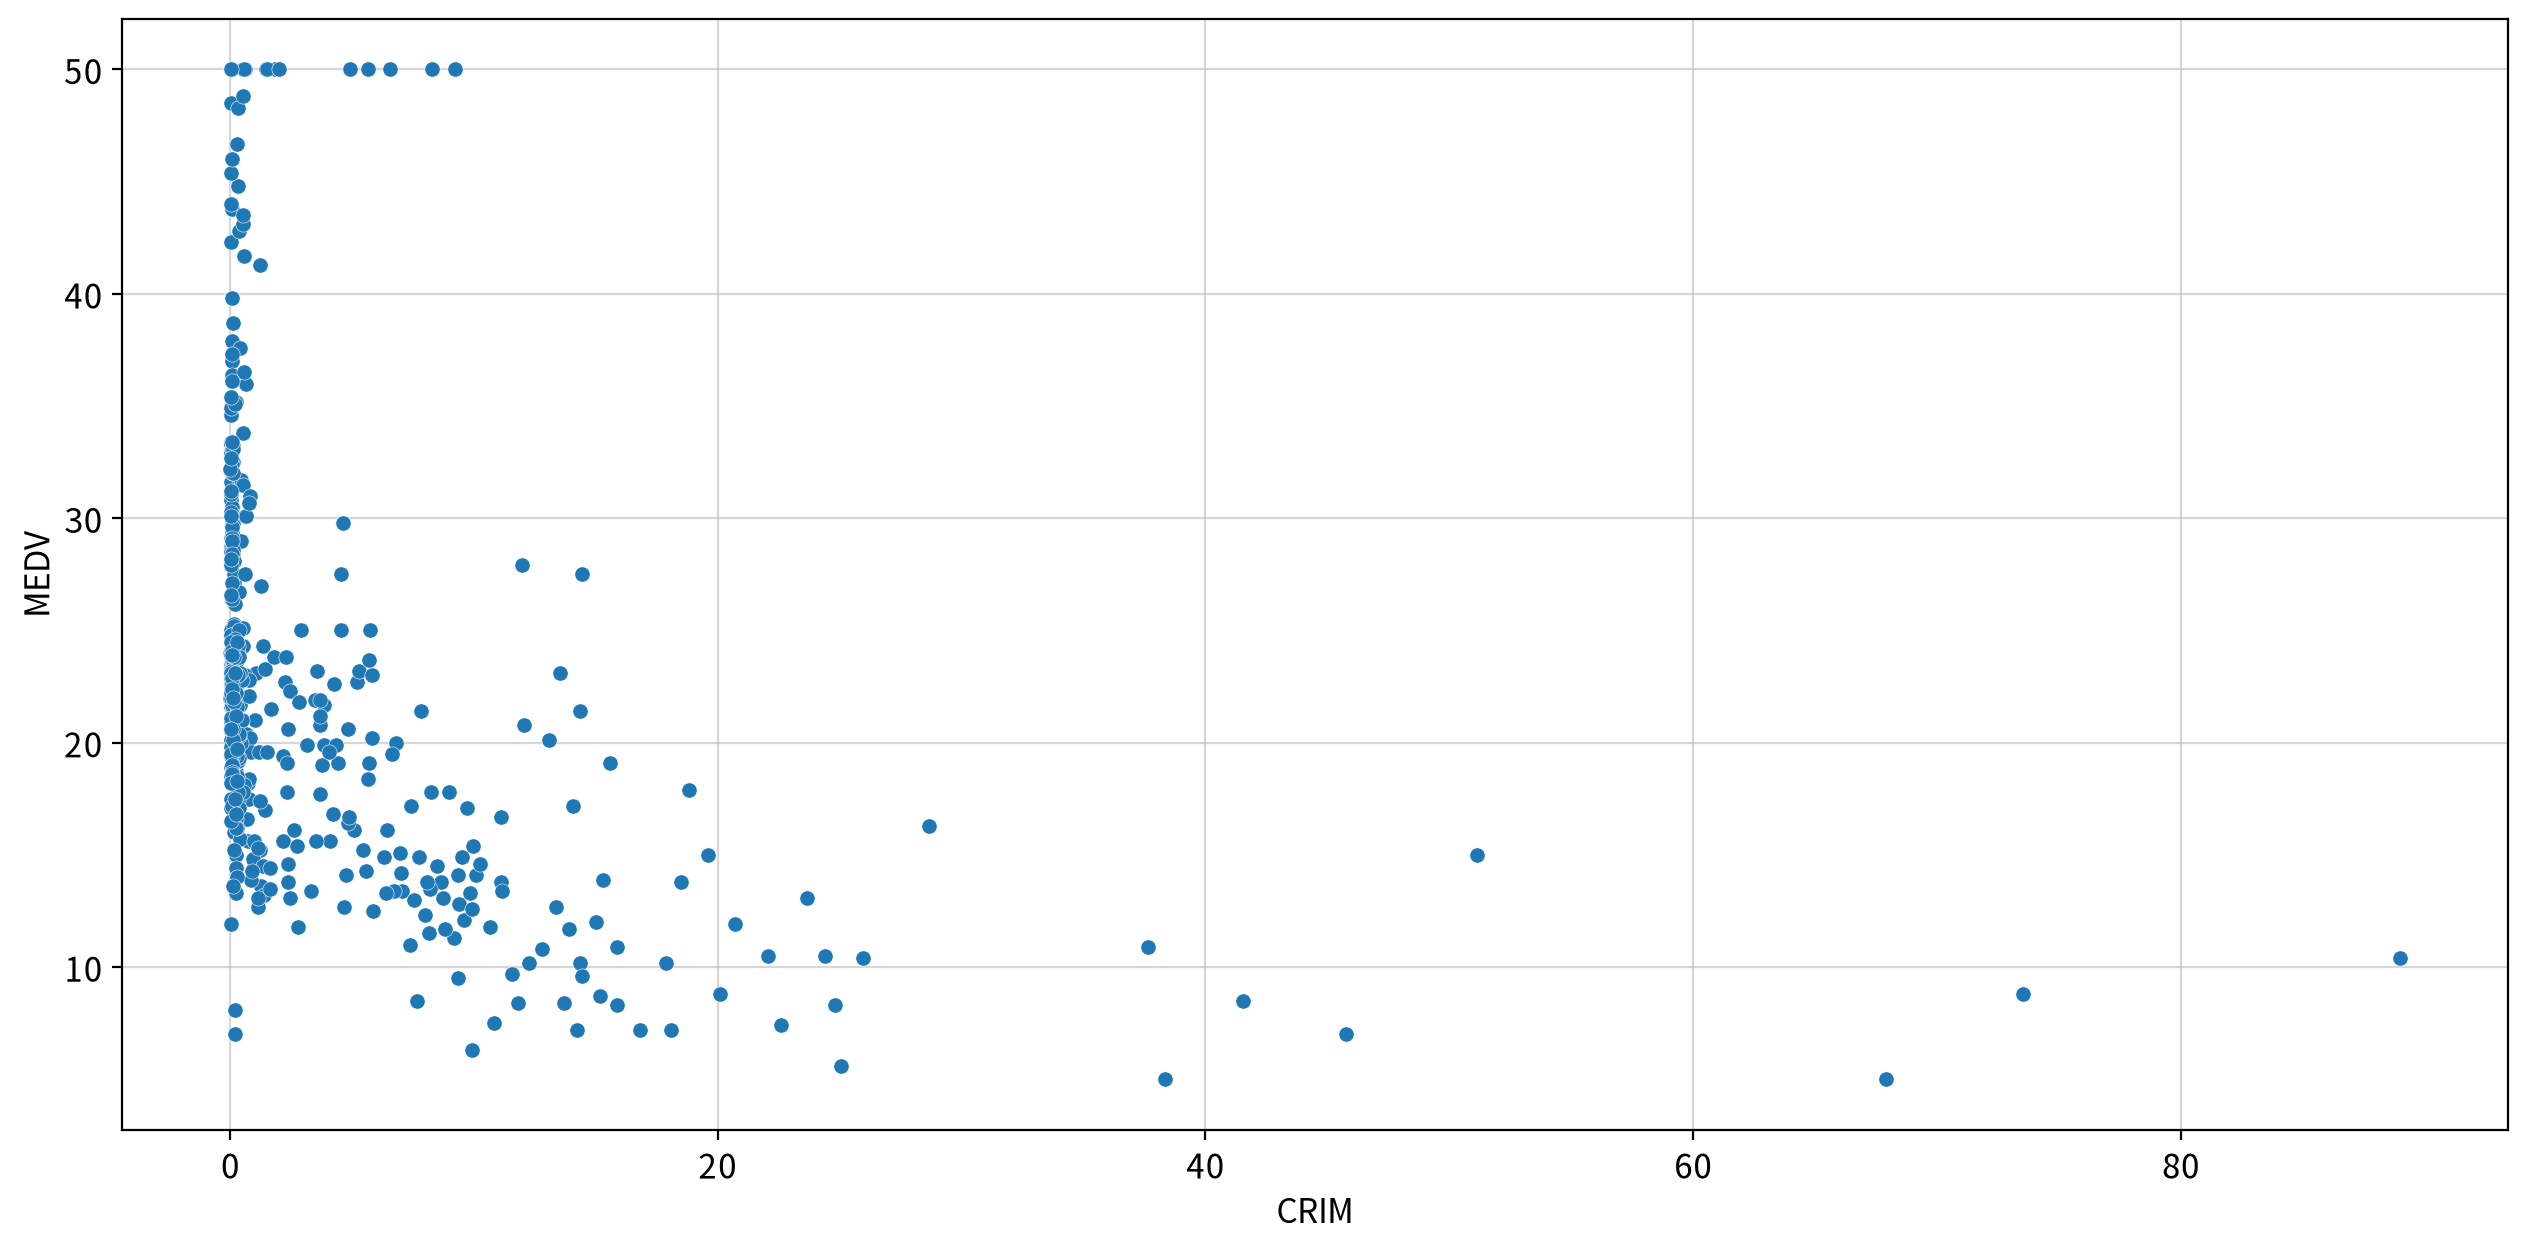

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
CRIM,MEDV,Spearman,-0.559,0.000,Moderate,True,False,False,False,False,True


##### ▶︎ ZN(대형 주거용지 비율(%)) → MEDV

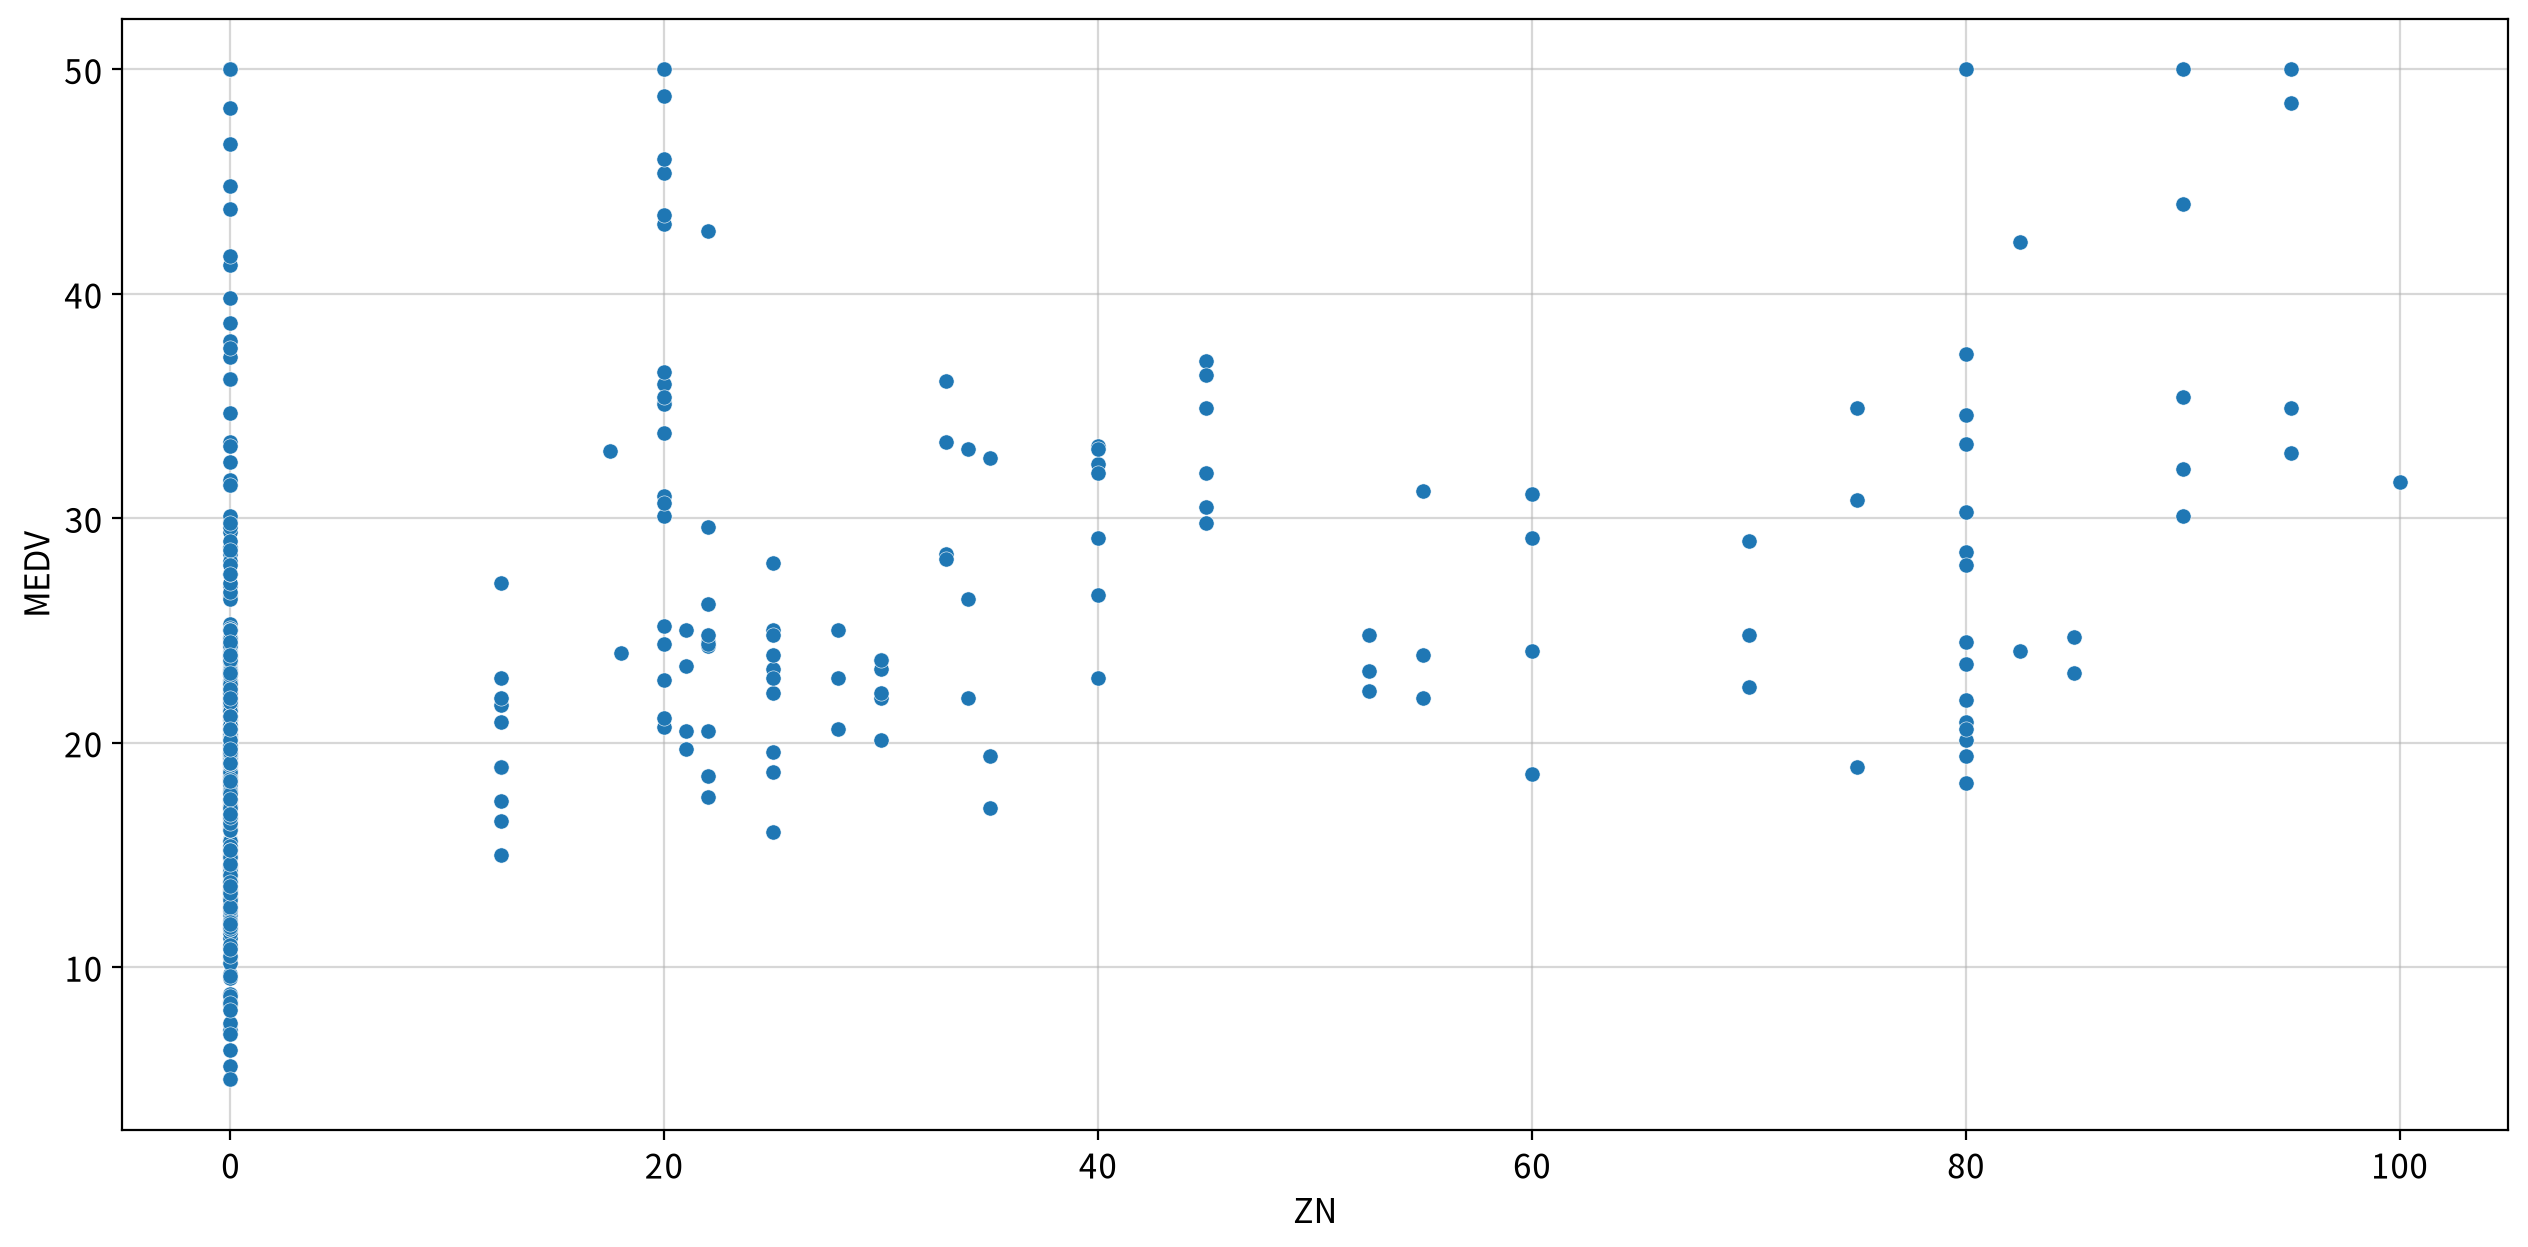

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
ZN,MEDV,Spearman,0.438,0.000,Moderate,True,False,False,False,False,True


##### ▶︎ INDUS(비소매 상업구역 비율(%)) → MEDV

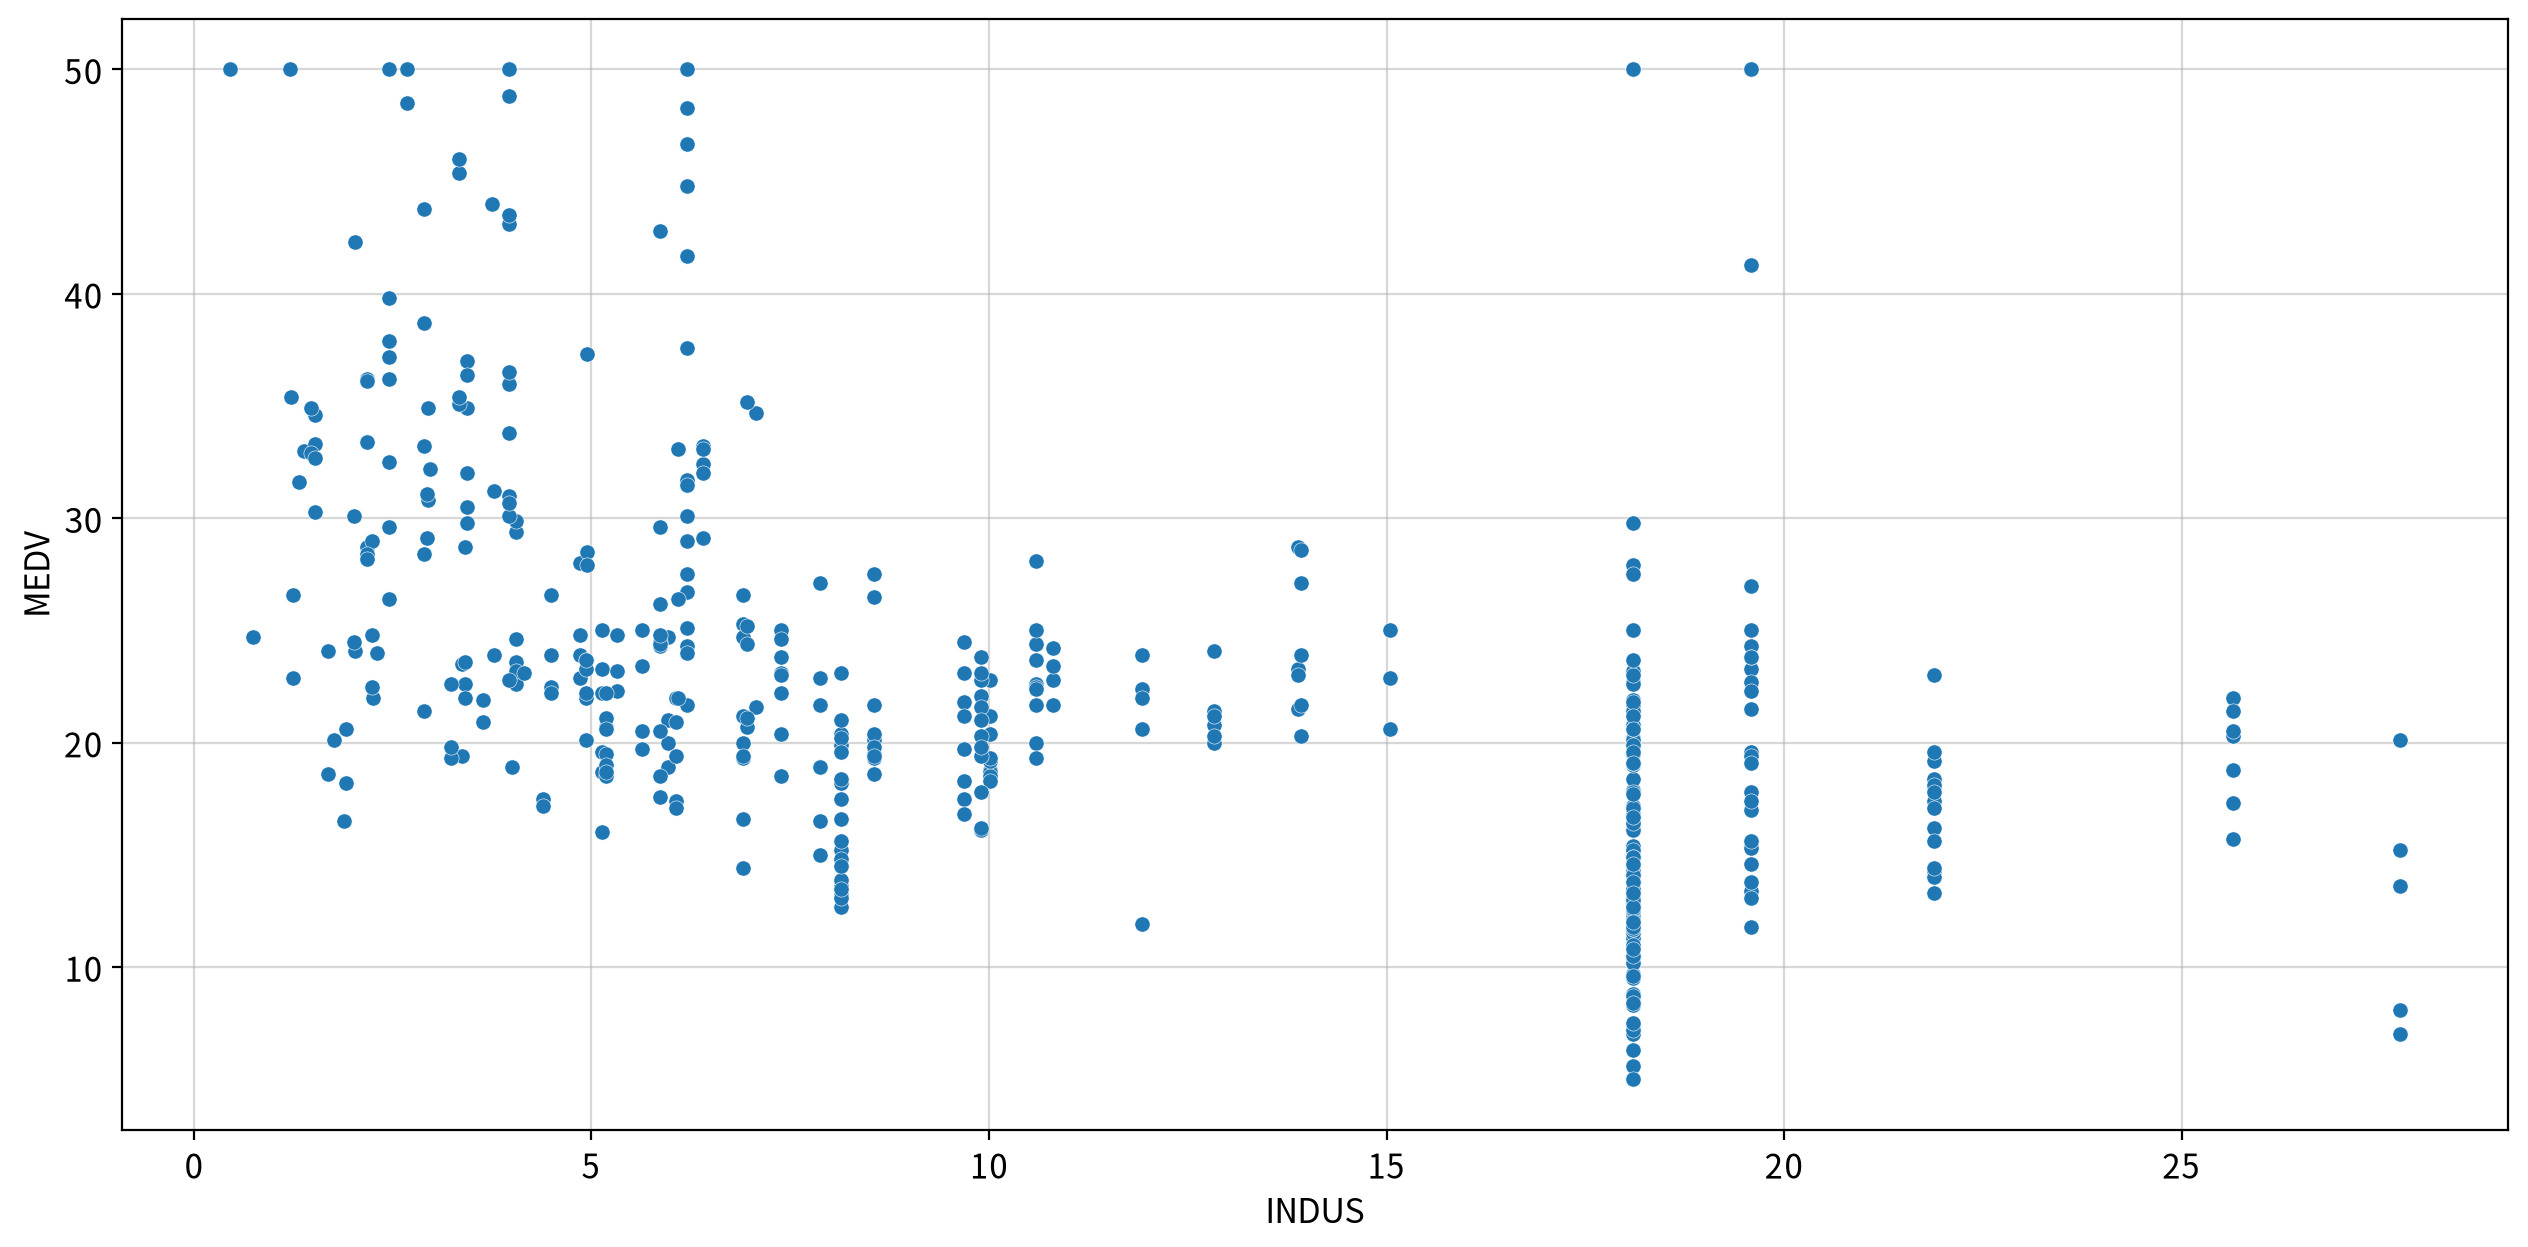

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
INDUS,MEDV,Spearman,-0.578,0.000,Moderate,True,False,False,False,True,True


##### ▶︎ NOX(질소산화물 농도) → MEDV

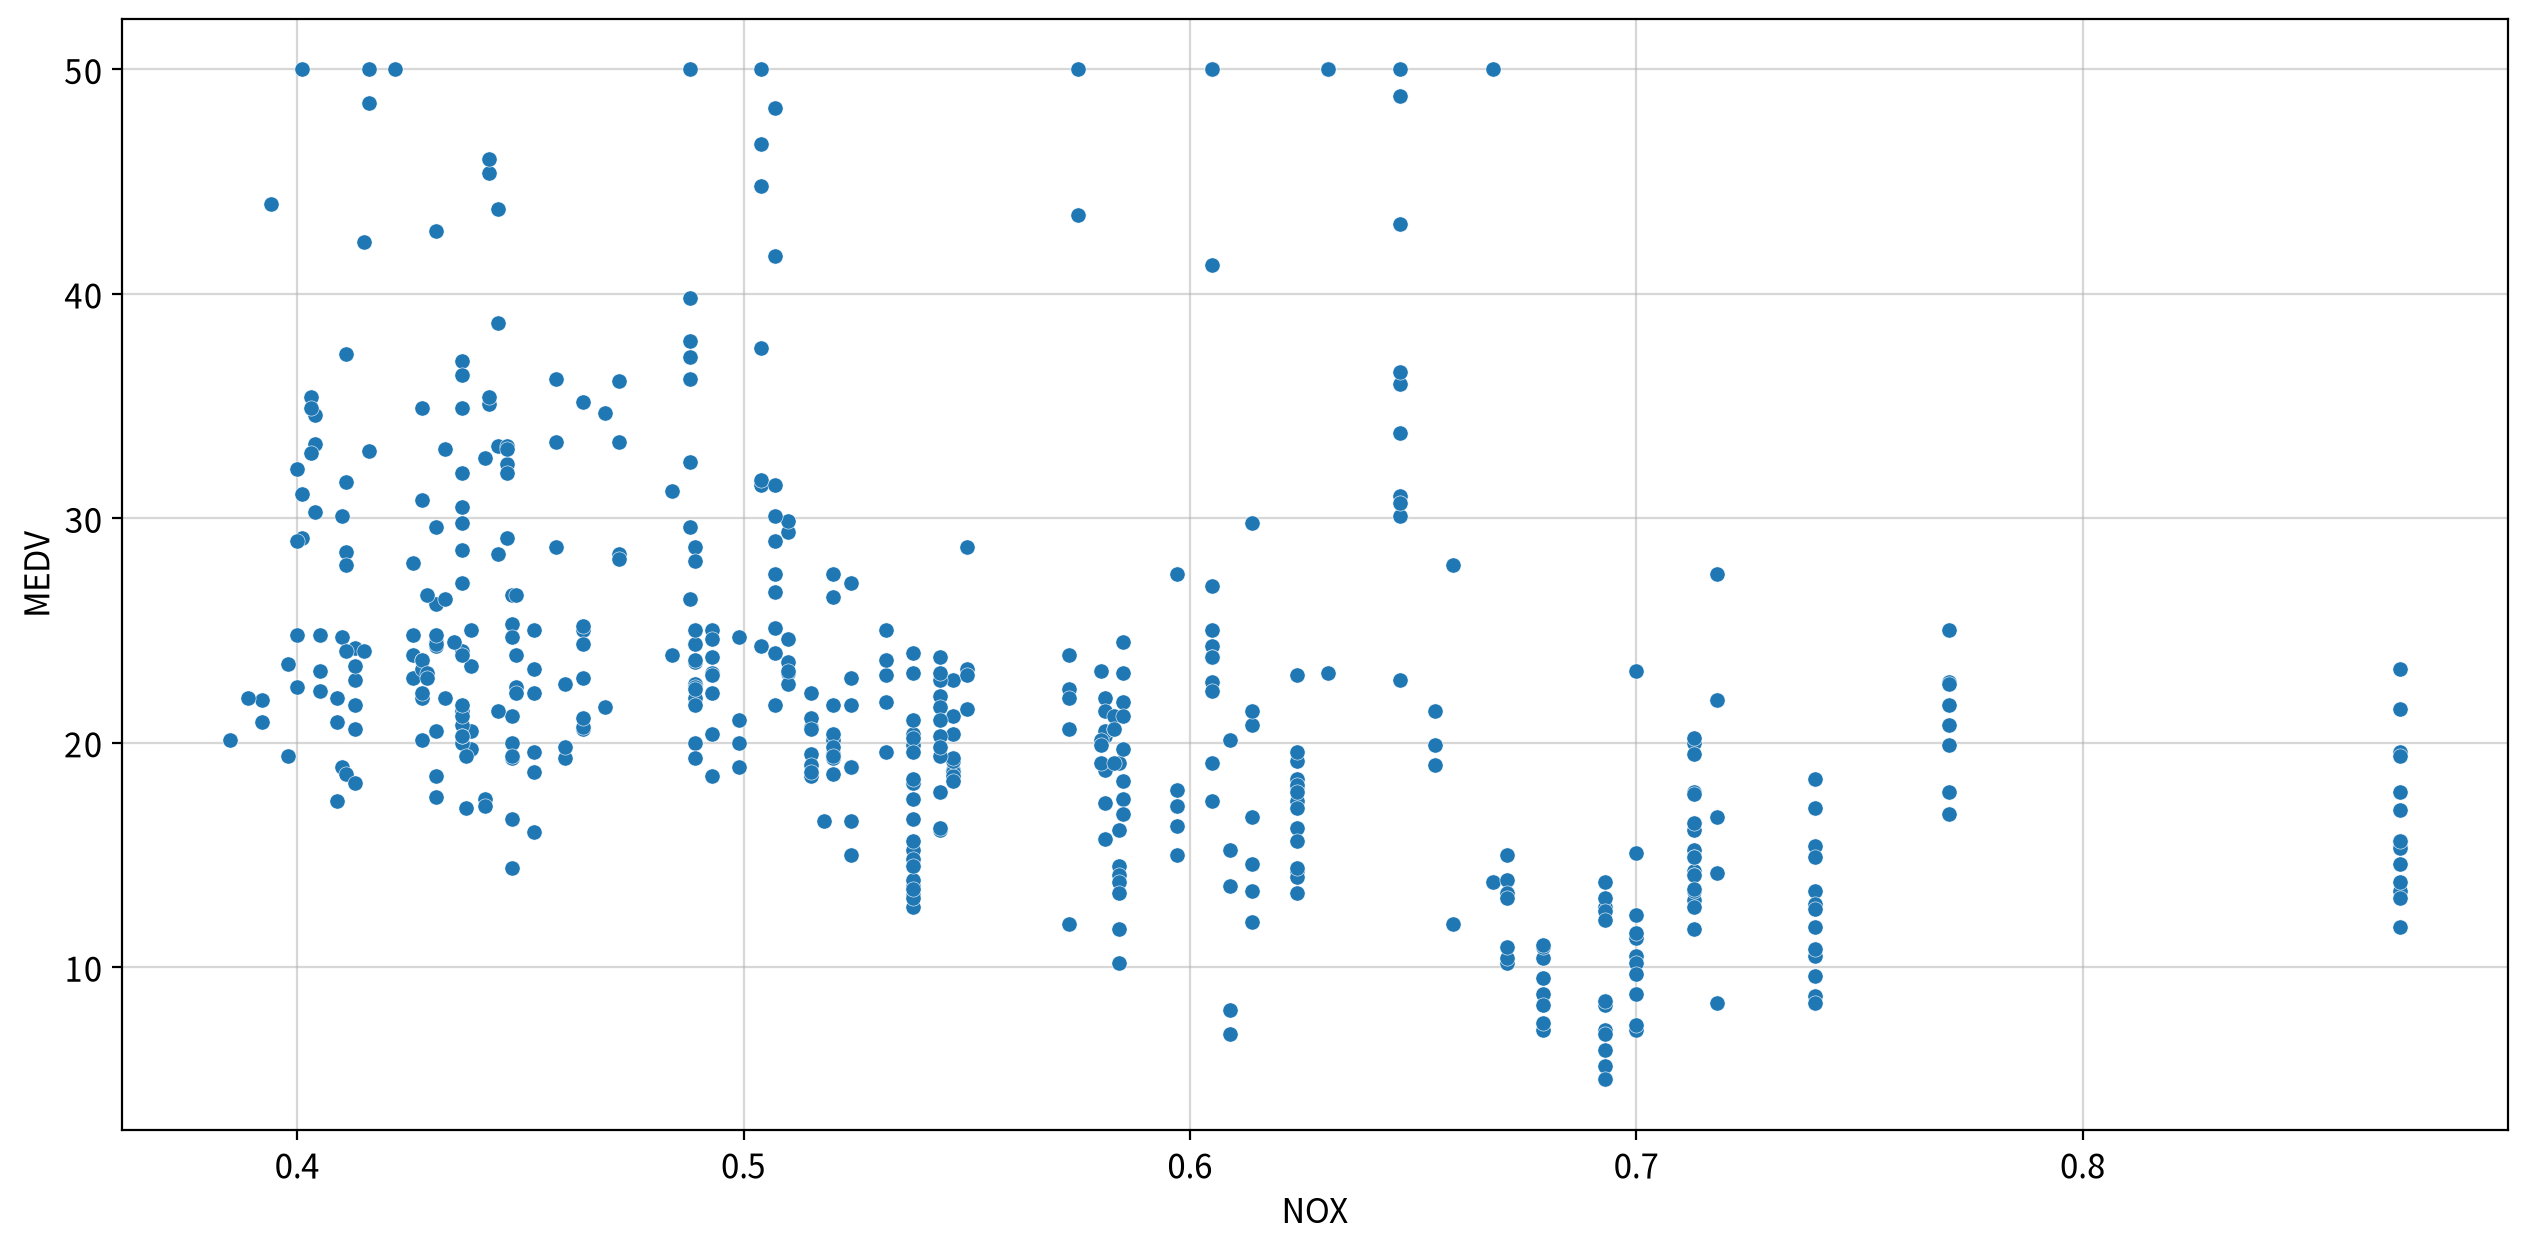

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
NOX,MEDV,Spearman,-0.563,0.000,Moderate,True,False,False,True,True,True


##### ▶︎ RM(평균 방 개수) → MEDV

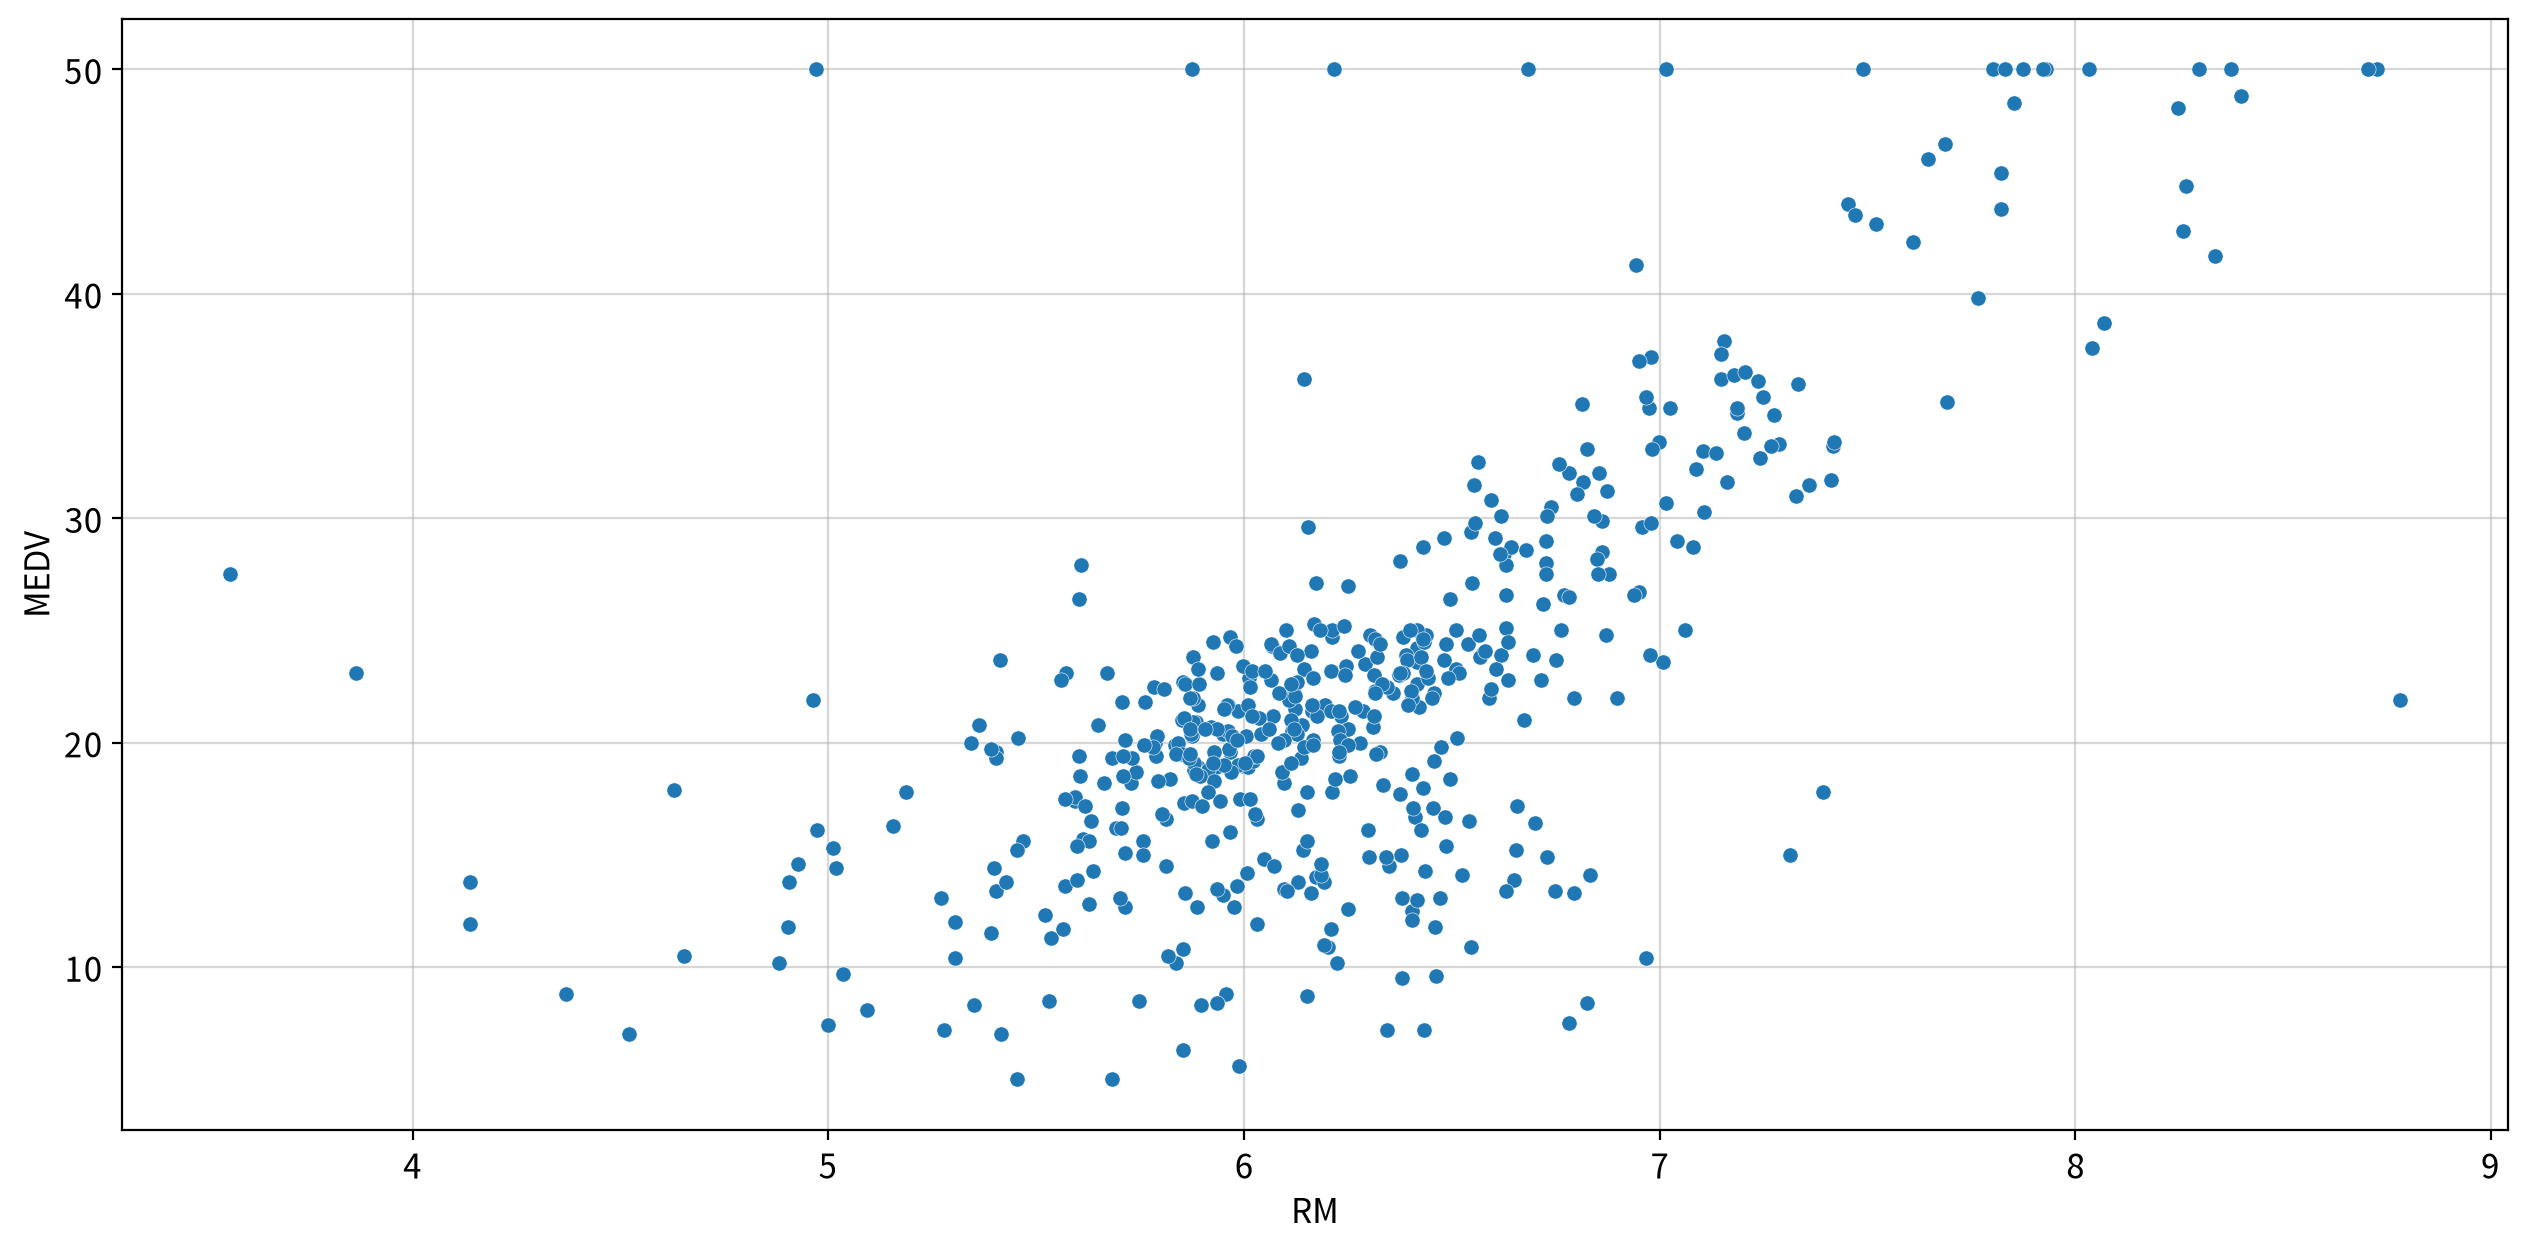

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
RM,MEDV,Spearman,0.634,0.000,Moderate,True,False,False,False,False,True


##### ▶︎ AGE(1940년 이전 건축 비율(%)) → MEDV

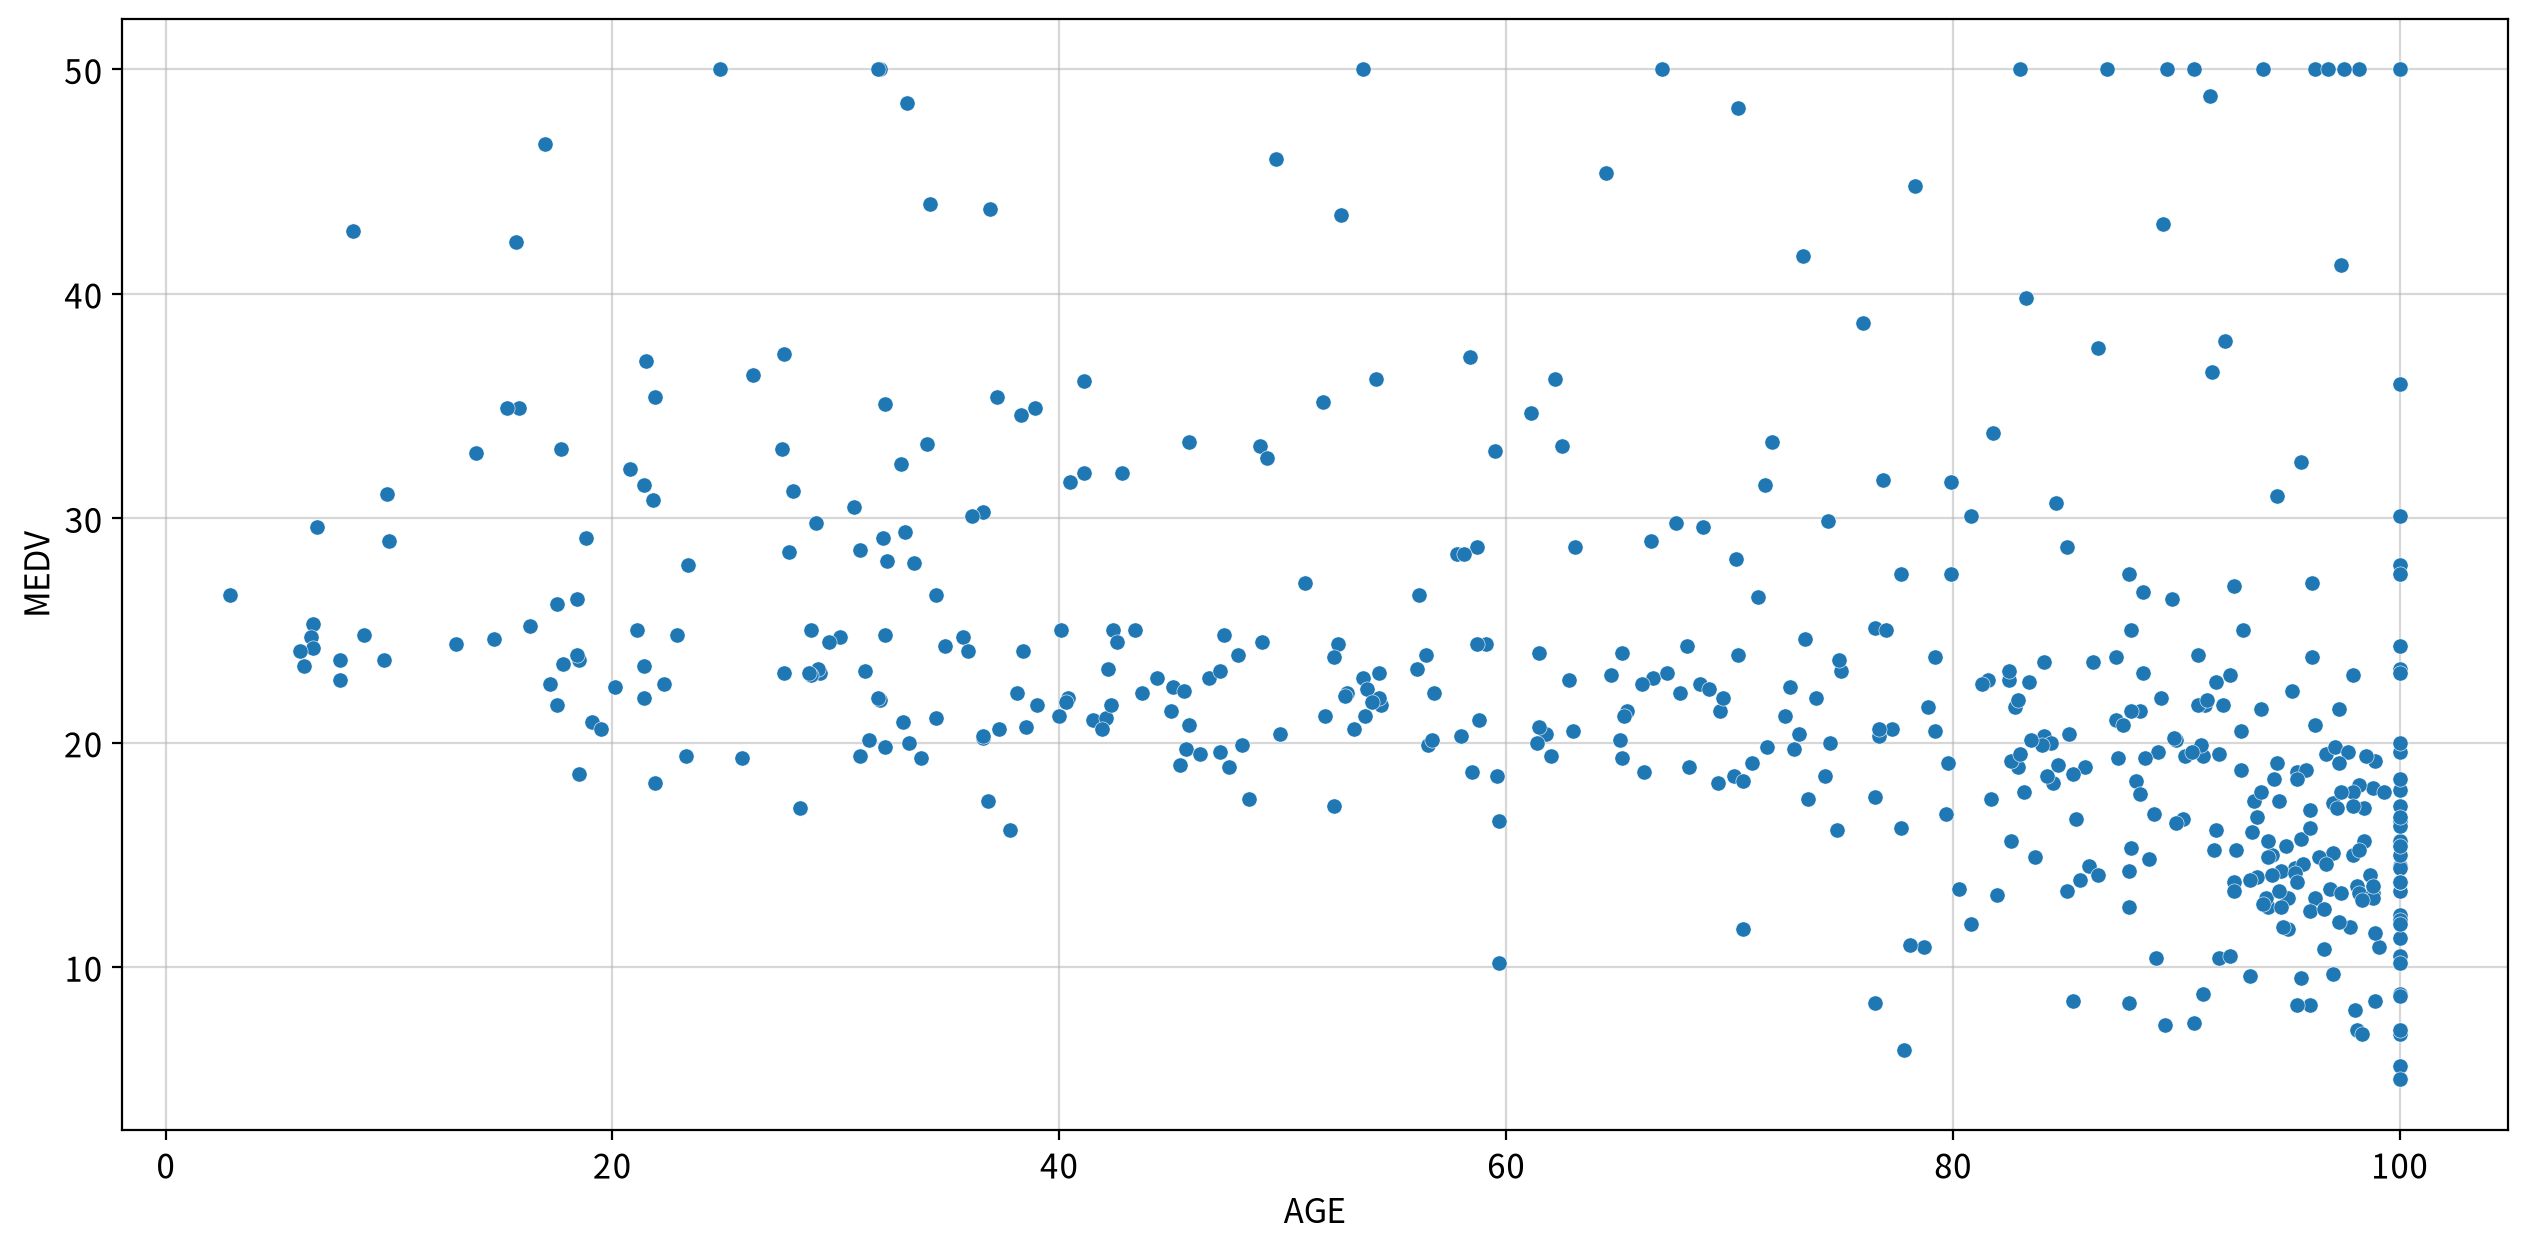

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
AGE,MEDV,Spearman,-0.548,0.000,Moderate,True,False,False,False,True,True


##### ▶︎ DIS(고용센터까지의 거리) → MEDV

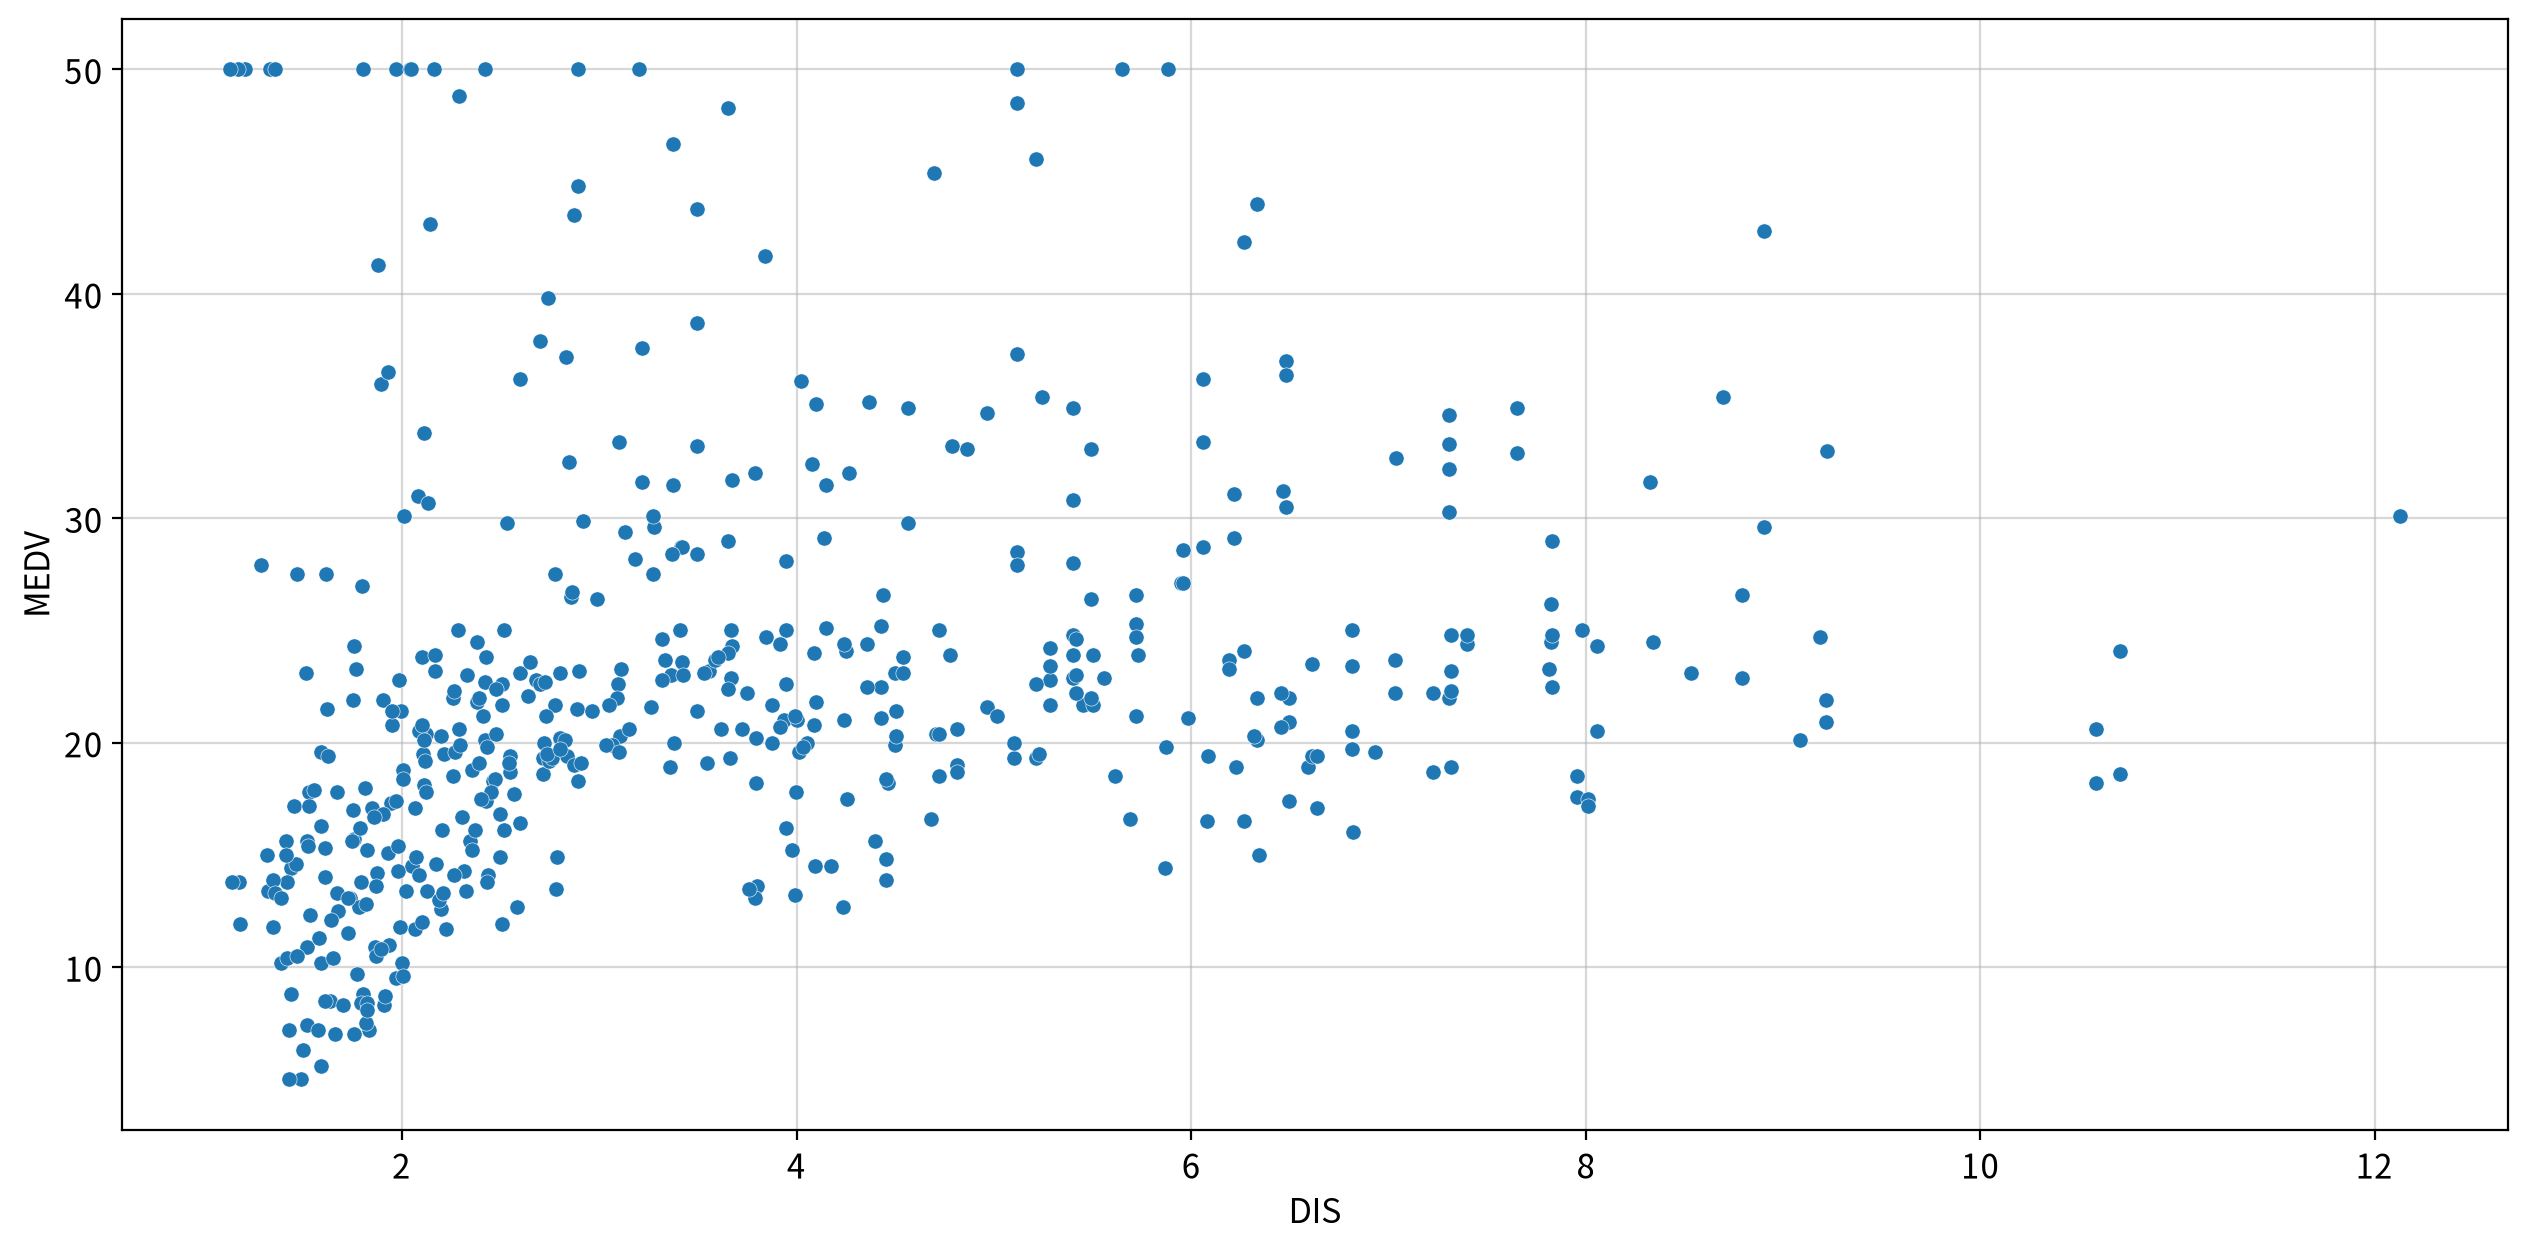

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
DIS,MEDV,Spearman,0.446,0.000,Moderate,True,False,False,False,True,True


##### ▶︎ RAD(고속도로 접근성 지수) → MEDV

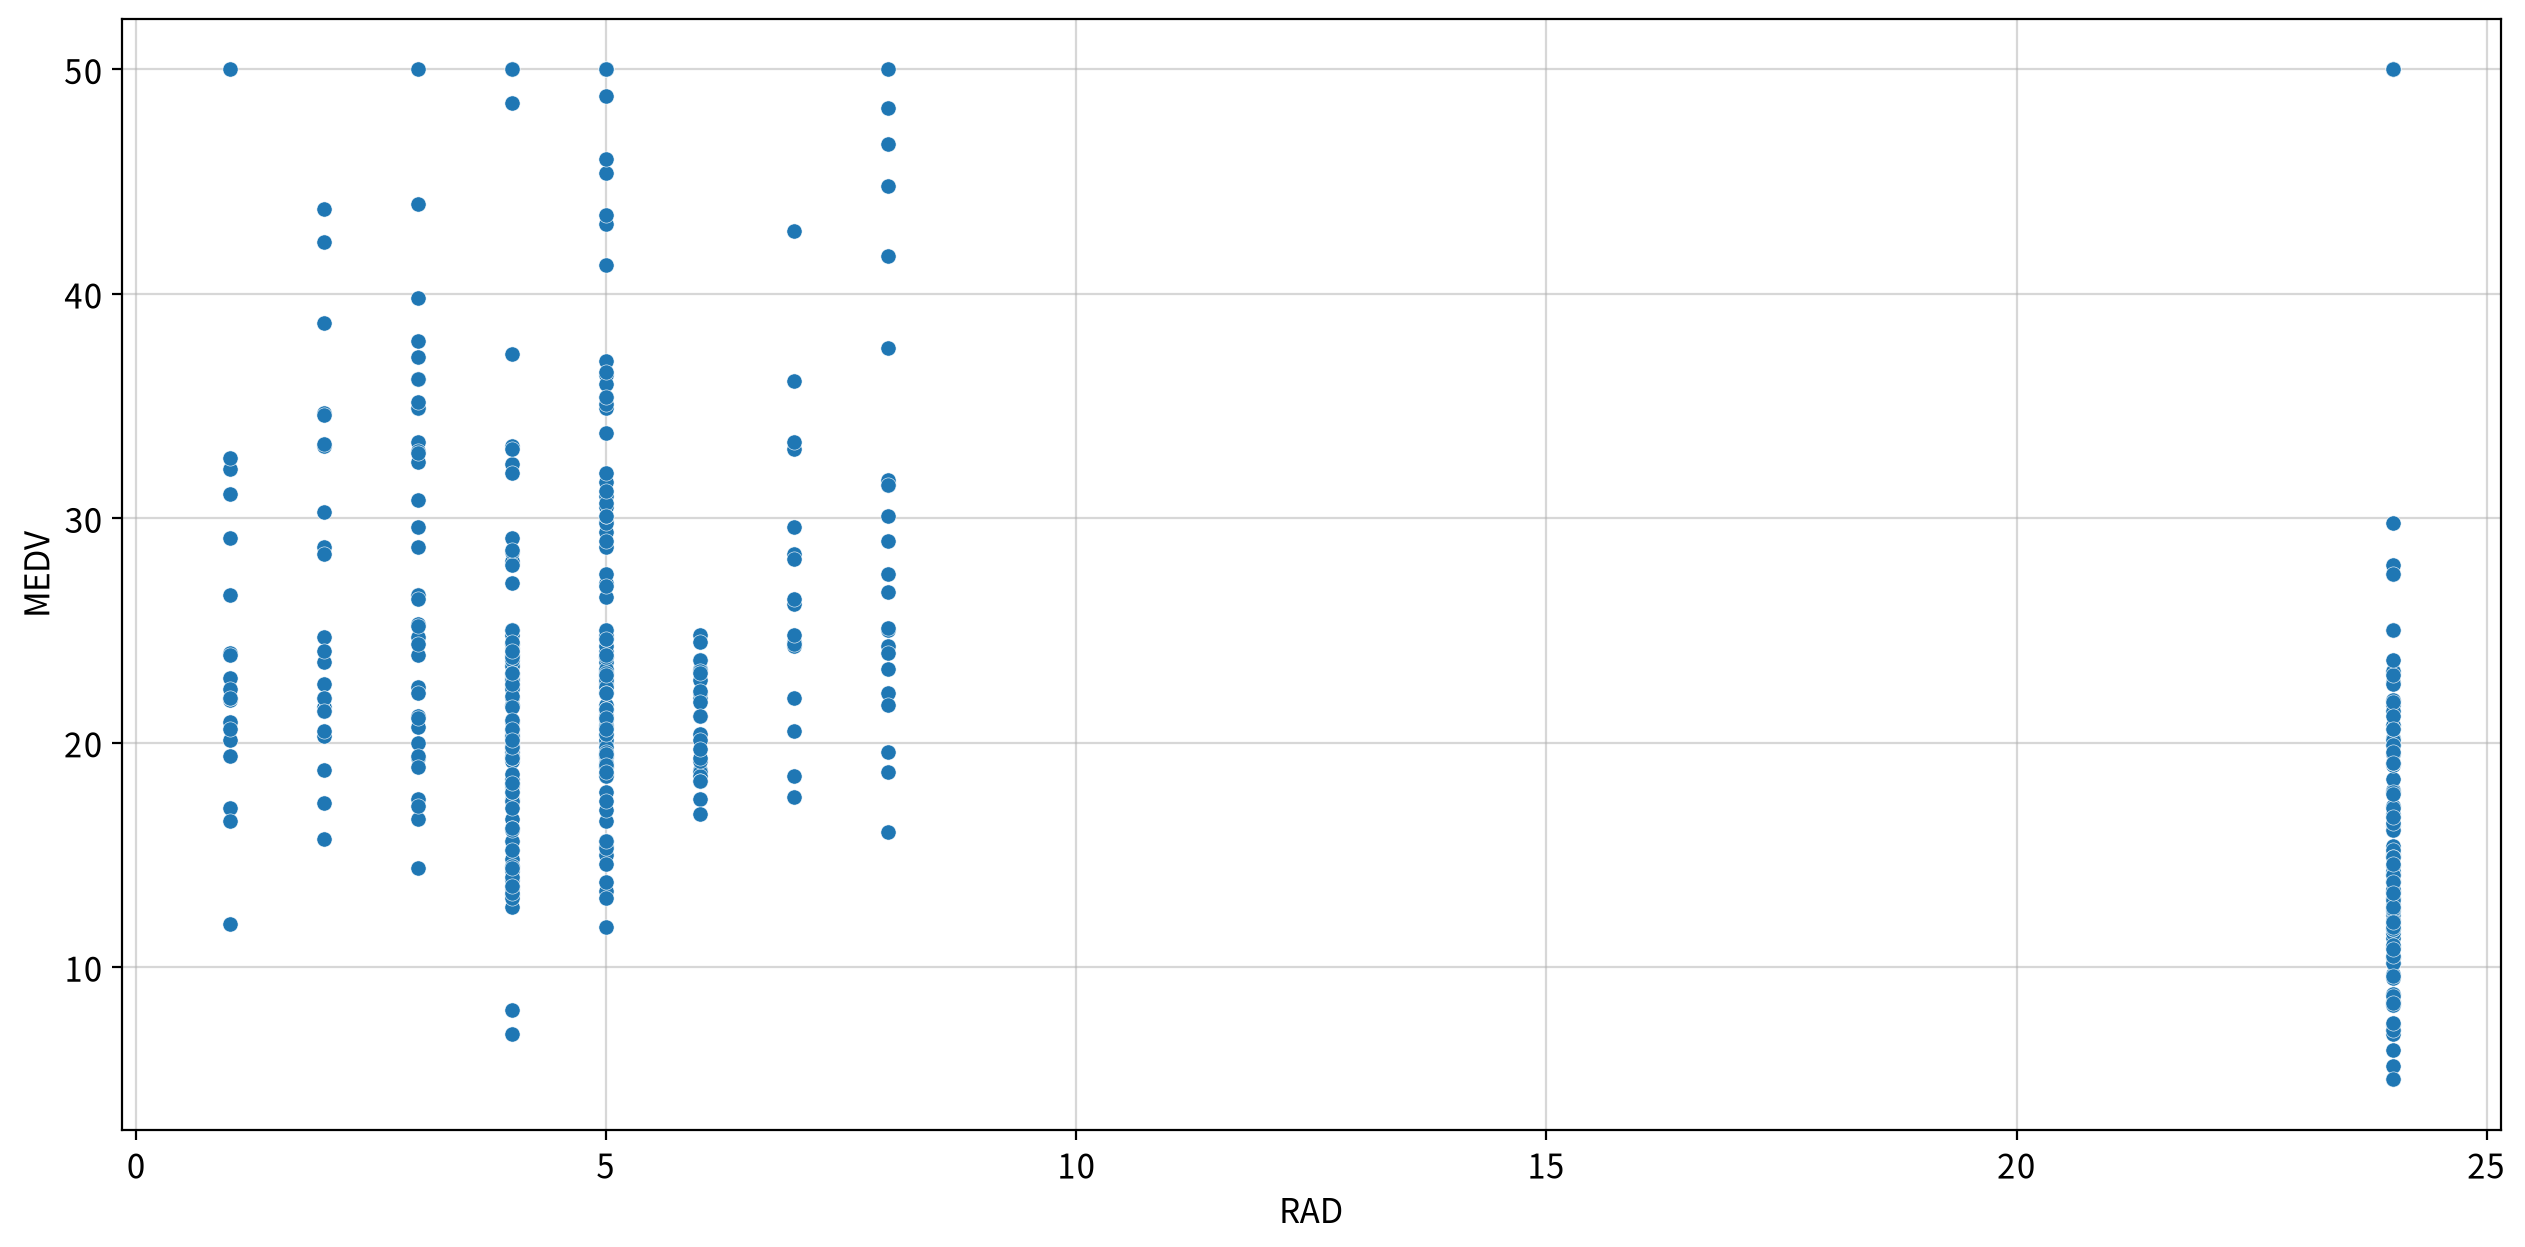

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
RAD,MEDV,Spearman,-0.347,0.000,Moderate,True,False,False,False,True,True


##### ▶︎ TAX(재산세율) → MEDV

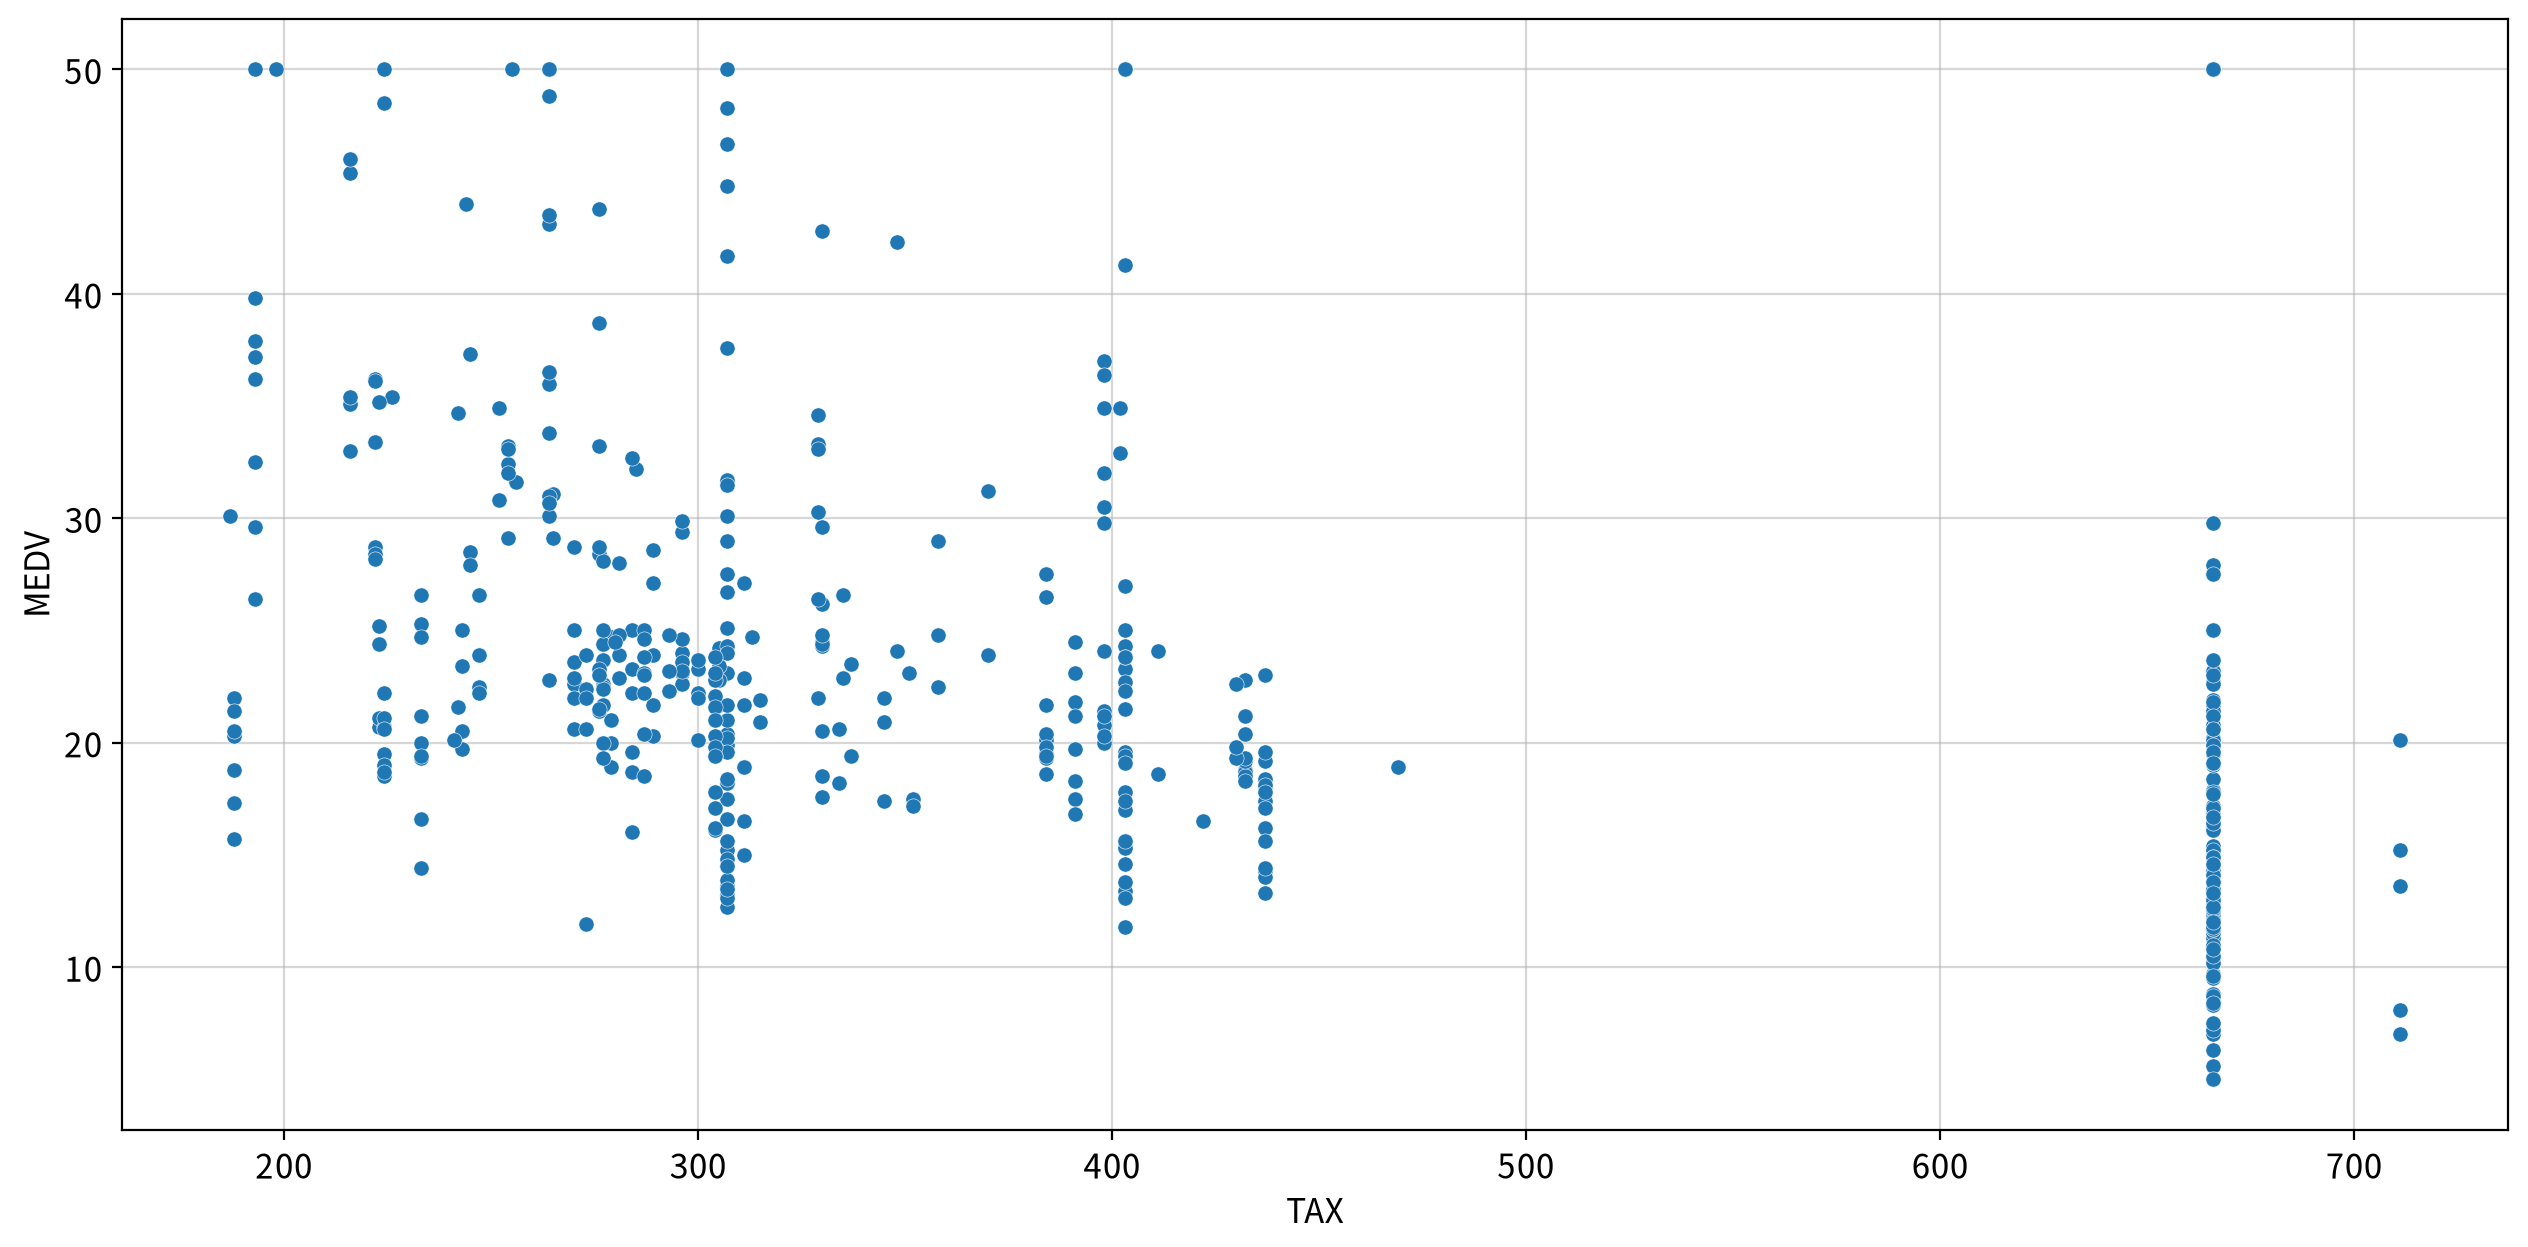

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
TAX,MEDV,Spearman,-0.562,0.000,Moderate,True,False,False,True,True,True


##### ▶︎ PTRATIO(학생-교사 비율) → MEDV

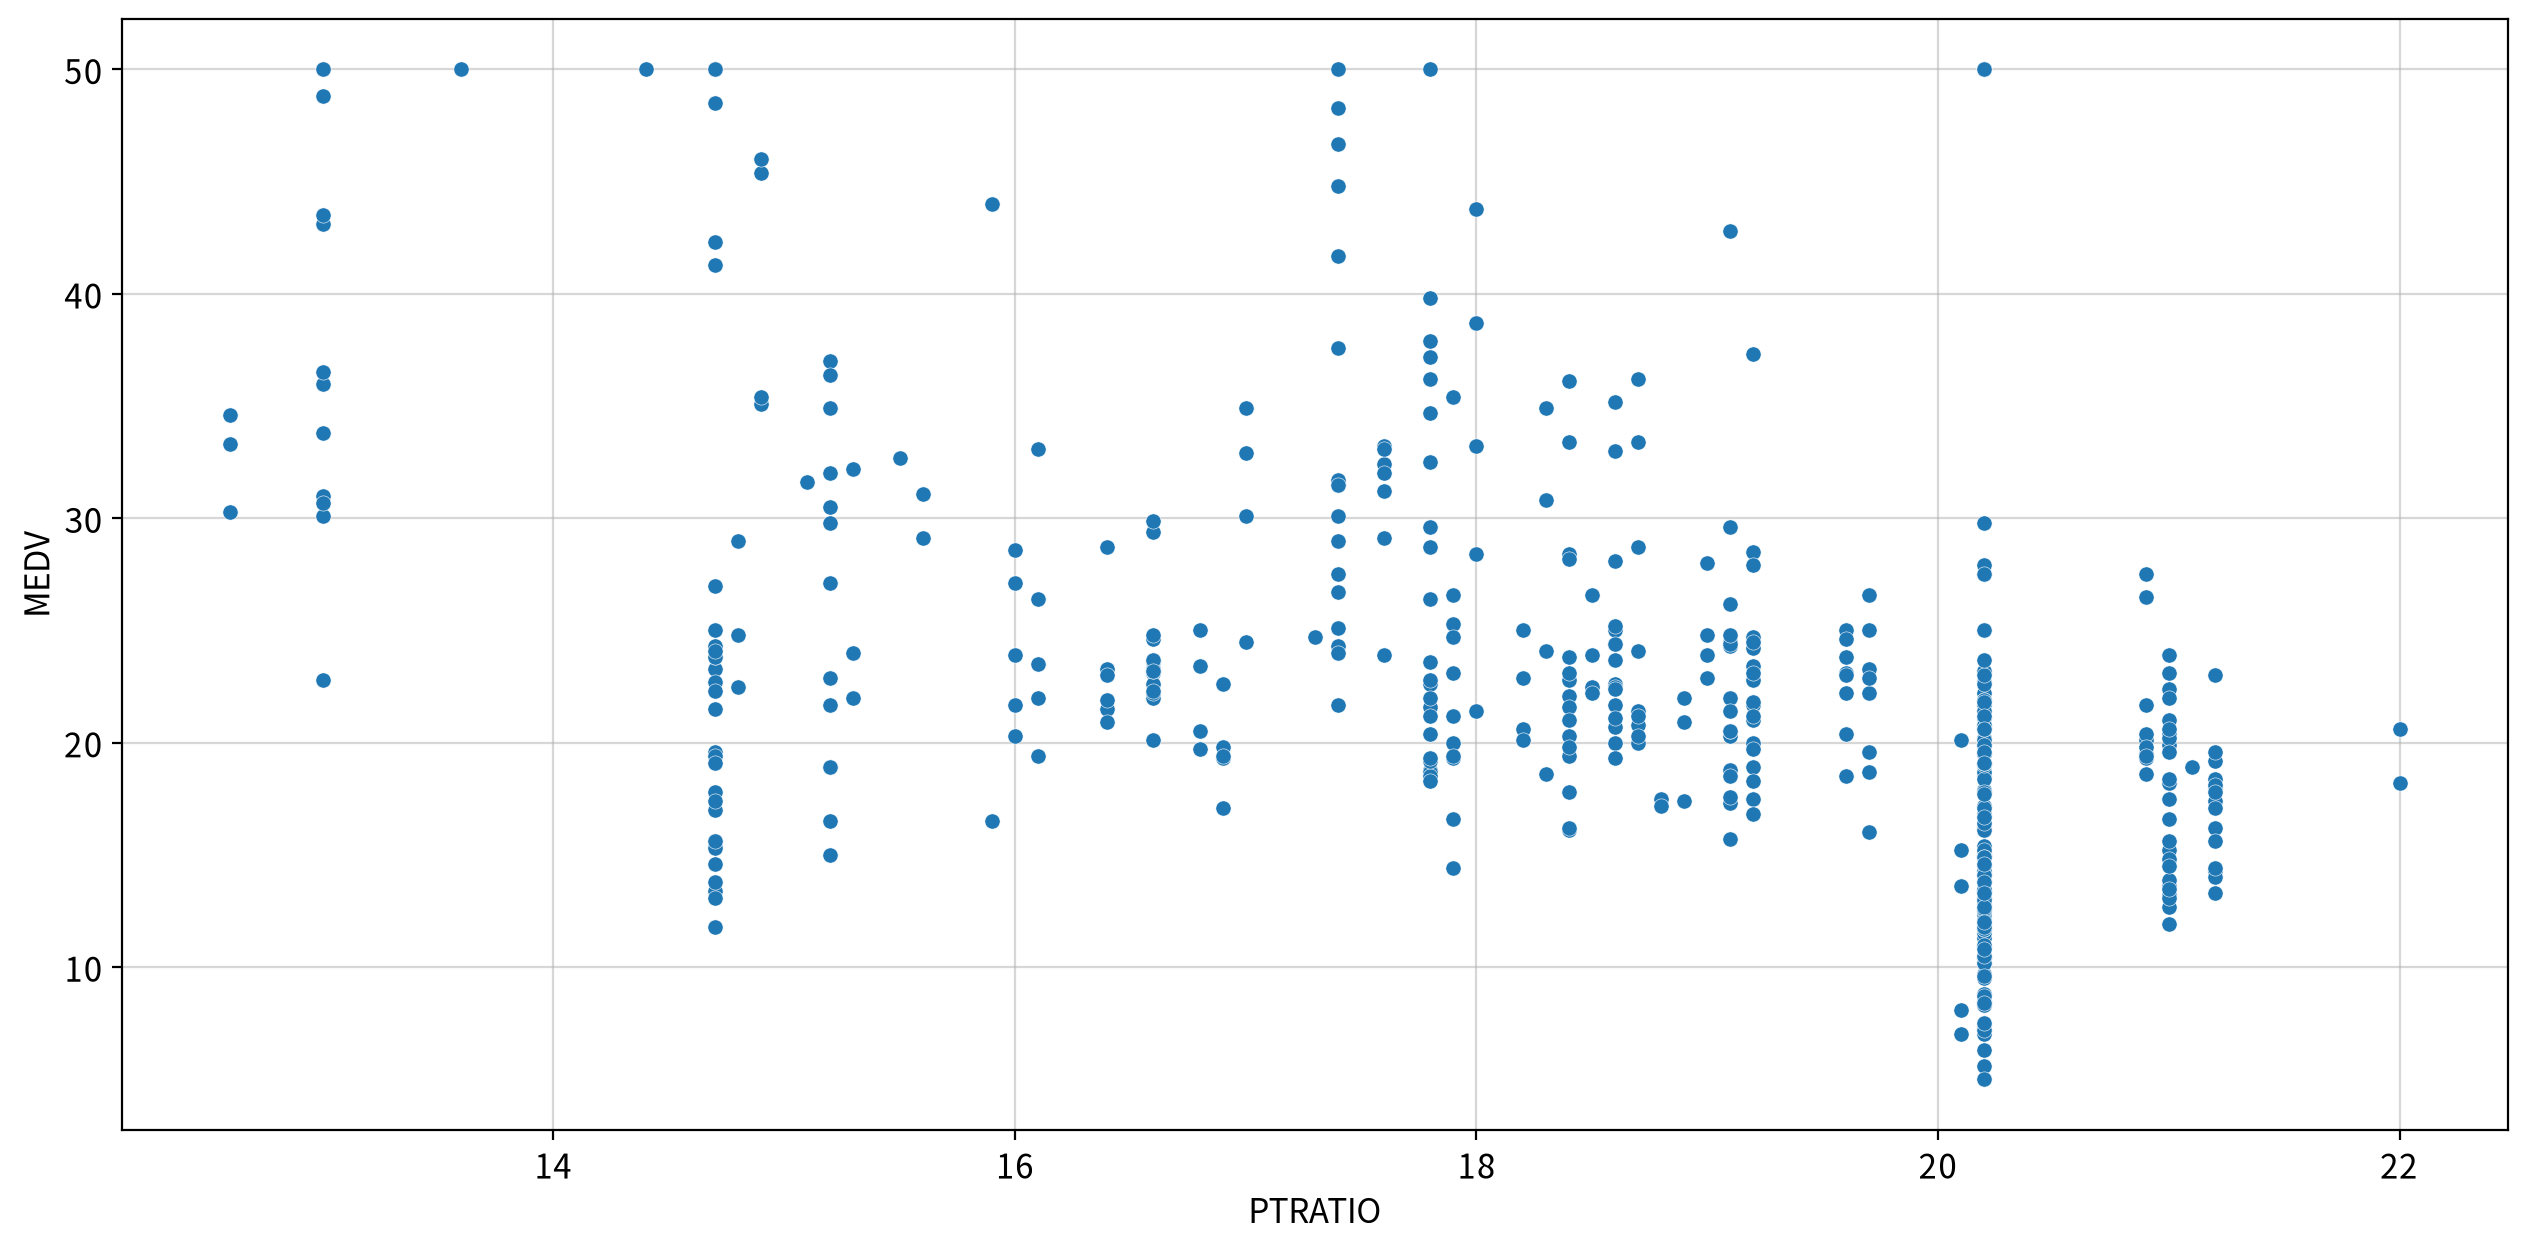

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
PTRATIO,MEDV,Spearman,-0.556,0.000,Moderate,True,False,False,True,False,True


##### ▶︎ B(흑인 비율 지수) → MEDV

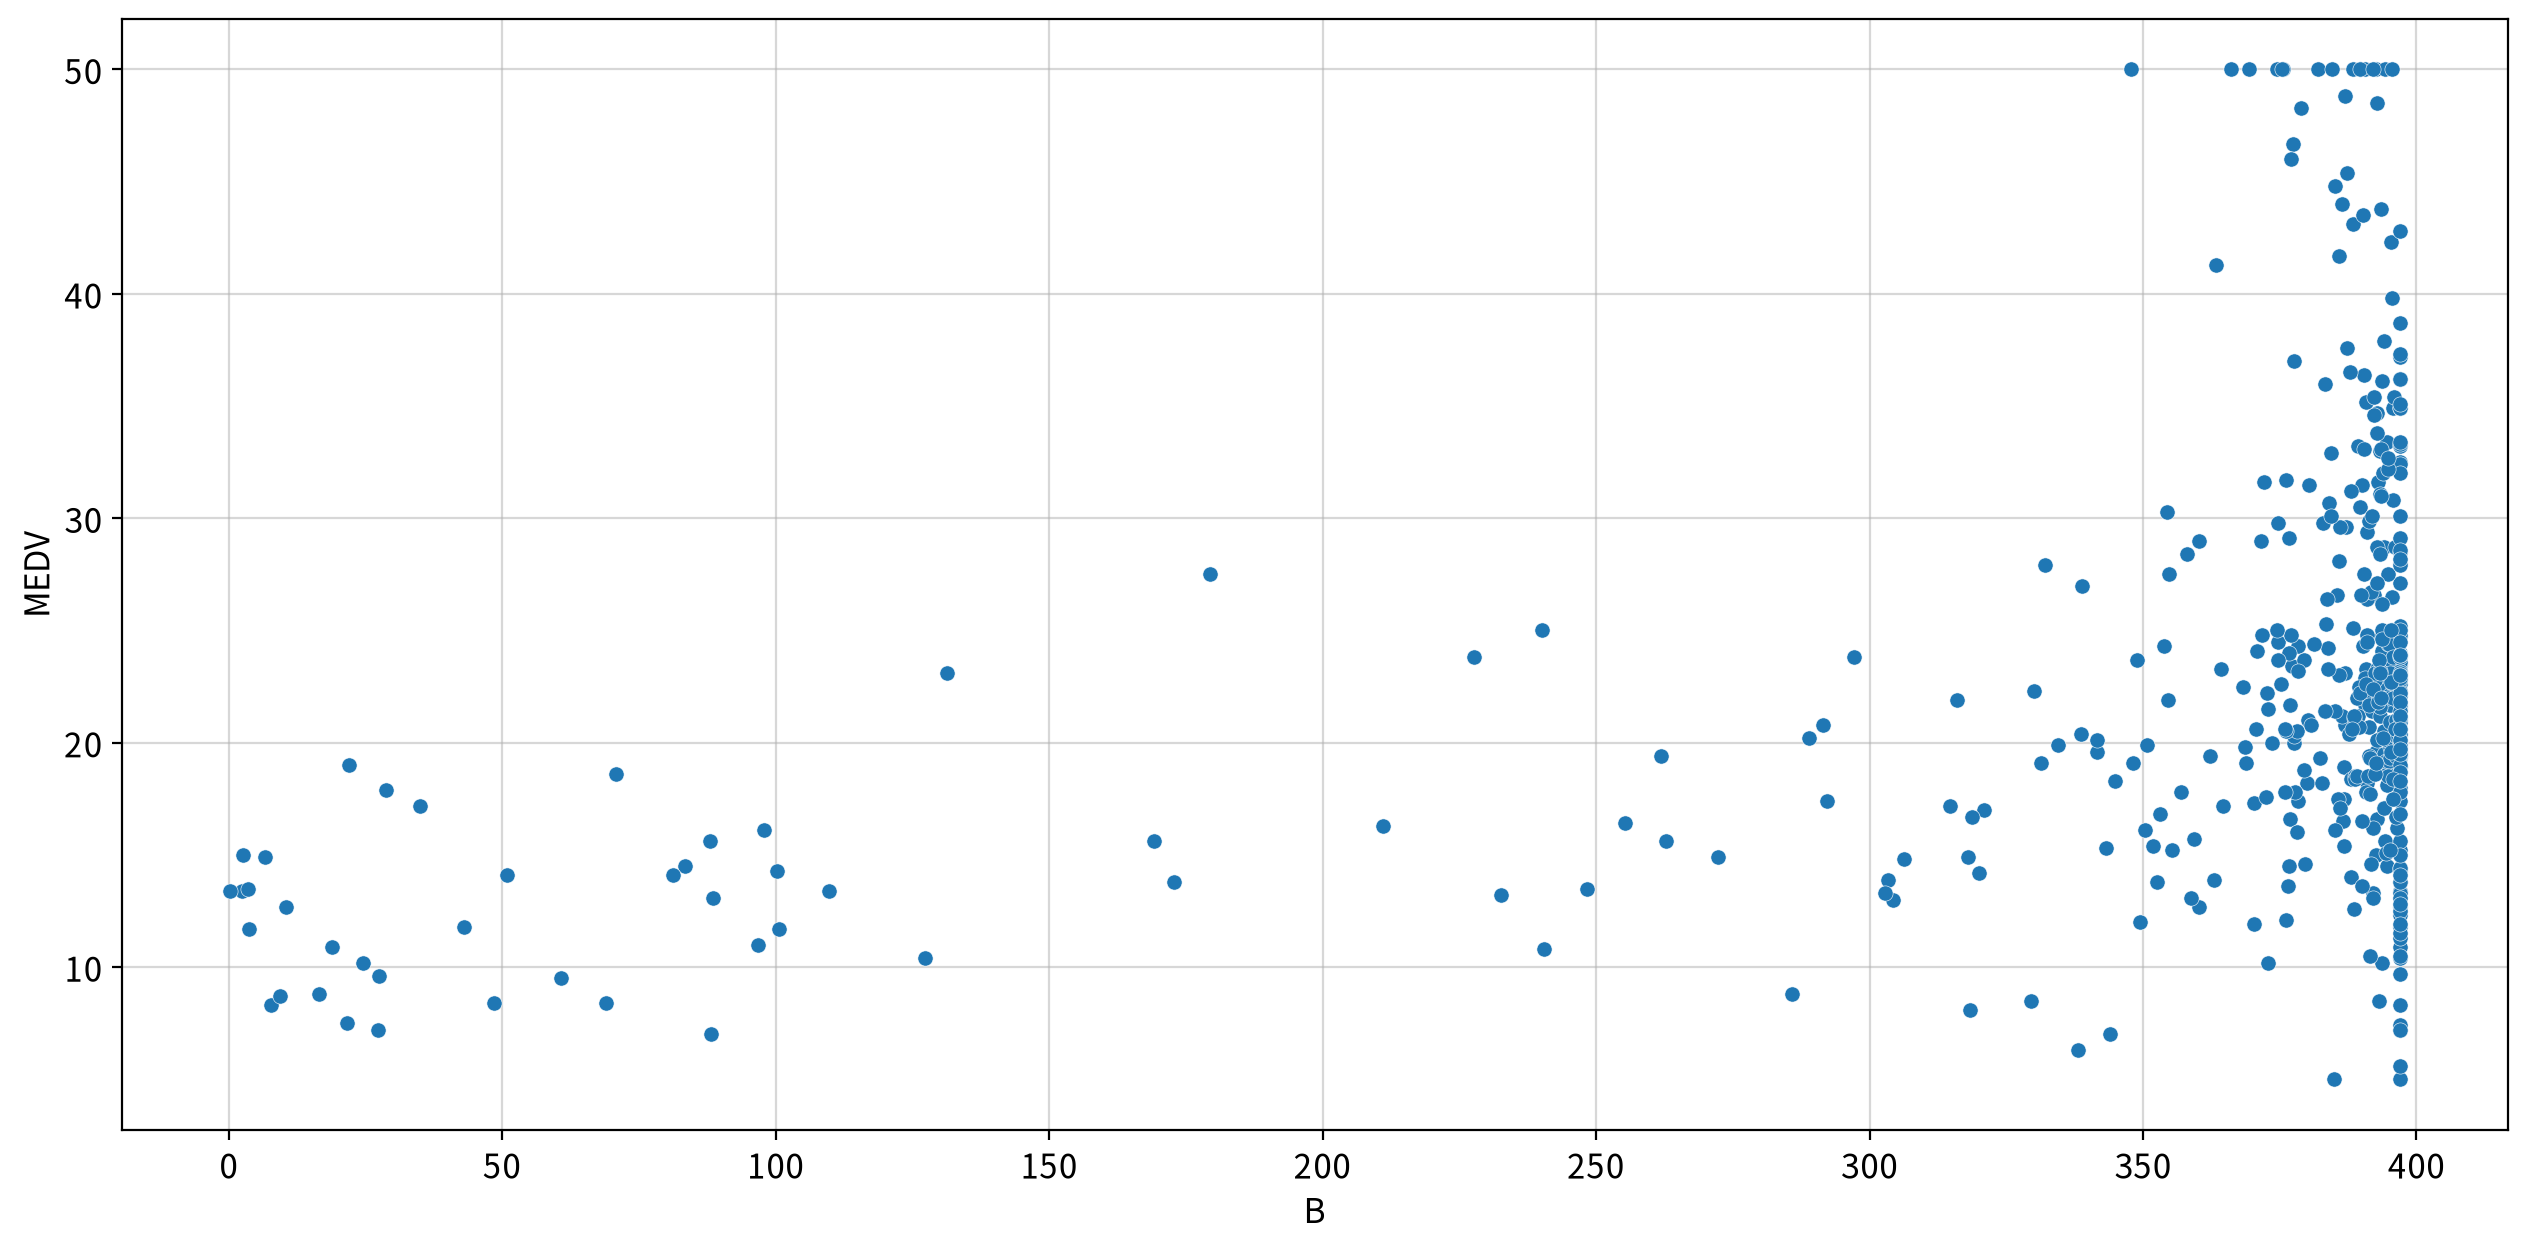

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
B,MEDV,Spearman,0.186,0.000,Weak,True,False,False,True,True,True


##### ▶︎ LSTAT(저소득층 비율(%)) → MEDV

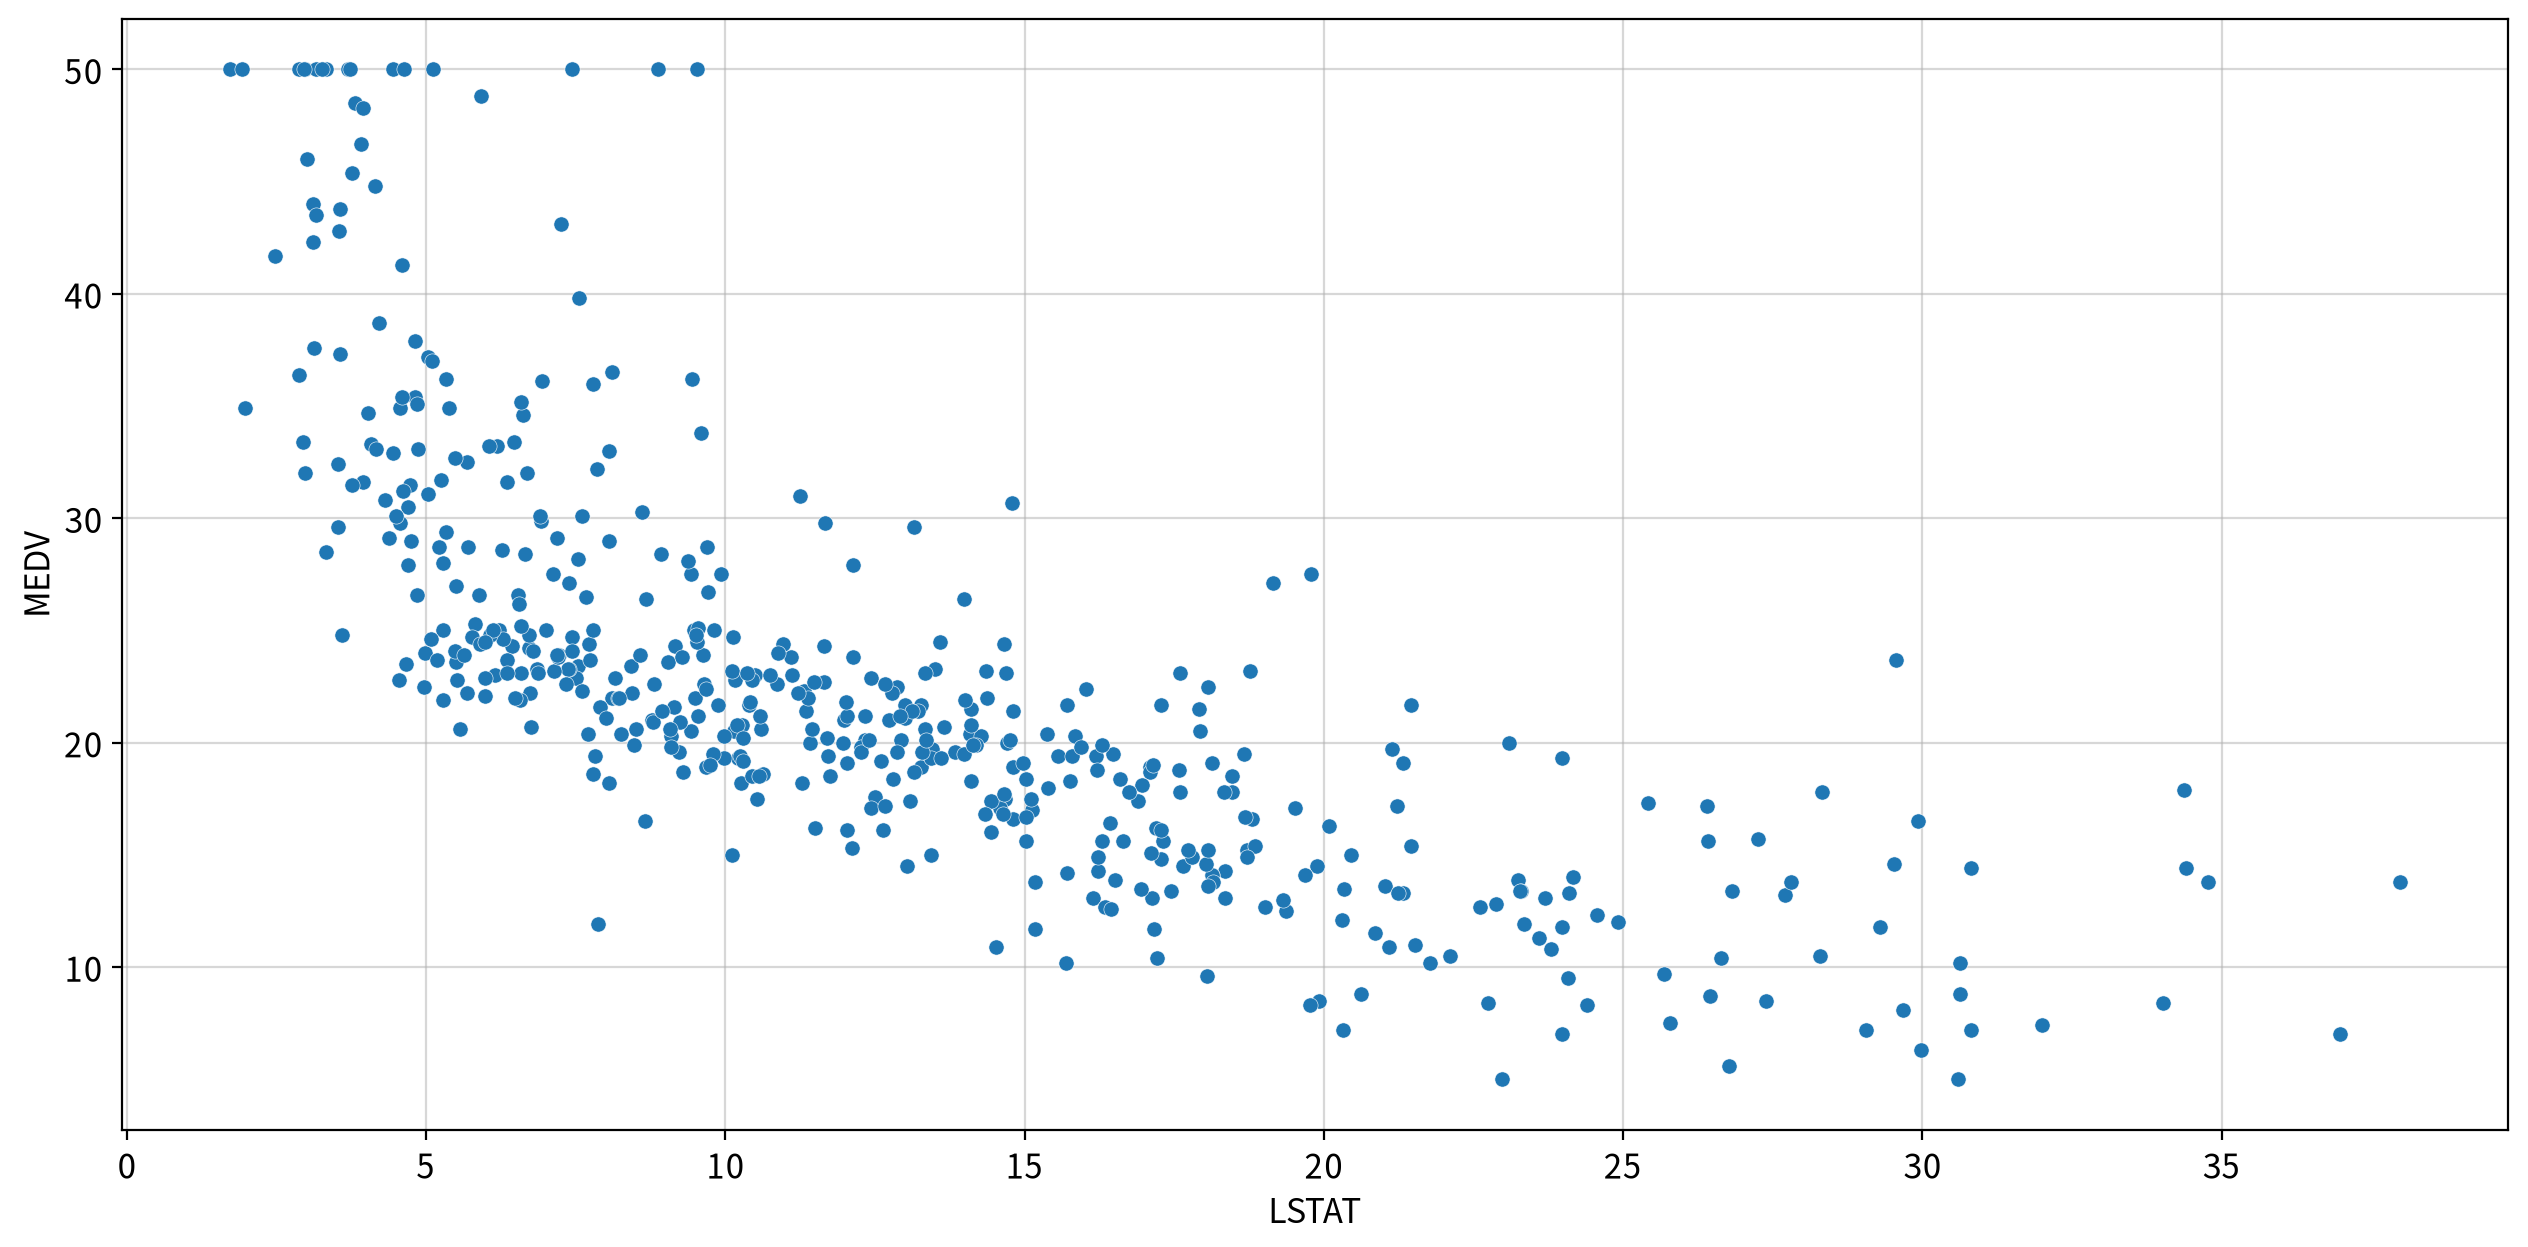

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
LSTAT,MEDV,Spearman,-0.853,0.000,Strong,True,False,False,False,False,True


In [17]:
## 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    ## 빈 줄 출력용
    print()

    ## 분석 단위 제목 출력
    display(Markdown(f"##### ▶︎ {f}({column_means[f]}) → {target}"))

    ## 시각화
    my_plot.scatterplot(data=df, x=f, y=target, outline=False,
                        ## 데이터 밀도에 따라 외곽선 굵기와 점 크기 조절
                        linewidth=0.2, size=30)

    ## my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))

**해석**

| 변수 | 선형/비선형 | 단조성 | 산포 | 이상치 | 채택 여부 |
|---|---|---|---|---|---|
| `LSTAT` | **비선형** (아래로 볼록) | **강한 음의 단조↓** (ρ = −0.853) | 이분산 (부채꼴) | 상단 소수 | ✅ **채택 (최우선)** |
| `RM` | 대체로 선형 | 양의 단조↑ (ρ = +0.634) | 중간 | 상·하단 30건 | ✅ 채택 |
| `INDUS` | 계단형(이봉) | 음의 단조↓ (ρ = −0.578) | 중간 | 영향점 검출 | ✅ 채택 |
| `NOX` | 비선형 | 음의 단조↓ (ρ = −0.563) | 중간 | 영향점 검출 | ✅ 채택 |
| `TAX` | 계단형(이봉) | 음의 단조↓ (ρ = −0.562) | 중간 | 영향점 검출 | ✅ 채택 |
| `CRIM` | 비선형 (0 근처 밀집) | 음의 단조↓ (ρ = −0.559) | 강한 이분산 | 상단 66건 | ✅ 채택 (로그 후) |
| `PTRATIO` | 계단형 | 음의 단조↓ (ρ = −0.556) | 중간 | 소수 | ✅ 채택 |
| `AGE` | 대체로 선형 | 음의 단조↓ (ρ = −0.548) | 중간 | 영향점 검출 | ✅ 채택 |
| `DIS` | 비선형 | 양의 단조↑ (ρ = +0.446) | 중간 | 영향점 검출 | ✅ 채택 (로그 후) |
| `ZN` | 0에 밀집 | 양의 단조↑ (ρ = +0.438) | 중간 | 상단 68건 | 🟡 보류 |
| `RAD` | 두 덩어리로 분리 | 음의 단조↓ (ρ = −0.347) | 중간 | 영향점 검출 | 🟡 보류 — `TAX`와 중복 의심 |
| `B` | 사실상 무관 | 약한 양의 단조 (ρ = +0.186, **Weak**) | 큼 | 영향점 검출 | ❌ 제외 후보 — 설명력 부재 |

- **종속변수와 상관이 높은 변수:** **`LSTAT`(ρ = −0.853, Strong)** 이 압도적 1위이며, **12개 중 유일한 Strong 등급**이다. 그 뒤로 `RM`(+0.634), `INDUS`(−0.578), `NOX`(−0.563), `TAX`(−0.562)가 Moderate 구간에 몰려 있다.
- **산점도의 형태 — 선형회귀 적용이 타당한가:** 타당하다. 대부분의 변수가 **단조 증가 또는 단조 감소**의 추세를 보이며 U자·역U자 형태는 없다.
- **곡선 형태로 보이는 변수(변환 검토 대상):** `LSTAT`(아래로 볼록), `CRIM`(0 근처에 뭉쳐 관계가 보이지 않음), `DIS`. 세 변수 모두 `log_need`에서 로그 대상으로 판정되었다.
- `RAD`·`TAX`는 24 / 666에 값이 뭉쳐 있어 산점도가 **두 덩어리**로 갈린다. 회귀선의 기울기가 이 덩어리에 좌우되므로 계수 해석에 주의가 필요하다.

##### 2) T-Test (x: 2집단 명목형 독립변수 → y: 종속변수)

- 2개의 고유값만 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.

##### ▶︎ CHAS(찰스강 인접 여부) → MEDV

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.582e-03 U_stat=5.606e+03


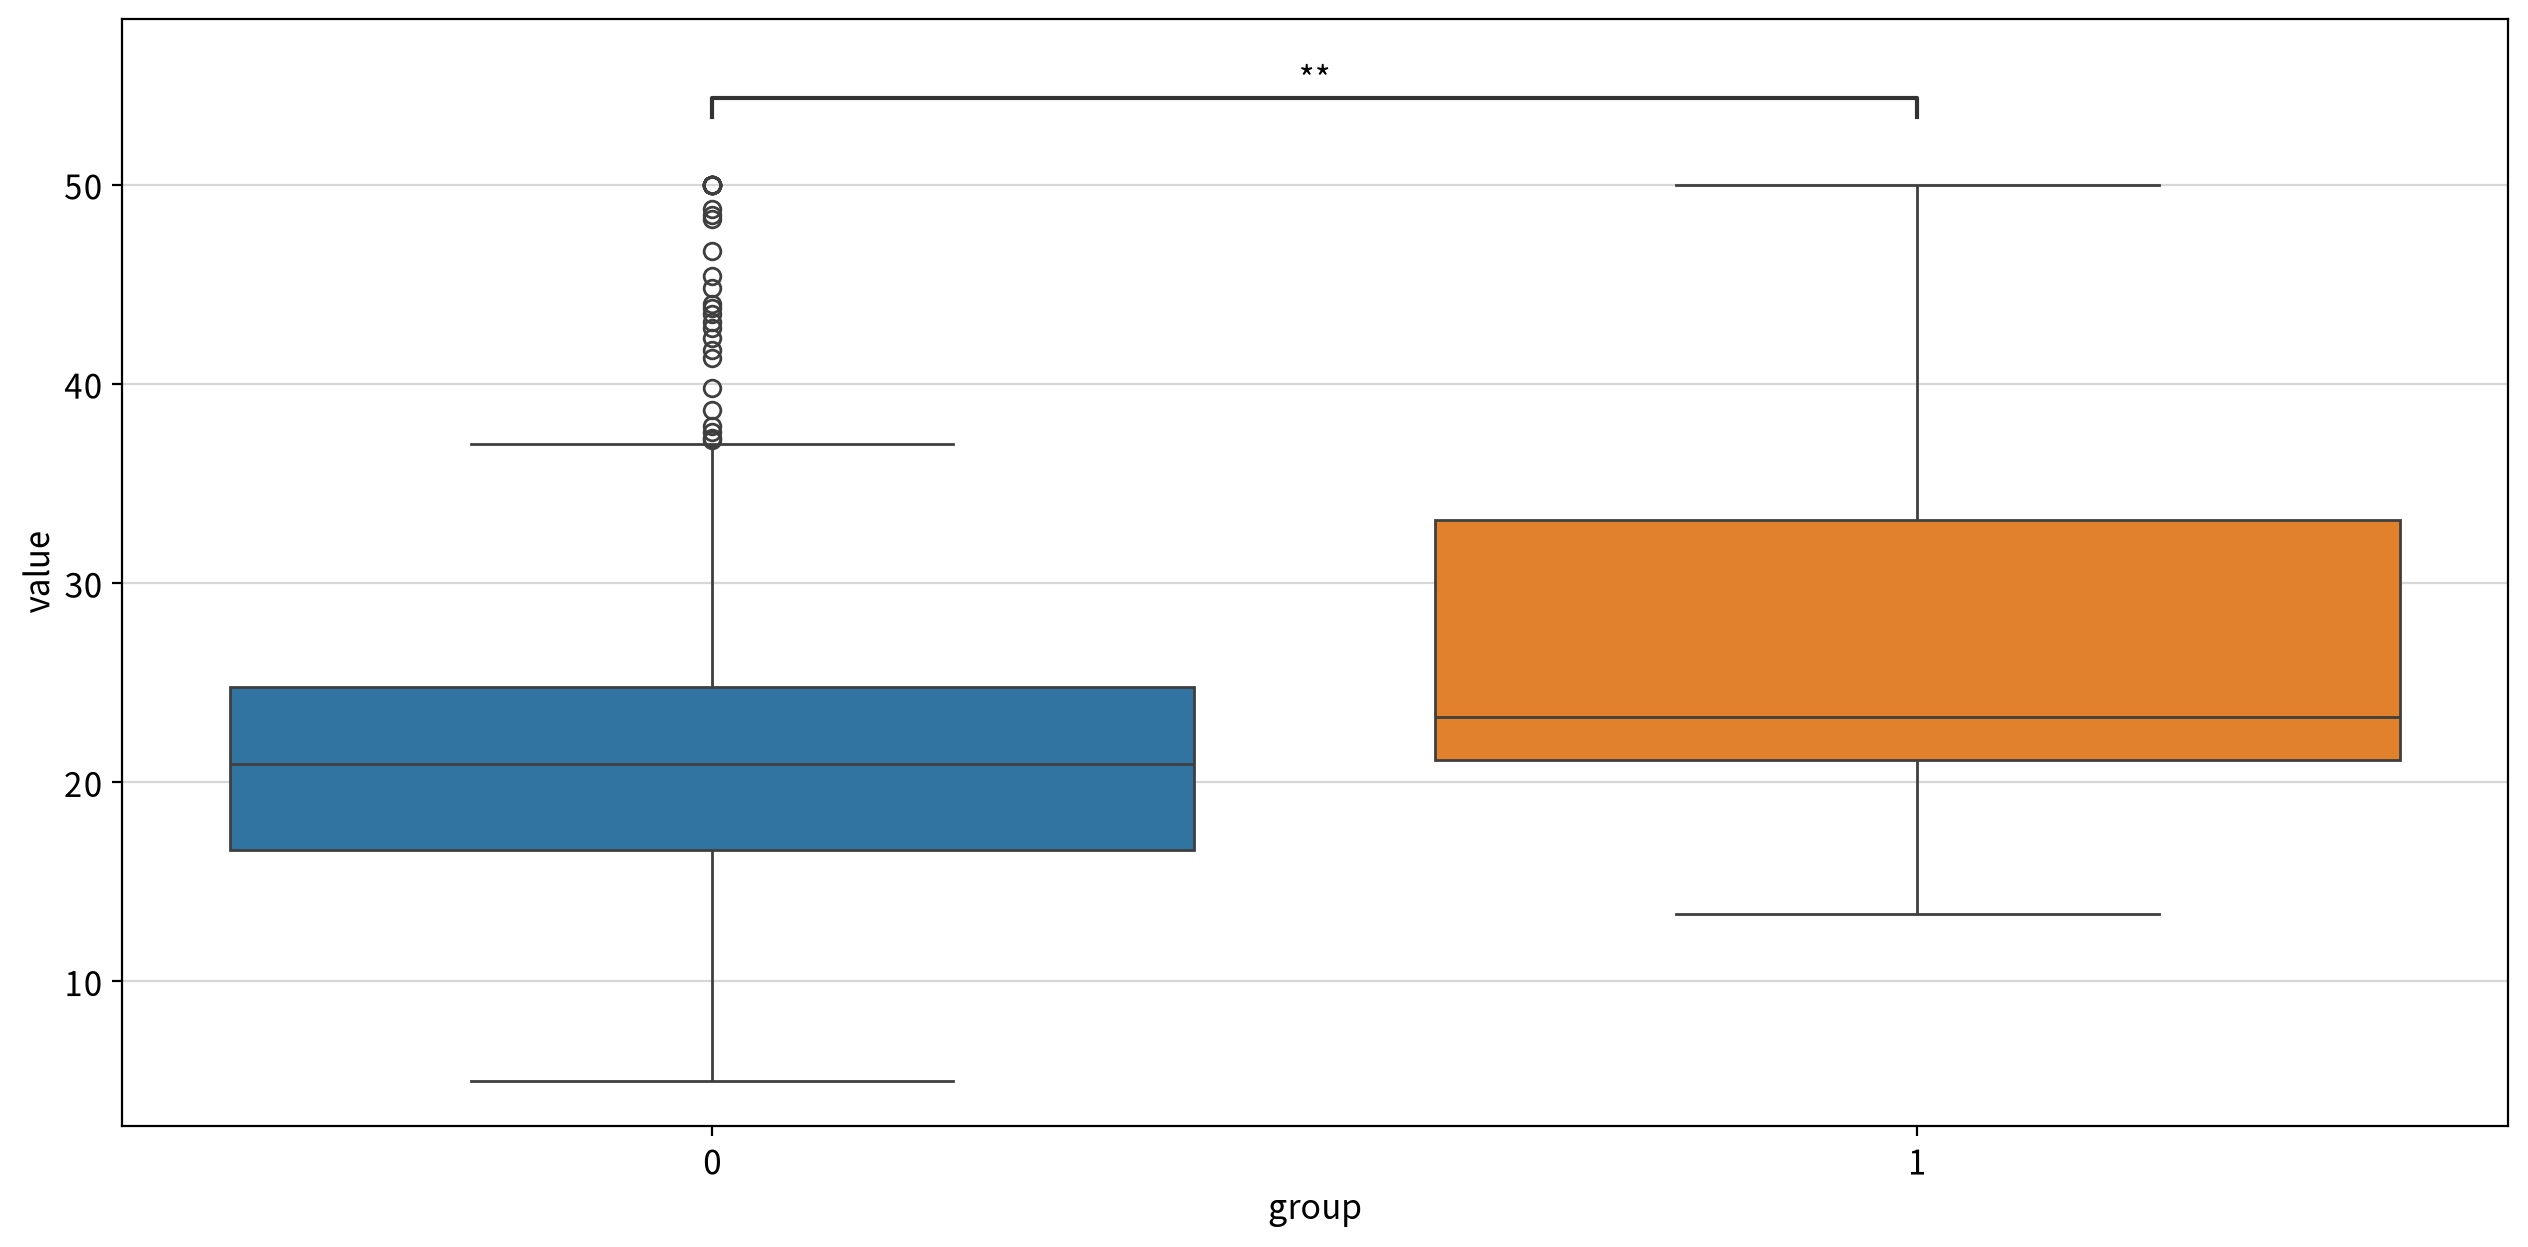

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided     5605.500    0.002         True  0 ≠ 1
                    less          5605.500    0.001         True  0 < 1
                    greater       5605.500    0.999        False  0 ≤ 1

In [18]:
for n in nominal_cols:
    ## 2개의 고유값만 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) == 2:
        ## 빈 줄 출력용
        print()

        ## 분석 단위 제목 출력
        display(Markdown(f"##### ▶︎ {n}({column_means[n]}) → {target}"))

        ## 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df,
                    group1=wide_df.columns[0], group2=wide_df.columns[1]))

**검정 결과**

| 변수 | 검정 | 통계량 | p-value | 판단 | 관련 가설 |
|---|---|---|---|---|---|
| `CHAS` | Mann-Whitney U (정규성 위배로 비모수 검정 자동 선택) | U = 5605.5 | **.002** (양측) | **차이 있음** (α = .05) | H4 — **채택** |

- 찰스강에 인접한 구역(35건)의 주택가격이 비인접 구역보다 **유의하게 높다**(단측 검정 0 < 1 에서 p = .001).
- 다만 `CHAS` = 1 이 35건(6.9%)뿐이라 **표본 불균형이 심하다.** 다변량 모형에서 다른 변수를 통제한 뒤 계수의 유의성을 다시 확인한다.

##### 3) ANOVA (x: 3집단 명목형 독립변수 → y: 종속변수)

- 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
  - 3개 이상의 고유값을 갖는 명목형이 없을 경우 출력 결과가 없을 수 있다.

In [19]:
for n in nominal_cols:
    ## 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) >= 3:
        print() ## 빈 줄 출력용

        ## 분석 단위 제목 출력
        display(Markdown(f"##### ▶︎ {n}({column_means[n]}) → {target}"))

        display(my_stats.anova_oneway(df, y=target, between=n))

        ## 사후검정
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

**해석**

- 이 데이터셋에는 **해당 없음.** 명목형 변수가 `CHAS`(2집단) 하나뿐이므로 반복문이 한 번도 실행되지 않아 출력이 비어 있다.
- #4-1의 EDA 범위 정리 표에서 미리 "3집단 이상 명목형 없음 → ANOVA 미적용"으로 판정한 내용과 일치한다.

#### 4-3. 다변량 분석 — 독립변수 간 상관

In [20]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
CRIM,1.000,-0.572,0.736,0.822,-0.309,0.704,-0.745,0.728,0.729,0.465,-0.361,0.635
ZN,-0.572,1.000,-0.643,-0.635,0.361,-0.544,0.615,-0.279,-0.371,-0.449,0.163,-0.490
INDUS,0.736,-0.643,1.000,0.791,-0.415,0.679,-0.757,0.456,0.664,0.434,-0.286,0.639
NOX,0.822,-0.635,0.791,1.000,-0.310,0.795,-0.880,0.586,0.649,0.391,-0.297,0.637
RM,-0.309,0.361,-0.415,-0.310,1.000,-0.278,0.263,-0.107,-0.272,-0.313,0.054,-0.641
AGE,0.704,-0.544,0.679,0.795,-0.278,1.000,-0.802,0.418,0.526,0.355,-0.228,0.657
DIS,-0.745,0.615,-0.757,-0.880,0.263,-0.802,1.000,-0.496,-0.574,-0.322,0.250,-0.564
RAD,0.728,-0.279,0.456,0.586,-0.107,0.418,-0.496,1.000,0.705,0.318,-0.282,0.394
TAX,0.729,-0.371,0.664,0.649,-0.272,0.526,-0.574,0.705,1.000,0.453,-0.330,0.534
PTRATIO,0.465,-0.449,0.434,0.391,-0.313,0.355,-0.322,0.318,0.453,1.000,-0.072,0.467


,max-y,max-coef,count,columns
x,,,,
CRIM,NOX,0.822,6,"NOX, DIS, INDUS, TAX, RAD, AGE"
DIS,NOX,-0.880,4,"NOX, AGE, INDUS, CRIM"
NOX,DIS,-0.880,4,"DIS, CRIM, AGE, INDUS"
AGE,DIS,-0.802,3,"DIS, NOX, CRIM"
INDUS,NOX,0.791,3,"NOX, DIS, CRIM"
TAX,CRIM,0.729,2,"CRIM, RAD"
RAD,CRIM,0.728,2,"CRIM, TAX"
LSTAT,AGE,0.657,0,-
ZN,INDUS,-0.643,0,-


**해석**

- **Strong 구간(|ρ| ≥ 0.7)의 쌍:** `NOX`–`DIS`(−0.880), `CRIM`–`NOX`(+0.822), `AGE`–`DIS`(−0.802), `INDUS`–`NOX`(+0.791), `TAX`–`CRIM`(+0.729), `RAD`–`CRIM`(+0.728)
- **공통 구조:** **"도심 = 공업지구 = 오염 심함 = 고용센터에 가까움 = 노후 주택 = 범죄율 높음 = 고속도로 접근성/세율 높음"** 이라는 **하나의 도시 구조 축**에 여러 변수가 함께 실려 있다.
- **`CRIM`이 허브다.** 혼자서 6개 변수(`NOX`·`DIS`·`INDUS`·`TAX`·`RAD`·`AGE`)와 Strong 관계다.
- **`TAX`와 `RAD`는 서로 중복 의심** — 두 변수 모두 `CRIM`과 0.73 수준으로 얽혀 있고, 단변량 분포도 24/666에서 똑같이 이봉이다.
- **서로 중복이 없는 변수:** `LSTAT`·`RM`·`PTRATIO`·`ZN`·`B` 는 Strong 상대가 없다. 특히 설명력 1위인 `LSTAT`이 독립적이라는 점이 다행이다.
- → 기계적 제거(VIF)와 **도메인 지식에 근거한 제거**를 #6에서 각각 시도해 비교한다.

#### 4-4. 모델링 설계 근거

**가설 확정**

| 가설 | EDA 근거 | 확정 / 수정 / 기각 |
|---|---|---|
| H1. 방 개수 ↑ → 가격 ↑ | ρ = +0.634 (Moderate, 2위), 산점도 우상향 | **확정** |
| H2. 저소득층 비율 ↑ → 가격 ↓ | ρ = −0.853 (Strong, 유일한 1위), 단 관계가 **곡선** | **수정** — 방향은 유지하되 **로그-로그**로 적합 |
| H3. 오염·범죄 ↑ → 가격 ↓ | `NOX` ρ = −0.563, `CRIM` ρ = −0.559 (둘 다 Moderate·유의) | **확정** |
| H4. 찰스강 인접 → 가격 ↑ | Mann-Whitney U p = .002 (유의) | **확정** — 단 n = 35로 불균형 |

**투입 변수 선정**

- 투입할 변수: **13개 전부**(`CRIM`, `ZN`, `INDUS`, `CHAS`, `NOX`, `RM`, `AGE`, `DIS`, `RAD`, `TAX`, `PTRATIO`, `B`, `LSTAT`)
  - 이유: 모든 연속형 변수가 `MEDV`와 **유의한 상관**을 보였고(가장 약한 `B`도 ρ = +0.186, p < .001), 사전에 지울 근거가 없다.
  - 변수 선택은 감으로 하지 않고 **VIF 자동 제거 + 후진소거법**에 맡긴 뒤, 그 결과를 **도메인 지식에 근거한 제거와 비교**한다(Q3).
- 제외할 변수와 이유: **사전 제외 없음.** 단 `B`는 윤리적 문제가 있는 변수이므로, 유의하게 남더라도 사회적 해석의 근거로 삼지 않는다.

**변수 변환 필요성**

- 로그변환 대상: `CRIM`, `DIS`, `RAD`, `LSTAT`, `MEDV` → `log` / `ZN` → `log1p`(0이 많음) / `B` → 반사 후 `log1p`(좌측 꼬리)
- 이상치 대체 후보: `RM`(30건), `PTRATIO`(15건) — 로그 변환으로 해소되지 않는 변수

**평가지표 우선순위와 이유**

> **1순위 RMSE, 2순위 변수 수(간명성).**
> 로그 변환을 적용한 모형과 하지 않은 모형은 종속변수의 **척도가 달라 R²·AIC를 직접 비교할 수 없다.**
> 반면 RMSE는 예측값을 원래 단위(천 달러)로 되돌려 계산하므로 척도가 다른 모형끼리도 공정하게 비교된다.
> 다만 최종 목적은 "무엇이 가격을 움직이는가"의 설명이므로, RMSE 차이가 5% 이내로 근소하면 **변수가 적고 해석이 쉬운 모형**을 택한다.
> (`compare_models()` 의 `tolerance=0.05`, `sub_metric='변수수'` 기본값이 이 기준을 그대로 구현한다.)

## #5. 모델링

#### 5-1. 후진소거법에 의한 모델 성능 비교

전진선택은 변수를 하나씩 넣기 때문에 **다른 변수를 통제했을 때 비로소 유의해지는 변수**를 놓친다.

이 데이터는 변수 간 상관이 강해(#4-3) **전부 투입한 상태에서 가장 유의하지 않은 것부터 하나씩 빼는** 방식이 안전하다.

`my_ols.fit_pipeline()` 은 한 번에 한 변수씩 제거하며, **등분산이 위배되면 HC3 로버스트 p-value**를 제거 기준으로 삼는다.

##### 1) 더미변수의 기준 확인

- `labeling` 은 명목형의 값을 **알파벳 순서**로 0부터 매긴다.
- 이어지는 `encode`(더미 인코딩)가 이 정수를 컬럼명에 사용하므로, 회귀계수를 해석하려면 매핑을 알아야 한다.
- `drop_first=True` 로 **0번 범주가 기준** 이 되어 빠진다. 더미 계수는 모두 이 기준 범주 대비 차이다.

In [21]:
## 라벨 매핑만 확인하는 용도 (반환값은 사용하지 않는다)
_ = my_prep.labeling(df, columns=nominal_cols)

CHAS (2종): 0=0, 1=1


##### 2) 모델링용 전처리 파이프라인

| 처리 항목 | 대상 변수 | 적용 기준 | 이유 | 전후 변화 |
|---|---|---|---|---|
| 로그 변환 | `CRIM`·`DIS`·`RAD`·`LSTAT`·`MEDV` | `log_need` = log (우측 꼬리) | 왜도 완화 + 곡선 관계 직선화 | 왜도 최대 +5.22 → +0.40 |
| 로그 변환(log1p) | `ZN` | 0이 포함되어 log 불가 | `log(0)` = −∞ 회피 | 왜도 +2.23 → +1.19 |
| 반사 후 로그 변환 | `B` | `log_need` = reverse_log1p (좌측 꼬리) | 좌측 꼬리는 뒤집은 뒤 로그 | 왜도 −2.89 → 대칭에 근접 |
| 이상치 대체 | 로그 변환 후에도 남은 변수 | IQR × 1.5 경계값으로 대체 | 실재하는 값이라 삭제 대신 영향력만 축소 | 행 수 변화 없음(506행 유지) |
| 더미 인코딩 | `CHAS` | `drop_first=True` | 이진 변수라 원 컬럼 유지 | 열 수 변화 없음 |
| 공선성 제거 | 전체 연속형 | VIF ≥ 10 | 중복 변수 자동 제거 | 최대 VIF 8.88 → 제거 없음 |
| 변수 선택 | 전체 | 후진소거법 (α = .05, HC3 기준) | 유의하지 않은 변수 제거 | 13개 → 7~11개 |

In [22]:
checkpoints = {
    "0_기준선(공선성제거)":    dict(vif=True),
    "1_로그변환":   dict(log=True, vif=True),
    "2_이상치대체": dict(log=True, outlier=True, vif=True)
}

##### 3) 모델링

In [23]:
fits= {}

for name in checkpoints:
    print(f"\n▶︎ --- {name} ---")

    ## 전처리 + 모델 적합을 한 번에 수행한다.
    ## -> name 을 지정해 두면 compare_models 의 결과표에 그대로 사용된다.
    fits[name] = my_ols.fit_pipeline(df, target, nominal_cols=nominal_cols, name=name, verbose=False, **checkpoints[name])

## 성능표를 출력하고 가장 좋은 모델을 반환받는다
best_fit = my_ols.compare_models(fits)

print("최종 모델 :", best_fit.name_)
print("독립변수  :", int(best_fit.df_model), "개")


▶︎ --- 0_기준선(공선성제거) ---

완료! 남은 변수: ['AGE', 'B', 'CRIM', 'DIS', 'INDUS', 'LSTAT', 'NOX', 'PTRATIO', 'RAD', 'RM', 'TAX', 'ZN']
최대 VIF = 8.88

유의하지 않은 독립변수 제거 → AGE (p = 0.9678)
유의하지 않은 독립변수 제거 → INDUS (p = 0.6898)

▶︎ --- 1_로그변환 ---

완료! 남은 변수: ['AGE', 'B', 'CRIM', 'DIS', 'INDUS', 'LSTAT', 'NOX', 'PTRATIO', 'RAD', 'RM', 'TAX', 'ZN']
최대 VIF = 7.56

유의하지 않은 독립변수 제거 → B (p = 0.9465)
유의하지 않은 독립변수 제거 → INDUS (p = 0.2089)
유의하지 않은 독립변수 제거 → AGE (p = 0.1922)

▶︎ --- 2_이상치대체 ---

완료! 남은 변수: ['AGE', 'B', 'CRIM', 'DIS', 'INDUS', 'LSTAT', 'NOX', 'PTRATIO', 'RAD', 'RM', 'TAX', 'ZN']
최대 VIF = 7.57

유의하지 않은 독립변수 제거 → B (p = 0.9141)
유의하지 않은 독립변수 제거 → AGE (p = 0.2096)
유의하지 않은 독립변수 제거 → INDUS (p = 0.1943)


,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
1_로그변환,10,0.762,0.757,-174.094,-127.602,0.777,4.336,3.075,0.000
2_이상치대체,10,0.762,0.757,-174.370,-127.878,0.775,4.359,3.080,0.550
0_기준선(공선성제거),11,0.741,0.735,3021.726,3072.445,0.741,4.680,3.272,7.940


최종 모델 : 1_로그변환
독립변수  : 10 개


**선택 과정** (후진소거로 제거된 변수와 그때의 HC3 유의확률)

| 체크포인트 | 1단계 | 2단계 | 3단계 | 최종 변수 수 | 최대 VIF |
|---|---|---|---|---|---|
| `0_기준선(공선성제거)` | `AGE` (p = .9678) | `INDUS` (p = .6898) | — | 11 | 8.88 |
| `1_로그변환` | `B` (p = .9465) | `INDUS` (p = .2089) | `AGE` (p = .1922) | 10 | 7.56 |
| `2_이상치대체` | `B` (p = .9141) | `AGE` (p = .2096) | `INDUS` (p = .1943) | 10 | 7.57 |

**체크포인트 성능 비교**

| 순위 | 모델 | 변수 수 | R²(원본척도) | **RMSE** | MAE | Gap(%) |
|---|---|---|---|---|---|---|
| 1 | **1_로그변환** | 10 | **0.777** | **4.336** | 3.075 | 0.00 |
| 2 | 2_이상치대체 | 10 | 0.775 | 4.359 | 3.080 | 0.55 |
| 3 | 0_기준선(공선성제거) | 11 | 0.741 | 4.680 | 3.272 | 7.94 |

- **로그 변환이 개선의 대부분을 만들었다** — 4.680 → 4.336 (**−7.4%**). 곡선 관계와 우편향을 직선·대칭으로 바꾼 효과다.
- **이상치 대체는 오히려 소폭 손해**(4.336 → 4.359, +0.55%). 로그 변환이 이미 꼬리를 정리해서, 경계값 대체가 실재하는 정보를 깎아낸 것으로 보인다.
- **VIF 제거는 한 번도 발생하지 않았다.** 최대 VIF가 8.88 / 7.56 / 7.57로 모두 기준 10 미만이다.
  - #4-3에서 확인한 강한 쌍별 상관(`NOX`–`DIS` −0.880 등)이 **다변량 VIF로는 잡히지 않는다**는 뜻이다.
  - → **기계적 기준만으로는 중복 변수를 걷어낼 수 없다.** **5-2**에서 도메인 지식으로 직접 제거해 본다.
- 후진소거가 지운 변수는 세 체크포인트 모두 `AGE`·`INDUS`·`B` 로 일관된다. 단변량에서 `B`가 Weak(ρ = +0.186)였던 것과도 맞아떨어진다.

#### 5-2. 모델 개선

##### 1) 도메인 지식 반영

기계적 기준(VIF)이 중복을 걷어내지 못했으므로, **도메인 지식으로 직접 제거**한 버전을 만들어 비교한다.

| 제거 변수 | 근거 |
|---|---|
| `RAD` | `TAX`와 같은 행정구역 구분을 반영하는 지표다(둘 다 24 / 666에서 이봉, `CRIM`과 0.73 수준으로 동반). **세금 축 대표는 `TAX` 하나로 충분하다.** |
| `INDUS` | `NOX`와 ρ = +0.791. **공업지구라서 오염이 심한 것**이므로 오염 축 대표는 `NOX` 하나로 충분하다. 후진소거에서도 매번 탈락했다. |
| `B` | 단변량 상관이 Weak(ρ = +0.186)로 설명력이 없고, 세 체크포인트에서 모두 탈락했다. **윤리적으로도 사용이 부적절한 변수**다. |

전처리 조합은 앞의 `checkpoints` 와 동일하게 맞추고, 앞에서 만든 `fits` 딕셔너리에 **이어서 담아야** 두 방식을 한 표에서 비교할 수 있다.

In [24]:
df_domain = df.drop(columns=["INDUS", "RAD", "B"])
df_domain.head()

,CRIM,ZN,CHAS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
0,0.006,18.000,0,0.538,6.575,65.200,4.090,296,15.300,4.980,24.000
1,0.027,0.000,0,0.469,6.421,78.900,4.967,242,17.800,9.140,21.600
2,0.027,0.000,0,0.469,7.185,61.100,4.967,242,17.800,4.030,34.700
3,0.032,0.000,0,0.458,6.998,45.800,6.062,222,18.700,2.940,33.400
4,0.069,0.000,0,0.458,7.147,54.200,6.062,222,18.700,5.330,36.200


##### 2) 체크포인트별 모델링

In [25]:
## 도메인 지식을 반영한 데이터(df_domain)에 적용할 체크포인트
## -> 앞의 checkpoints 와 전처리 조합을 동일하게 맞춘다
domain_checkpoints = {
    "3_도메인_기준선":    dict(vif=True),
    "4_도메인_로그변환":   dict(log=True, vif=True),
    "5_도메인_이상치대체": dict(log=True, outlier=True, vif=True)
}

for name in domain_checkpoints:
    print(f"\n▶︎ --- {name} ---")

    ## 데이터만 df_domain 으로 바꾸고 나머지는 동일하게 적합한다.
    ## -> fits 에 누적하므로 앞의 3개 모델과 함께 비교된다.
    fits[name] = my_ols.fit_pipeline(df_domain, target, nominal_cols=nominal_cols, name=name, verbose=False, **domain_checkpoints[name])

print("\n누적된 모델 :", len(fits), "개")

## 6개 모델을 한 번에 비교한다
final_fit = my_ols.compare_models(fits)

print("최종 모델 :", final_fit.name_)
print("독립변수  :", int(final_fit.df_model), "개")


▶︎ --- 3_도메인_기준선 ---

완료! 남은 변수: ['AGE', 'CRIM', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM', 'TAX', 'ZN']
최대 VIF = 4.01

유의하지 않은 독립변수 제거 → AGE (p = 0.9378)
유의하지 않은 독립변수 제거 → TAX (p = 0.8290)

▶︎ --- 4_도메인_로그변환 ---

완료! 남은 변수: ['AGE', 'CRIM', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM', 'TAX', 'ZN']
최대 VIF = 5.20

유의하지 않은 독립변수 제거 → CRIM (p = 0.3504)
유의하지 않은 독립변수 제거 → AGE (p = 0.3437)
유의하지 않은 독립변수 제거 → ZN (p = 0.0789)

▶︎ --- 5_도메인_이상치대체 ---

완료! 남은 변수: ['AGE', 'CRIM', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM', 'TAX', 'ZN']
최대 VIF = 5.20

유의하지 않은 독립변수 제거 → CRIM (p = 0.3654)
유의하지 않은 독립변수 제거 → AGE (p = 0.3720)
유의하지 않은 독립변수 제거 → ZN (p = 0.0655)

누적된 모델 : 6 개


,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
4_도메인_로그변환,7,0.751,0.748,-157.953,-124.141,0.771,4.393,3.058,1.330
5_도메인_이상치대체,7,0.751,0.748,-158.659,-124.847,0.769,4.416,3.054,1.850
1_로그변환,10,0.762,0.757,-174.094,-127.602,0.777,4.336,3.075,0.000
2_이상치대체,10,0.762,0.757,-174.370,-127.878,0.775,4.359,3.080,0.550
0_기준선(공선성제거),11,0.741,0.735,3021.726,3072.445,0.741,4.680,3.272,7.940
3_도메인_기준선,8,0.724,0.719,3047.768,3085.807,0.724,4.830,3.398,11.410


최종 모델 : 4_도메인_로그변환
독립변수  : 7 개


**해석** — 도메인 지식이 기계적 제거를 이겼는가?

**최종 모델: `4_도메인_로그변환`** — 독립변수 **7개**, RMSE 4.393(천 달러), R²(원본척도) 0.771

| 순위 | 모델 | 변수 수 | R²(원본척도) | RMSE | Gap(%) |
|---|---|---|---|---|---|
| 1 | **4_도메인_로그변환** | **7** | 0.771 | 4.393 | 1.33 |
| 2 | 5_도메인_이상치대체 | 7 | 0.769 | 4.416 | 1.85 |
| 3 | 1_로그변환 | 10 | 0.777 | **4.336** | 0.00 |
| 4 | 2_이상치대체 | 10 | 0.775 | 4.359 | 0.55 |
| 5 | 0_기준선(공선성제거) | 11 | 0.741 | 4.680 | 7.94 |
| 6 | 3_도메인_기준선 | 8 | 0.724 | 4.830 | 11.41 |

- **RMSE 최저는 `1_로그변환`(4.336)이지만 채택은 `4_도메인_로그변환`(4.393)이다.**
  - 두 모형의 격차는 **1.33%로 5% 이내**라 `compare_models()` 가 **근소 격차 그룹**으로 묶었고, 보조 지표인 **변수 수(7개 < 10개)** 로 순서가 정해졌다.
  - #4-4에서 "RMSE 차이가 5% 이내면 간명한 모형을 택한다"고 미리 정한 기준이 그대로 적용된 것이다.
  - **변수 3개를 덜 쓰고 오차는 1.3%만 손해** 보는 거래이므로 합리적이다.
- **도메인 지식만으로는 부족하다.** `3_도메인_기준선`은 RMSE 4.830으로 **6개 중 꼴찌**다.
  - `INDUS`·`RAD`·`B`를 걷어낸 것만으로는 정보가 줄어 손해를 보고, 로그 변환을 더한 `4`에서 4.393으로 **9.0% 개선**된다.
  - **변수 선택과 변환은 함께 가야 한다.**
- **이상치 대체는 양쪽 모두에서 손해였다.** 기계적 1_→2_ (+0.55%), 도메인 4_→5_ (+0.52%). 로그 변환이 이미 꼬리를 정리한 뒤였기 때문이다.
- **도메인 제거가 공선성 문제를 실제로 해소했다.** 최대 VIF가 기계적 모형 7.56에서 도메인 모형 **5.20**으로 내려갔다.
- 도메인 모형에서는 후진소거가 `CRIM`(p = .350)·`AGE`(p = .344)·`ZN`(p = .079)을 추가로 지웠다.
  `CRIM`은 단변량에서 ρ = −0.559로 유의했지만, `NOX`·`LSTAT`을 통제하면 **독자적인 설명력이 사라진다.**

## #6. 모형 진단과 개선

#### 6-1. 가정 검토

최종 채택 모델 `4_도메인_로그변환`(= `final_fit`)에 대해 4가지 가정을 모두 확인한다.

> **① 선형성** — 잔차와 예측값의 산점도 + Ramsey RESET 검정

,statistic,p-value,linearity,result
Ramsey RESET,13.856,0.000,False,대립가설 채택 → 선형성 위배(곡선 관계 존재)


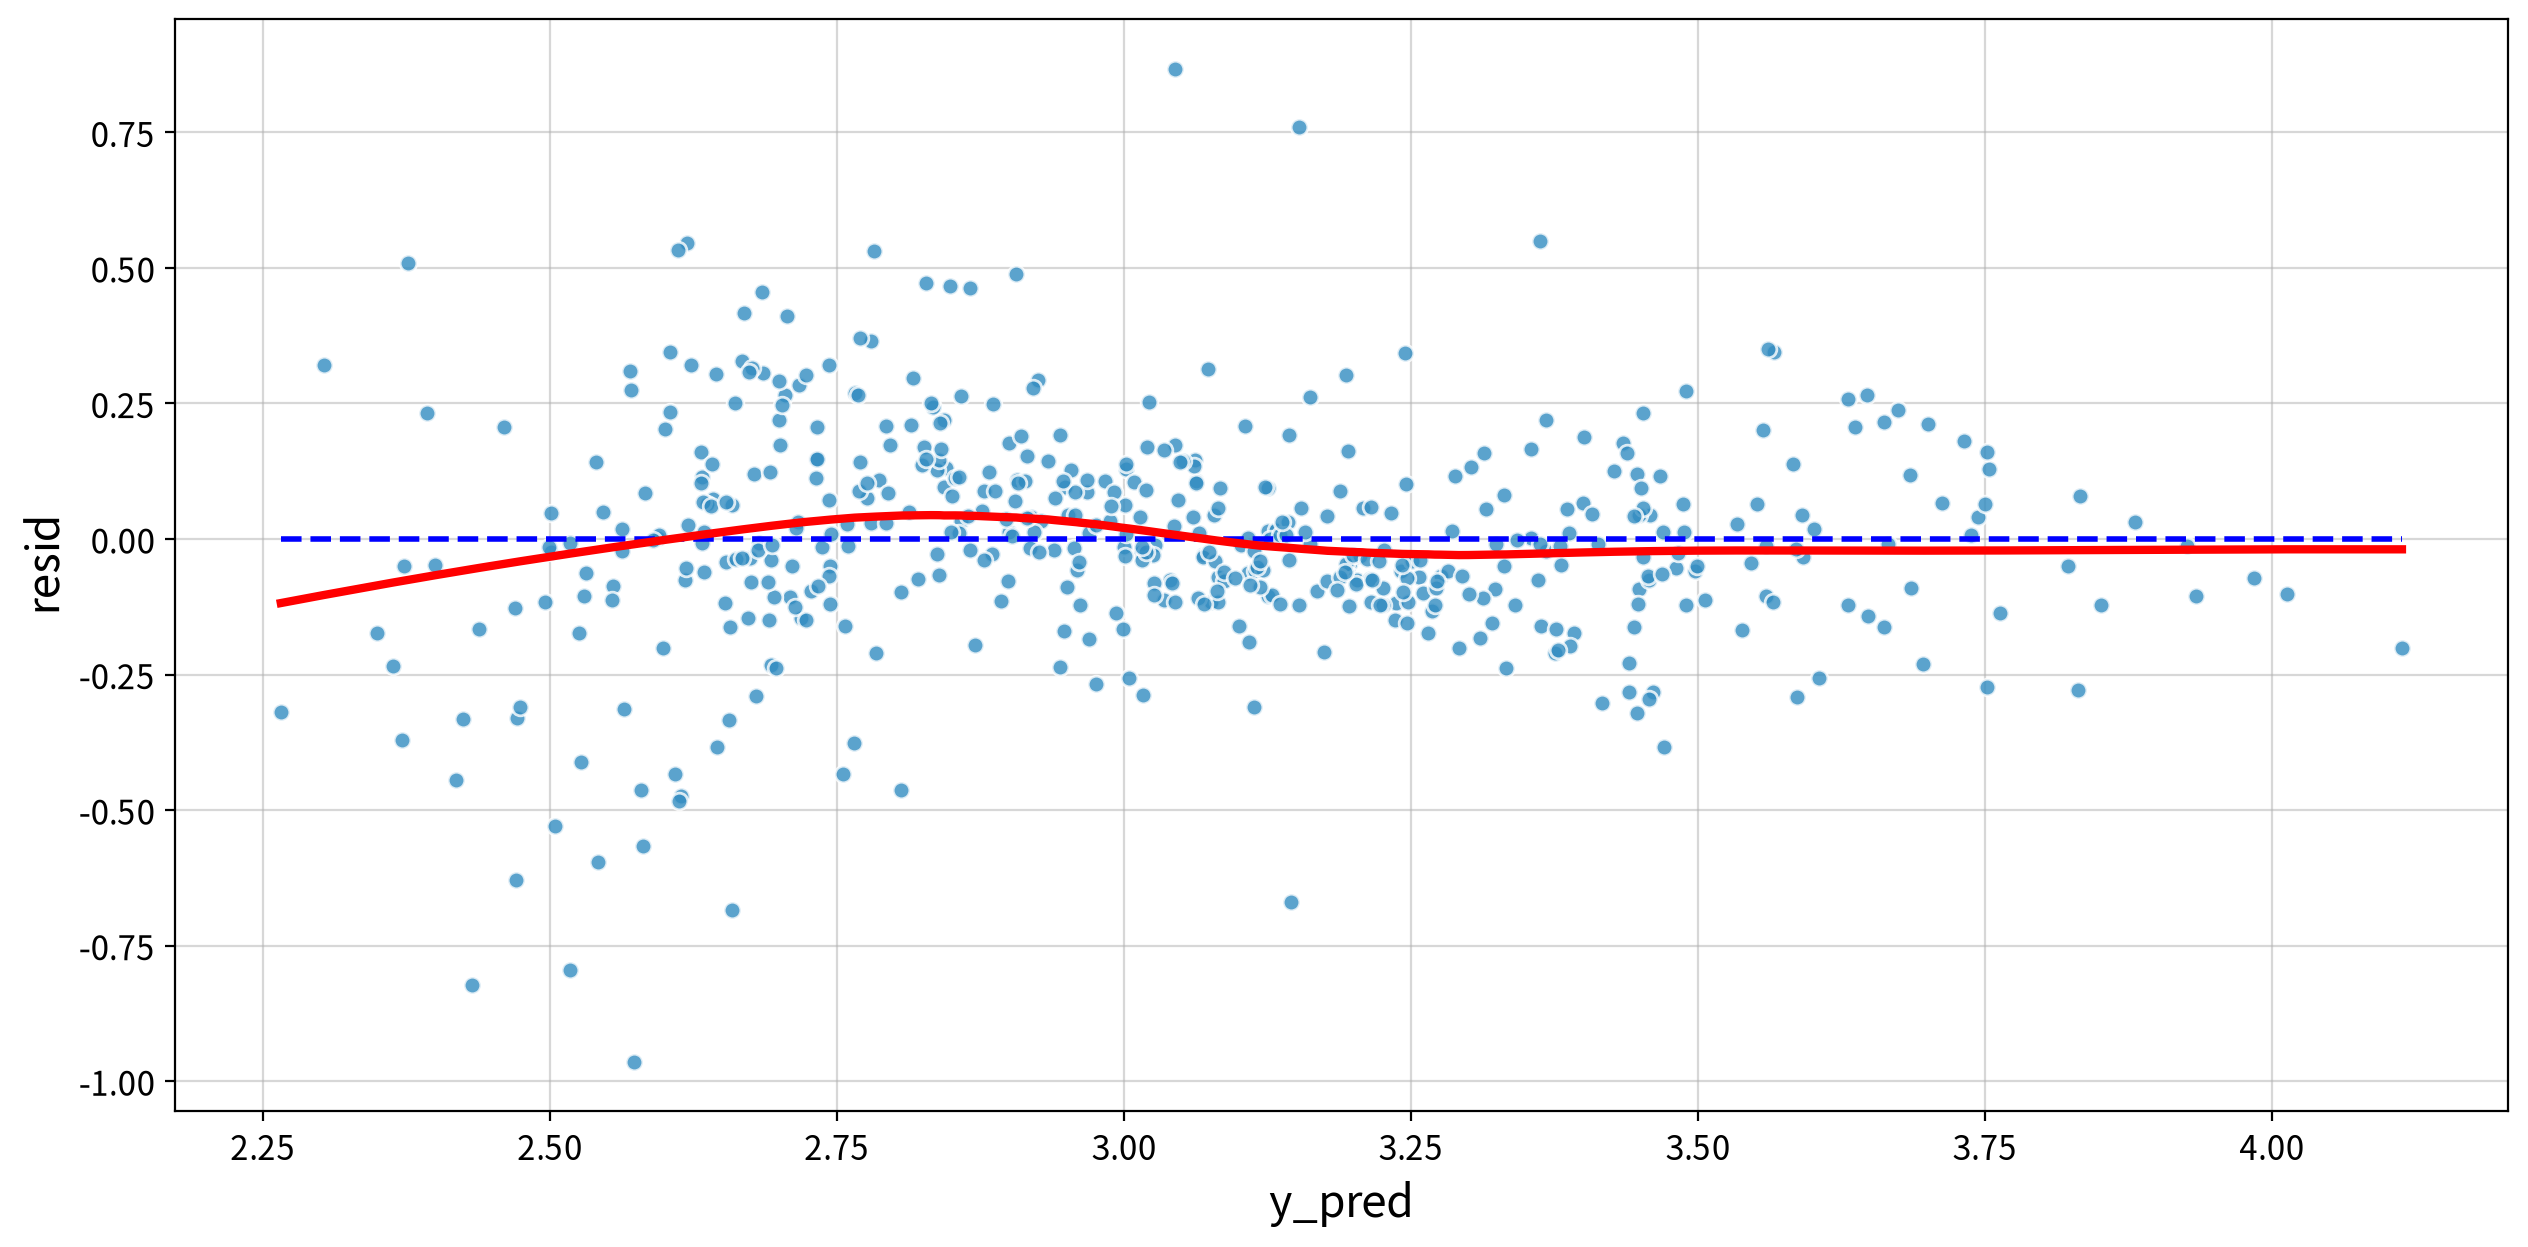

In [26]:
my_ols.test_linear(final_fit)

**판정:** **위반** — 근거:

- **검정:** Ramsey RESET **F = 13.856, p < .001** → 귀무가설(선형)이 기각되었다.
- **그래프:** 잔차가 0을 중심으로 무작위로 흩어지지 않고, 예측값이 낮은 구간과 높은 구간에서 lowess 추세선이 휜다.
- **이미 한 조치:** 종속변수와 `LSTAT`·`DIS`에 로그를 씌워 곡선을 상당히 폈다(#5-2에서 RMSE 9.0% 개선).
- **남은 문제:** 그럼에도 **완전히 직선화되지는 않았다.** `MEDV` = 50 의 상한 절단값 16건이 회귀선 위쪽에서 잔차를 끌어당기는 것도 원인으로 보인다.

> **② 정규성** — 잔차의 Q-Q plot과 정규성 검정

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.099,0.000,False,대립가설 채택 → 정규성 위배


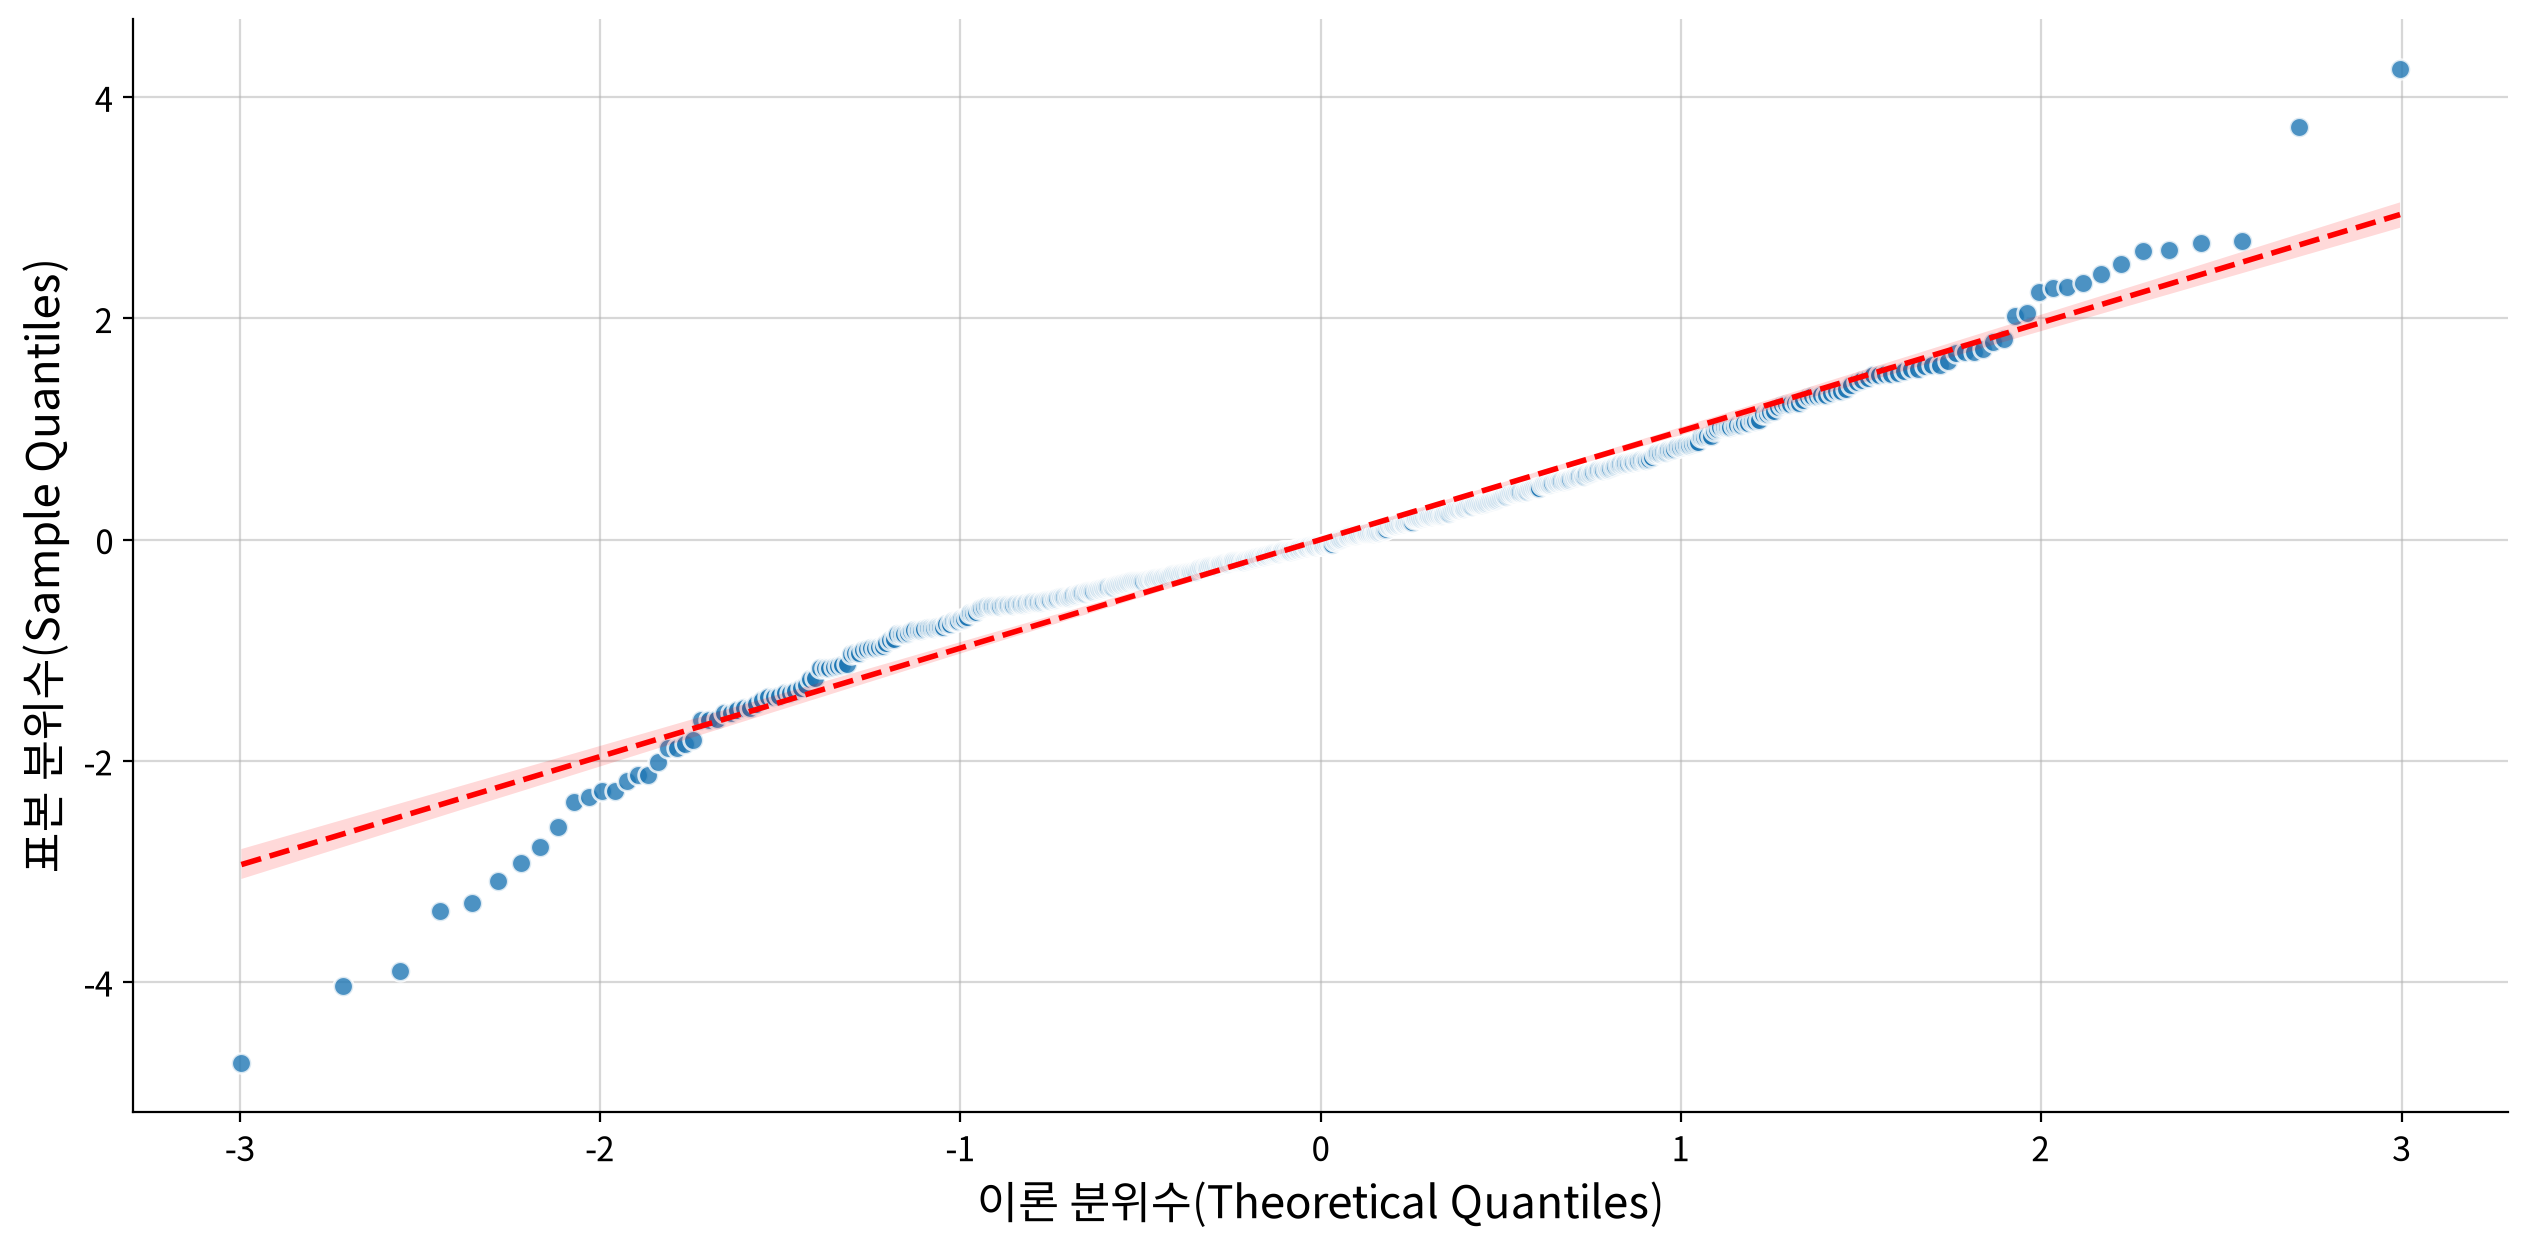

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,64~72,76.480,위배
±2√MSE,95.000,93~97,94.070,충족
±3√MSE,99.700,99~100,98.420,위배


√MSE = 0.21 · 구간 규칙 판정: 정규성 위배


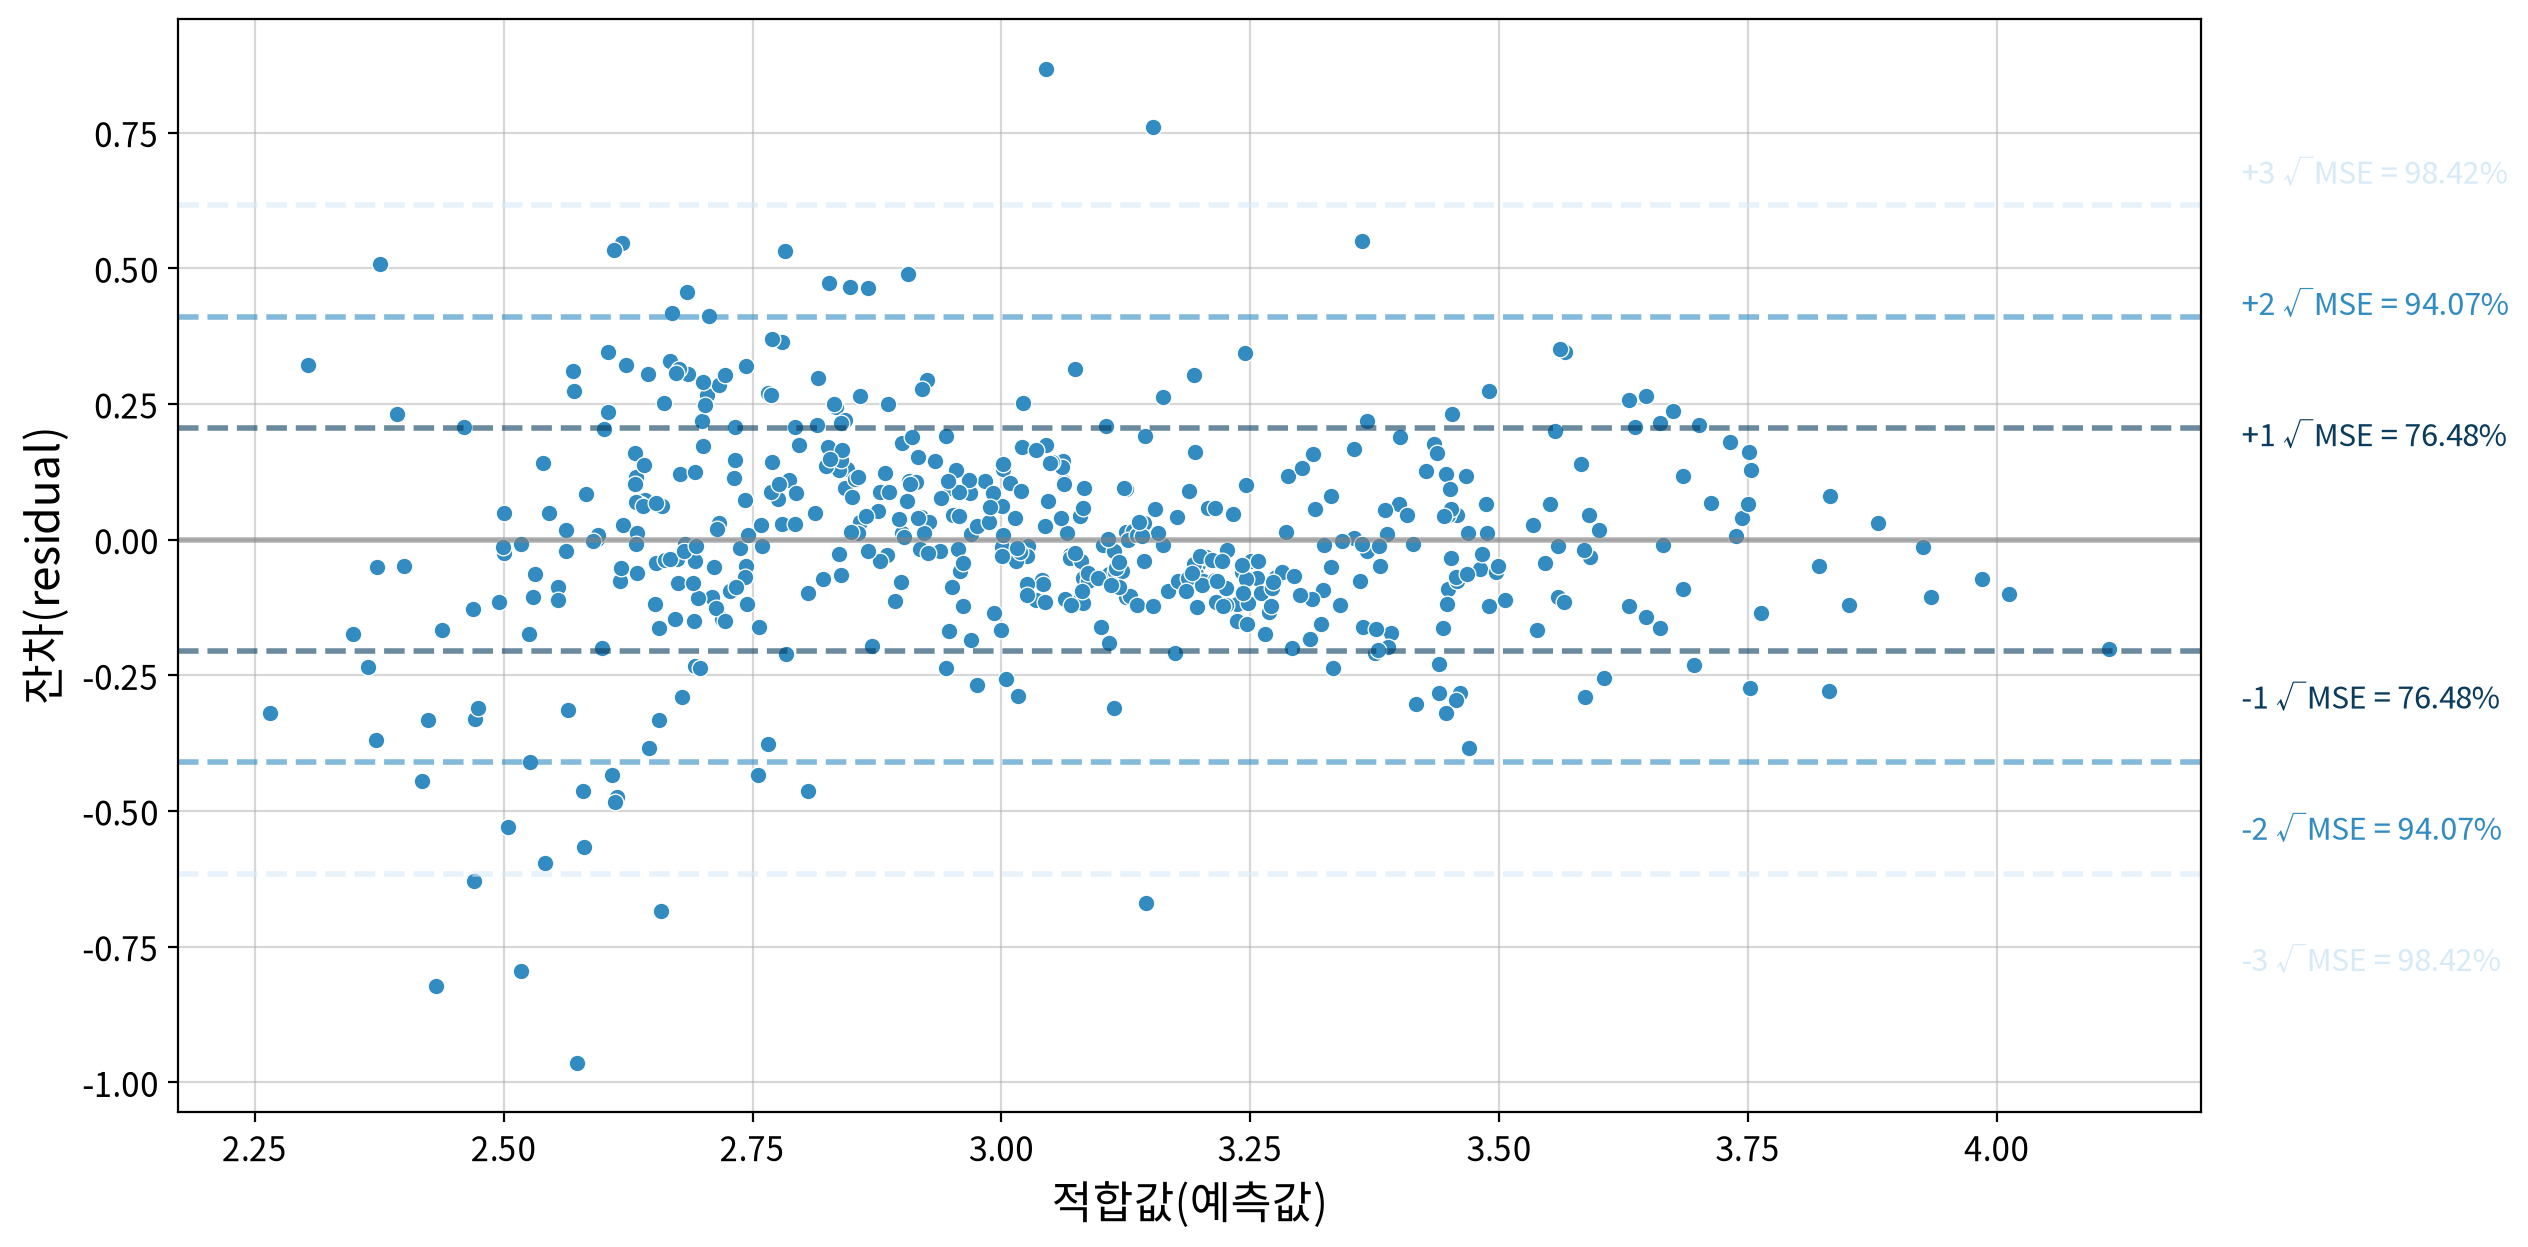

In [27]:
my_ols.test_normal(final_fit)

**판정:** **위반** — 근거:

- **검정:** n = 506 ≥ 30 이므로 Kolmogorov-Smirnov가 적용되어 **KS = 0.099, p < .001** → 정규성이 기각되었다.
- **Q-Q plot:** 중앙부에서는 직선을 잘 따라가지만 **양쪽 꼬리가 직선에서 벗어난다.**
- **√MSE 구간 규칙:** ±1√MSE 76.5%(기대 68%) / **±2√MSE 94.1%(기대 95% — 충족)** / ±3√MSE 98.4%(기대 99.7%)
- **판단:** 중앙 집중이 기대보다 강하고 꼬리가 두꺼운 형태다(첨도 6.01). **심각한 왜곡이라기보다 꼬리 이탈**로 읽는 것이 맞다.

> **③ 등분산성** — Breusch-Pagan 검정

In [28]:
my_ols.test_equalvar(final_fit)

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,85.288,0.000,14.422,0.000,False,대립가설 채택 → 등분산 아님


**판정:** **위반** — 근거:

- **검정:** Breusch-Pagan **F = 14.422, p < .001** → 등분산 가정이 기각되었다. 잔차의 분산이 예측값 구간에 따라 달라진다.
- **영향:** **계수 추정치 자체는 편향되지 않지만 표준오차가 왜곡**되어 유의성 판정을 믿을 수 없게 된다.
- **조치:** `fit_pipeline()` 이 이를 감지해 **HC3 로버스트 표준오차**로 전환했고, 후진소거의 변수 제거 기준도 HC3 p-value를 사용했다.
- **결과:** 4개 가정 중 **유일하게 조치가 완료된 항목**이다.

> **④ 독립성** — Durbin-Watson 통계량

In [29]:
my_ols.test_independent(final_fit)

,statistic,independence,result
Durbin-Watson,0.921,False,독립성 위반 (양(+)의 자기상관)


**판정:** **위반** — 근거:

- **통계량:** **DW = 0.921** — 기준 구간(1.5 ~ 2.5)을 크게 벗어난 **양(+)의 자기상관**이다.
- **원인:** 이 데이터는 시계열이 아니라 **횡단면 데이터**이고, 행이 지역 순으로 정렬되어 있다. **이웃한 구역끼리 비슷한 값을 갖는 공간적 자기상관**이 DW에 그대로 잡힌 것이다.
- **판단:** 시간 순서가 없으므로 DW를 시계열 해석의 근거로 삼을 수 없다.
- **조치:** 시계열 처리가 불가능하므로 조치 없이 **한계로 명시**한다(#7-3).

#### 6-2. 가정 위반에 대한 조치

| 위반 가정 | 조치 방법 | 실행 여부 |
|---|---|---|
| 선형성 (RESET p < .001) | 종속·독립변수 로그 변환 → RMSE 4.830 → 4.393 개선 | ✅ 실행 (위반은 잔존) |
| 정규성 (KS p < .001) | 종속변수 로그 변환(왜도 +1.11 → −0.33) | ✅ 실행 (꼬리 이탈은 잔존) |
| 등분산성 (BP p < .001) | **HC3 로버스트 표준오차** 적용 (유의성 판정·후진소거 기준 모두) | ✅ **조치 완료** |
| 독립성 (DW = 0.921) | 횡단면 데이터라 시계열 조치 불가 → 공간적 자기상관으로 해석 | ❌ 미조치 → #7-3에 명시 |

#### 6-3. 모형 수정 이력

| 모형 | 변경 내용 | 변경 이유 | 조정 R² | RMSE | AIC |
|---|---|---|---|---|---|
| v1 `0_기준선(공선성제거)` | 전체 13개 투입 + VIF 제거 + 후진소거 | 기준선 | 0.735 | 4.680 | 3021.73 |
| v2 `1_로그변환` | v1 + 로그 변환 7개 변수 | 우/좌편향과 곡선 관계 해소 | 0.757 \* | **4.336** | −174.09 \* |
| v3 `2_이상치대체` | v2 + IQR 경계값 대체 | 로그로 해소되지 않은 극단값 축소 | 0.757 \* | 4.359 | −174.37 \* |
| v4 `3_도메인_기준선` | v1에서 `INDUS`·`RAD`·`B` 도메인 제거 | 중복 축 정리 (VIF로는 안 잡힘) | 0.719 | 4.830 | 3047.77 |
| **v5 `4_도메인_로그변환`** | v4 + 로그 변환 | 변수 선택과 변환을 함께 적용 | **0.748 \*** | **4.393** | **−157.95 \*** |
| v6 `5_도메인_이상치대체` | v5 + IQR 경계값 대체 | 극단값 축소 시도 | 0.748 \* | 4.416 | −158.66 \* |

<sub>\* 종속변수가 `log(MEDV)`인 모형은 **조정 R²·AIC의 척도가 v1·v4와 다르다.** 척도를 넘나드는 비교에는 원본 단위로 되돌린 **RMSE만** 사용한다.</sub>

**최종 모형 선정 근거** (지표 + 가정 충족 + 해석 가능성)

> **v5 `4_도메인_로그변환`을 최종 모형으로 채택한다.**
>
> 1. **지표** — RMSE 4.393으로 1위 v2(4.336)와 **1.33% 격차**에 불과하다. 기준선 v1(4.680) 대비 **오차를 6.1% 줄였다.**
> 2. **간명성** — 독립변수가 **7개로 v2(10개)보다 3개 적고, 기준선 v1(11개)보다 4개 적다.** #4-4에서 정한 "근소 격차면 간명한 모형" 기준을 그대로 적용했다.
> 3. **가정** — 4개 가정 모두 형식적으로는 위반이지만, **등분산 위배는 HC3로 보정**했고 정규성은 ±2√MSE 구간에서 기대치를 충족한다. 독립성 위배는 횡단면 데이터의 성격에서 오는 것으로 조치 대상이 아니다.
> 4. **해석 가능성** — 남은 7개 변수(`LSTAT`·`DIS`·`NOX`·`TAX`·`PTRATIO`·`RM`·`CHAS`)가 **서로 다른 축**을 대표한다. VIF 제거 단계의 최대 VIF도 5.20으로 v2(7.56)보다 낮고, 최종 계수표 기준으로는 4.21까지 내려간다. 계수를 개별적으로 읽기에 더 안전하다.
> 5. **윤리** — 윤리적으로 문제가 있는 `B`가 모형에서 빠져 있다.

> 최종 모형의 성능 보고·회귀계수·영향력 순위·가정 검정을 한 번에 출력한다.

## 최종 모델: 4_도메인_로그변환

### ▶︎ 성능 보고

#### 1) 모형 적합도

**Note. n = 506. F(7, 498) = 214.6, p < 0.001, R² = 0.751, Adj.R² = 0.748, Durbin-Watson = 0.922**

log(MEDV)를 종속변수로, CHAS, NOX, RM, log(DIS), TAX, PTRATIO, log(LSTAT)(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(7, 498) = 214.6, p < 0.001, R² = 0.751.

즉, CHAS, NOX, RM, log(DIS), TAX, PTRATIO, log(LSTAT)는 log(MEDV)의 약 75.1%를 설명하는 것으로 나타났다.

#### 2) 회귀계수 보고표

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,MEDV,LSTAT,-0.406,0.025,0.038,-0.597,-16.246,-10.803,0.000,0.000,0.371,2.699
1,MEDV,DIS,-0.164,0.031,0.036,-0.216,-5.255,-4.528,0.000,0.000,0.295,3.387
2,MEDV,NOX,-0.646,0.162,0.174,-0.183,-3.991,-3.709,0.000,0.000,0.238,4.210
3,MEDV,TAX,-0.000,0.000,0.000,-0.154,-4.511,-4.253,0.000,0.000,0.428,2.336
4,MEDV,PTRATIO,-0.027,0.005,0.004,-0.142,-5.178,-6.445,0.000,0.000,0.665,1.505
5,MEDV,RM,0.077,0.018,0.027,0.133,4.356,2.886,0.000,0.004,0.536,1.865
6,MEDV,CHAS,0.124,0.037,0.039,0.077,3.369,3.163,0.001,0.002,0.952,1.051


#### 3) 영향력 순위 시각화 (표준화 계수 β)

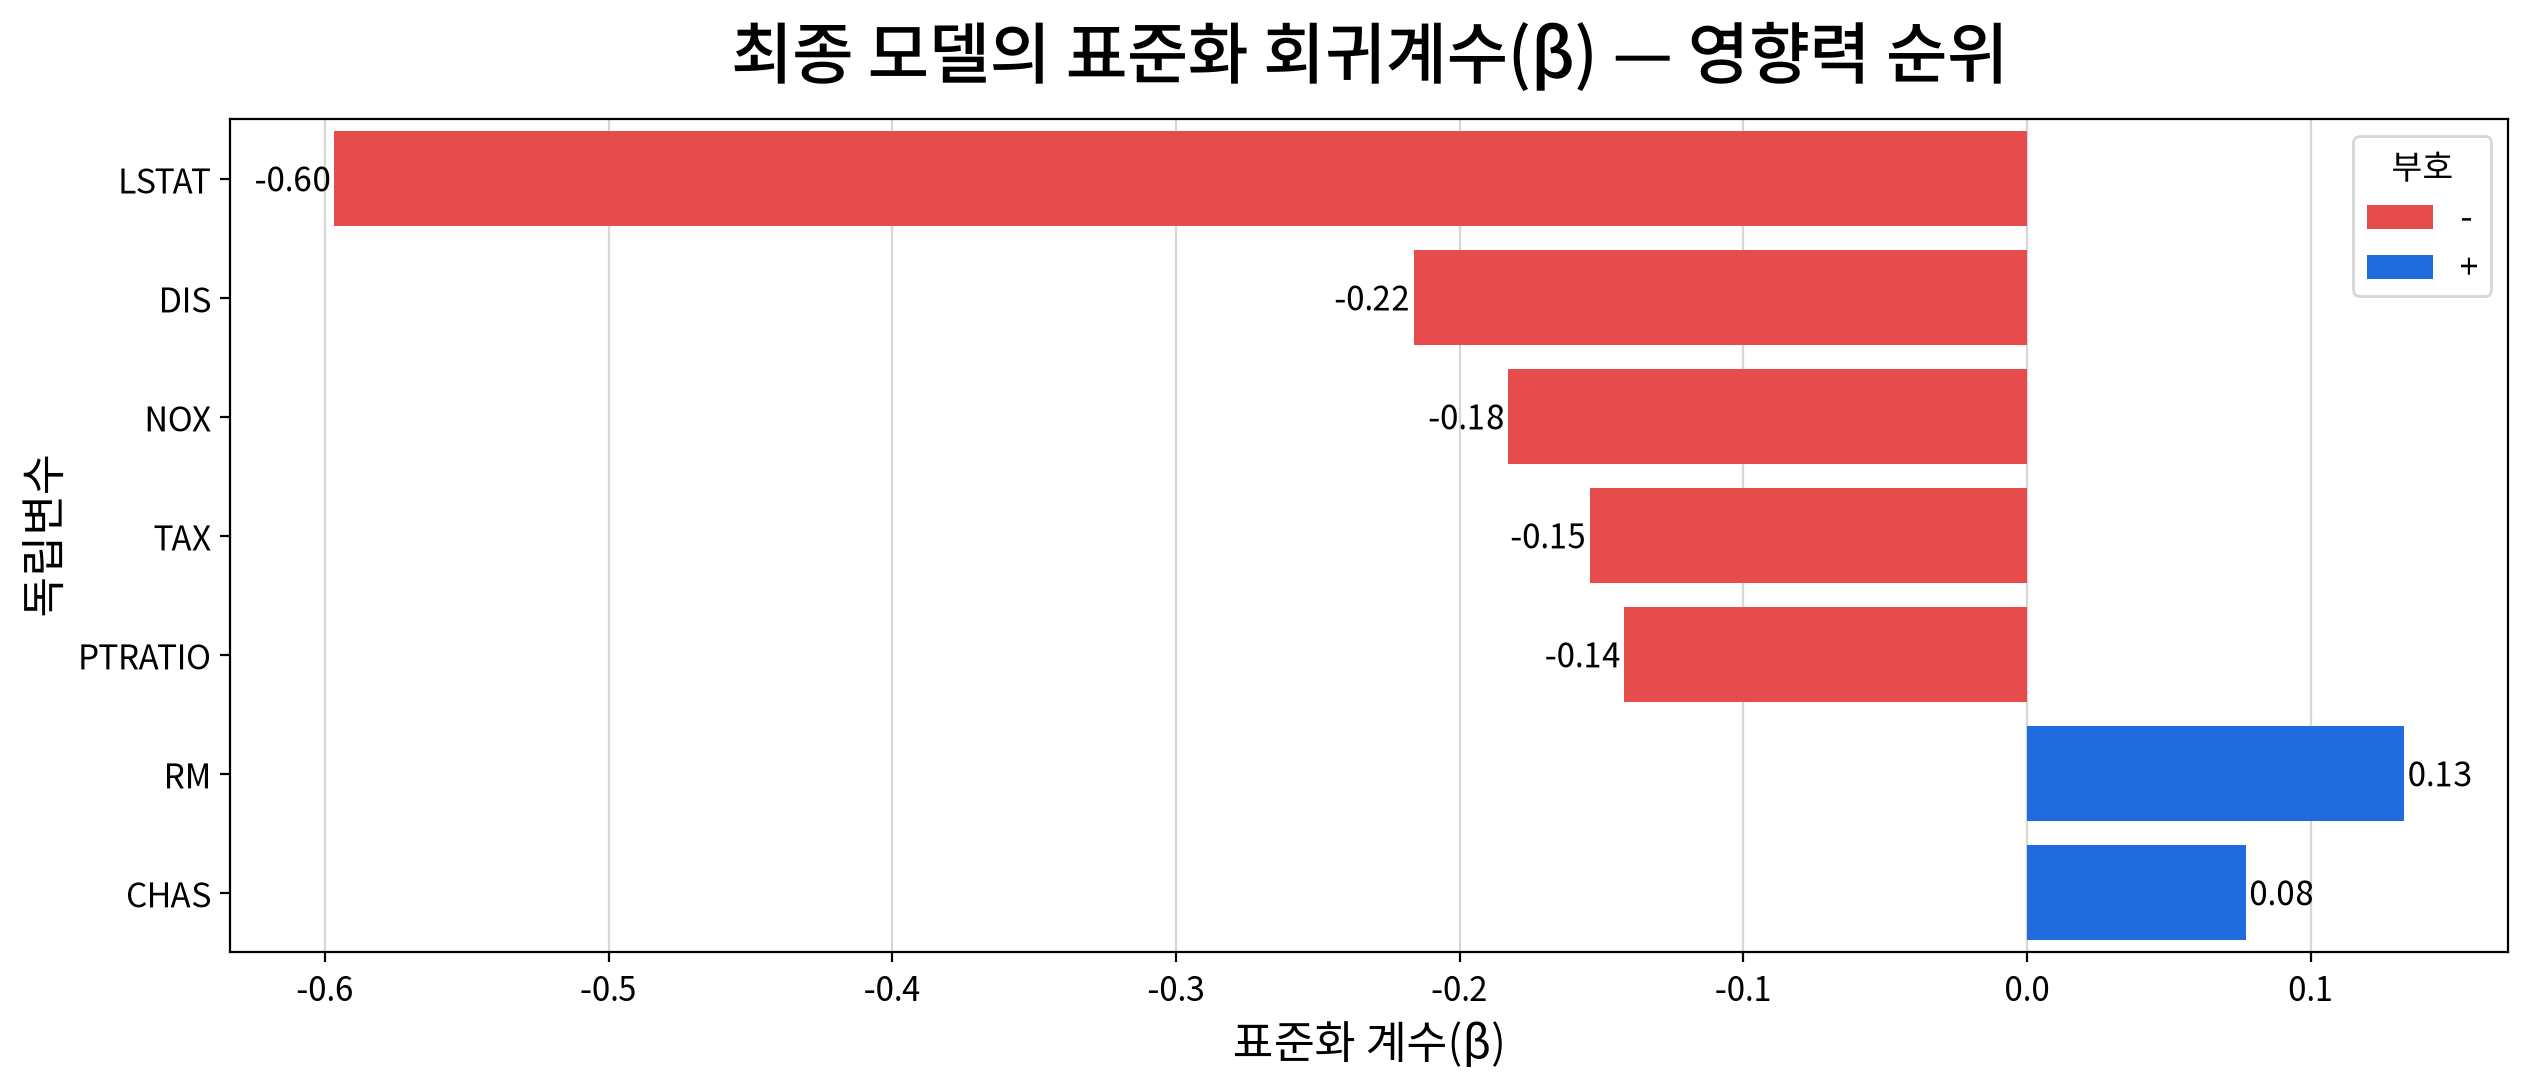

#### 4) 회귀계수 해석 문장

- **CHAS**의 회귀계수는 **B = 0.12**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(498) = 3.16**, **p = .002**)      
즉, CHAS가 **1 증가**할 때 MEDV는 평균적으로 약 **13.23% 증가**하는 것으로 해석된다.
- **NOX**의 회귀계수는 **B = -0.65**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(498) = -3.71**, **p < .001**)      
즉, NOX가 **1 증가**할 때 MEDV는 평균적으로 약 **47.58% 감소**하는 것으로 해석된다.
- **RM**의 회귀계수는 **B = 0.08**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(498) = 2.89**, **p = .004**)      
즉, RM가 **1 증가**할 때 MEDV는 평균적으로 약 **8.05% 증가**하는 것으로 해석된다.
- **DIS**의 회귀계수는 **B = -0.16**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(498) = -4.53**, **p < .001**)      
즉, DIS가 **1% 증가**할 때 MEDV는 평균적으로 약 **0.16% 감소**하는 것으로 해석된다.
- **TAX**의 회귀계수는 **B = -0.0**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(498) = -4.25**, **p < .001**)      
즉, TAX가 **1 증가**할 때 MEDV는 평균적으로 약 **0.04% 감소**하는 것으로 해석된다.
- **PTRATIO**의 회귀계수는 **B = -0.03**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(498) = -6.44**, **p < .001**)      
즉, PTRATIO가 **1 증가**할 때 MEDV는 평균적으로 약 **2.65% 감소**하는 것으로 해석된다.
- **LSTAT**의 회귀계수는 **B = -0.41**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(498) = -10.8**, **p < .001**)      
즉, LSTAT가 **1% 증가**할 때 MEDV는 평균적으로 약 **0.41% 감소**하는 것으로 해석된다.

> ※ **log1p**(=ln(1+·))의 % 해석은 변수 자체가 아니라 **(1+변수)** 기준이며, 값이 클 때만 위 근사가 성립한다.      
(0·작은 값 구간에서는 원본처럼 동작해 부정확)      
이 구간에서는 부호·유의성 중심으로 해석하거나 예측값을 expm1로 원 척도에서 비교한다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다.     
회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며,     
표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

---

### ▶︎ 회귀모형 가정 검정

#### 1) 선형성 검정

,statistic,p-value,linearity,result
Ramsey RESET,13.856,0.000,False,대립가설 채택 → 선형성 위배(곡선 관계 존재)


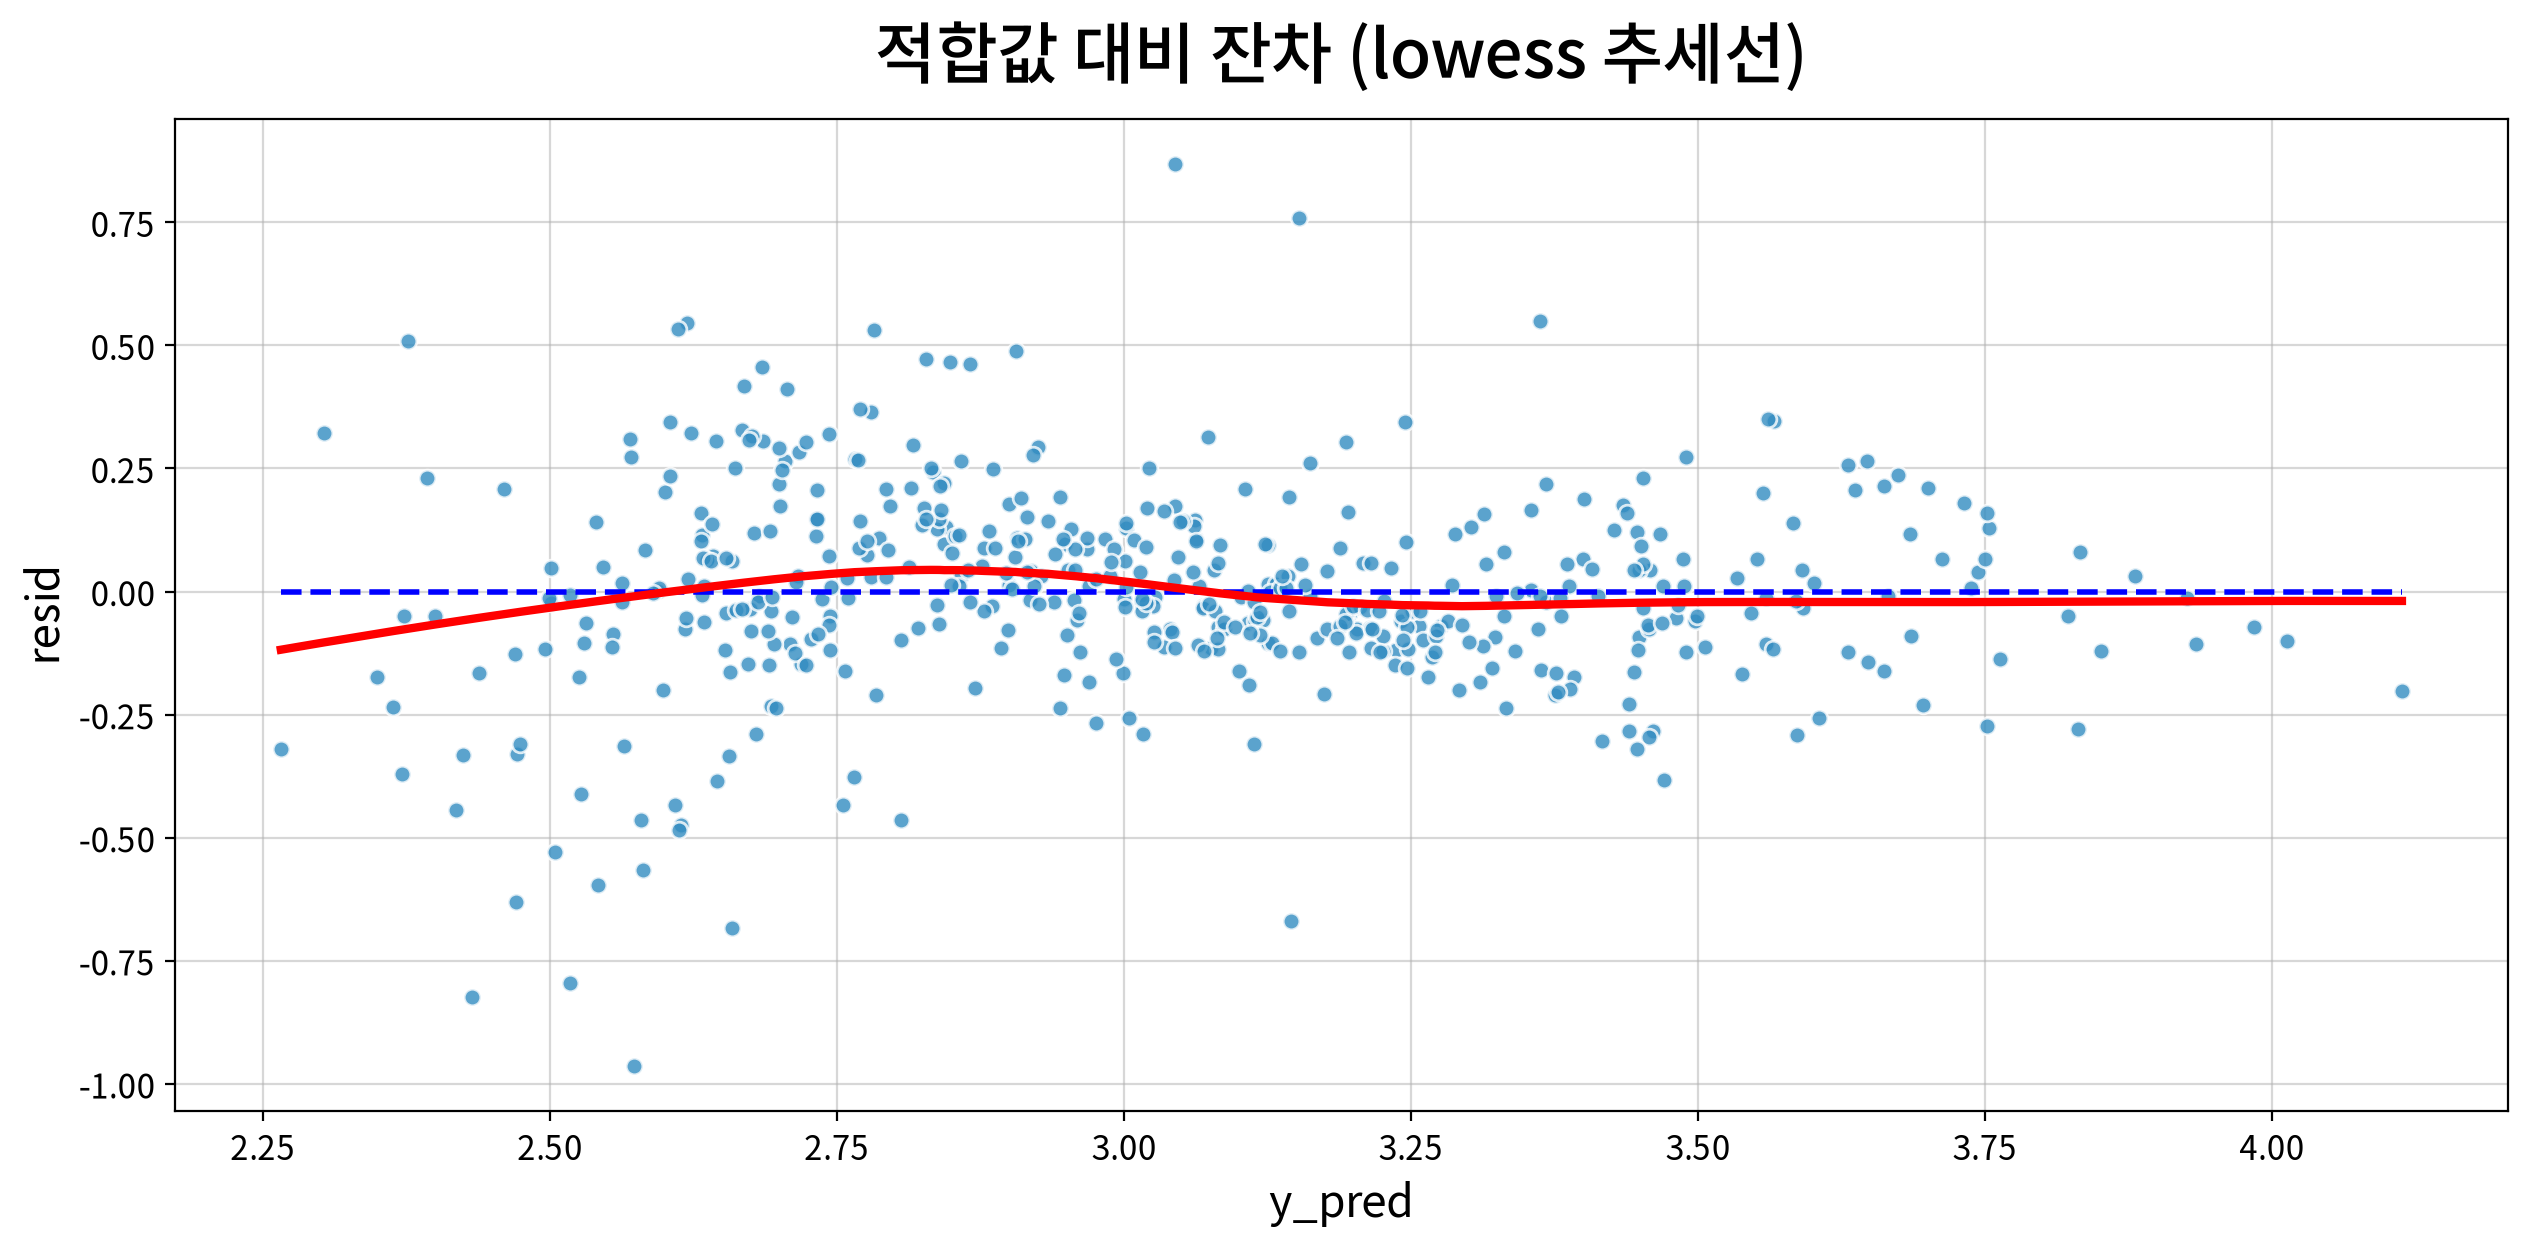

#### 2) 정규성 검정

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.099,0.000,False,대립가설 채택 → 정규성 위배


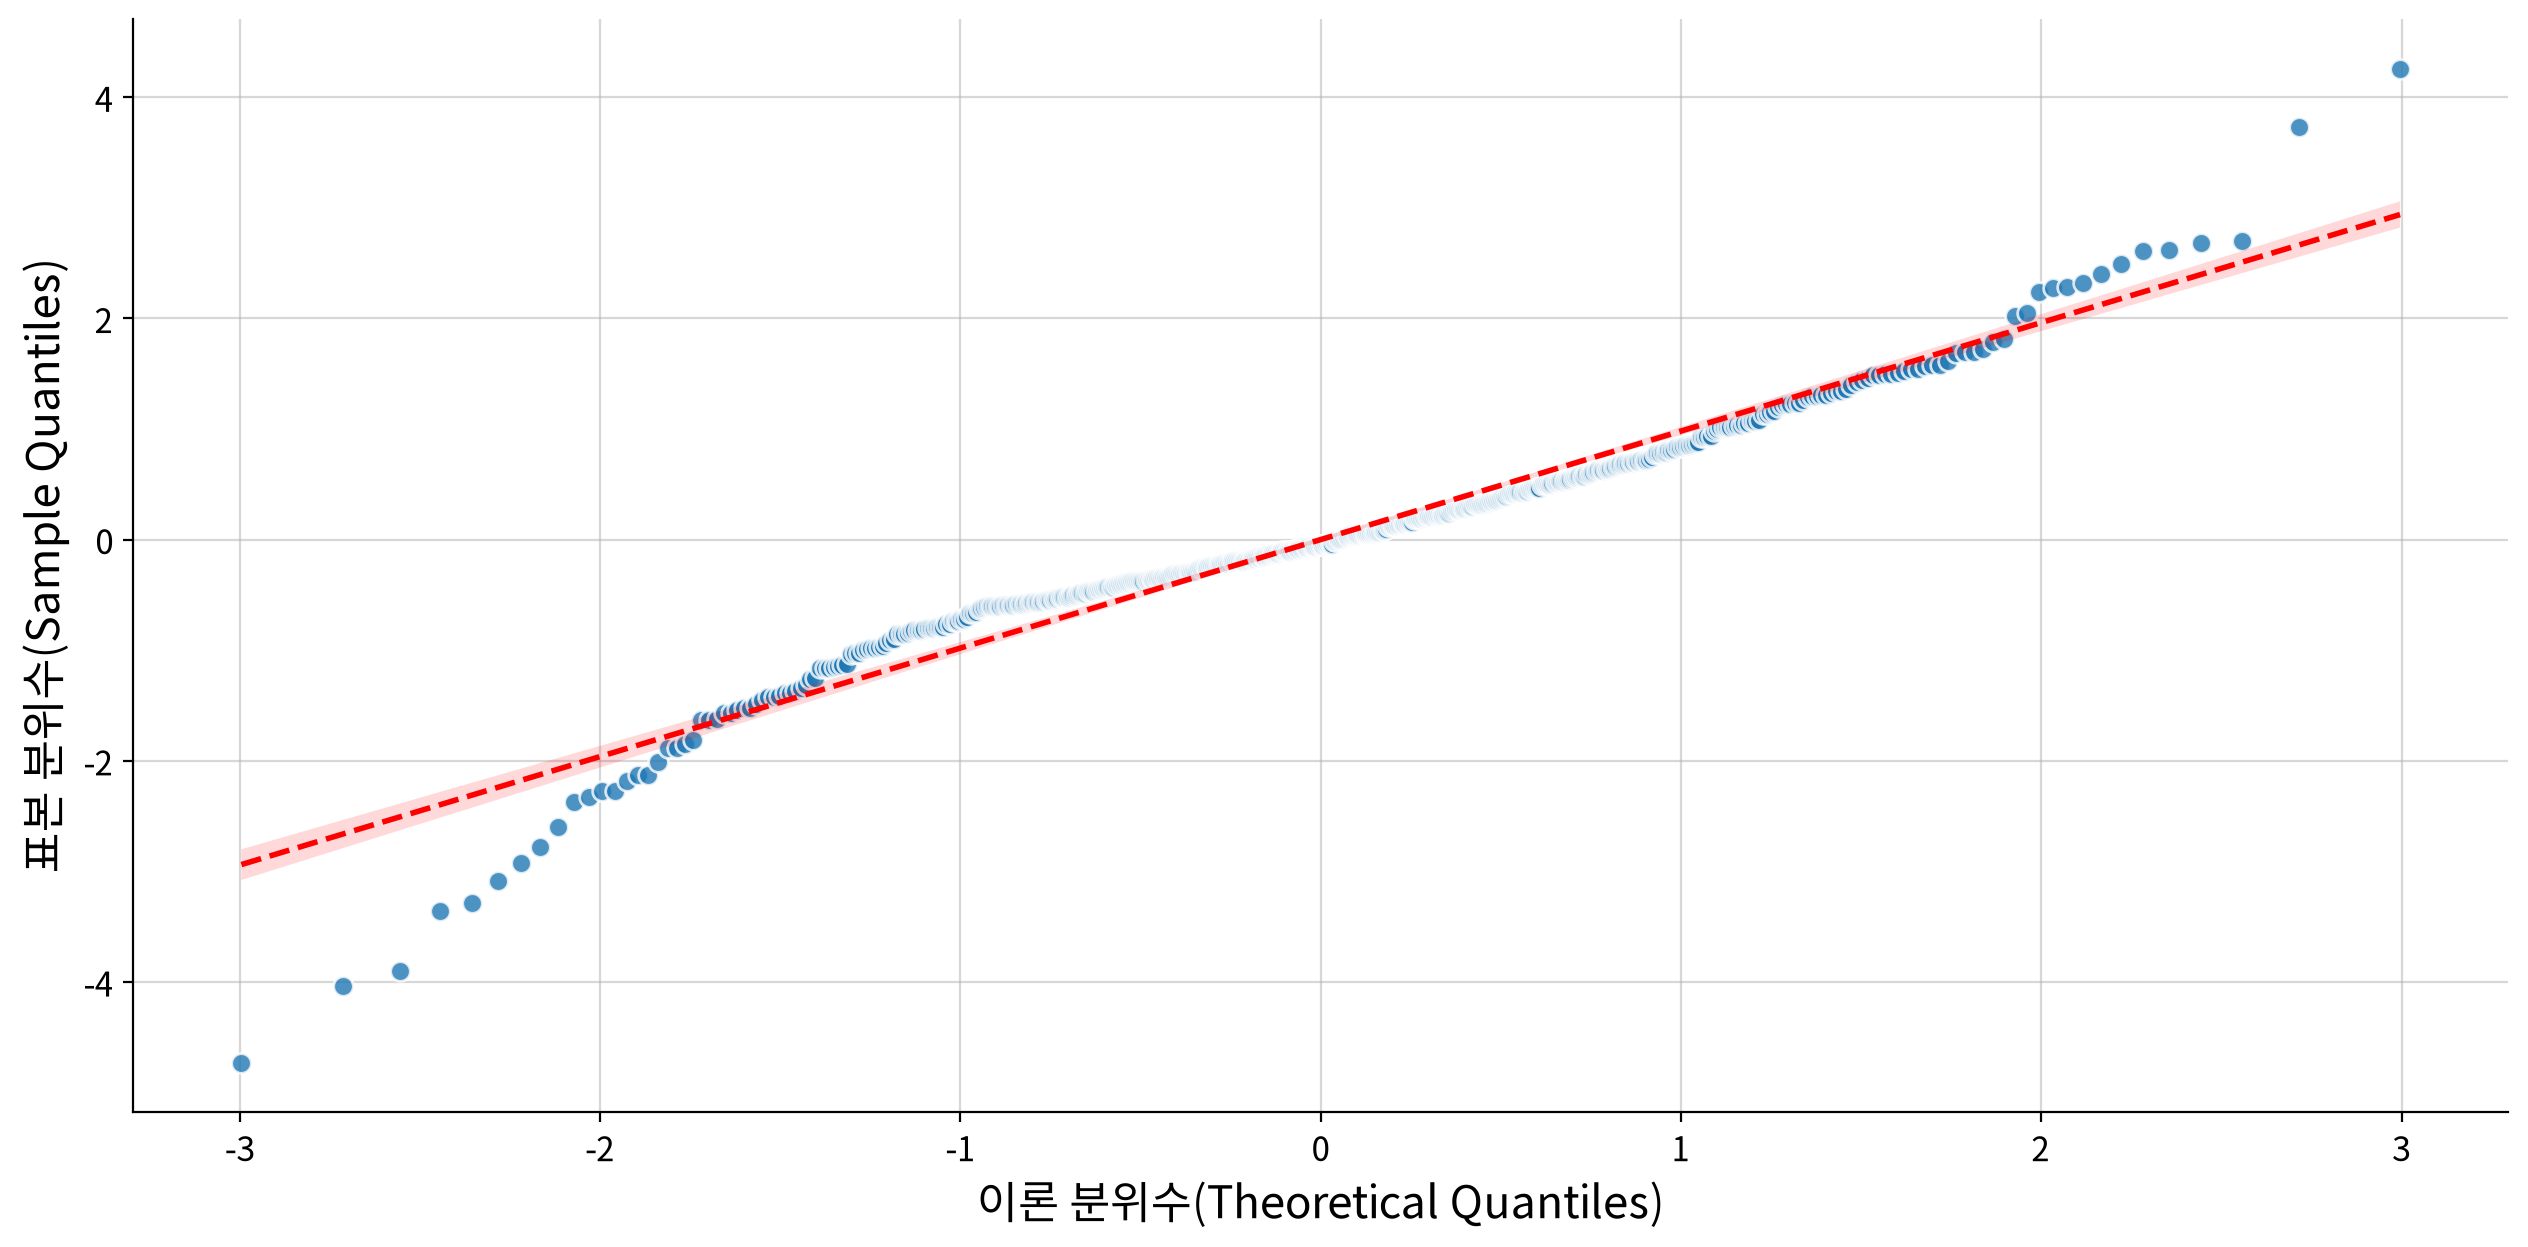

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,64~72,76.480,위배
±2√MSE,95.000,93~97,94.070,충족
±3√MSE,99.700,99~100,98.420,위배


√MSE = 0.21 · 구간 규칙 판정: 정규성 위배


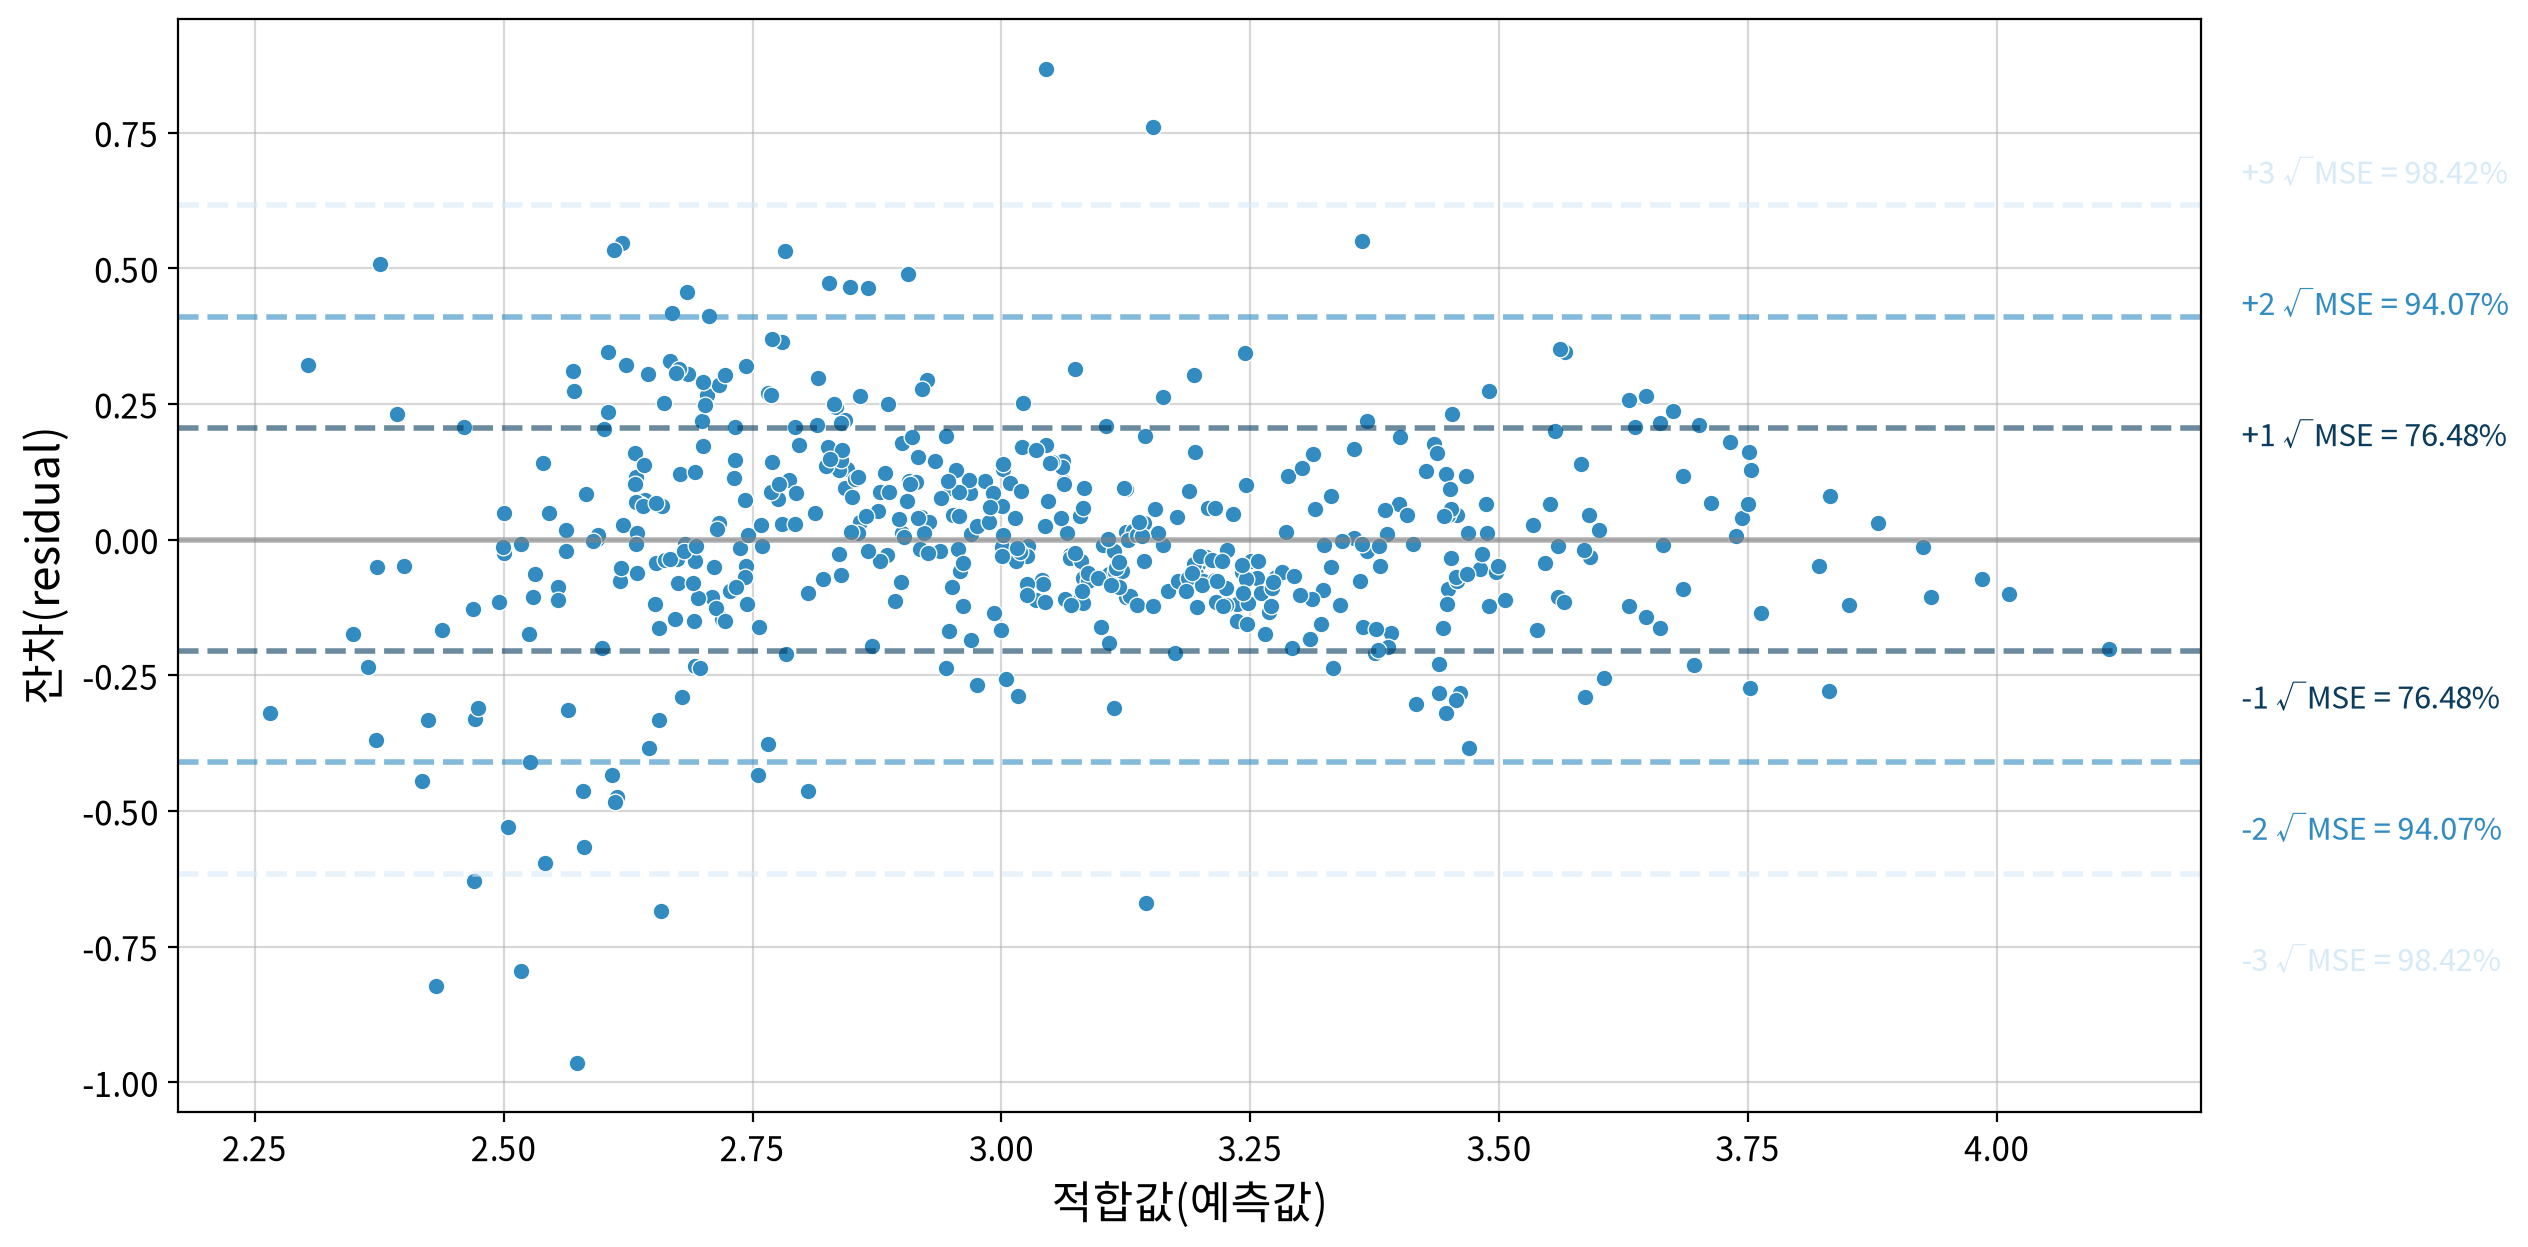

#### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,85.288,0.000,14.422,0.000,False,대립가설 채택 → 등분산 아님


#### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,0.921,False,독립성 위반 (양(+)의 자기상관)


In [30]:
my_ols.report_model(final_fit)

**해석**

- **모형:** `log(MEDV) ~ CHAS + NOX + RM + log(DIS) + TAX + PTRATIO + log(LSTAT)`
- **적합도:** **F(7, 498) = 214.6, p < .001, R² = 0.751, 조정 R² = 0.748.** 7개 변수가 `log(MEDV)` 분산의 **75.1%** 를 설명한다.
- **유의성:** **7개 변수 전부 유의**하다(HC3 기준 p < .005). 버릴 변수가 하나도 남지 않은 상태다.
- **예측 성능:** 원본 척도로 되돌린 RMSE = 4.393천 달러, MAE = 3.058천 달러. 평균적으로 **약 3,058달러의 오차**로 구역별 중위가격을 맞춘다(전체 평균 22.5천 달러의 **13.6%** 수준).
- **공선성:** 최종 계수표 기준 최대 VIF는 **4.21(`NOX`)**, 그다음이 `DIS` 3.39로 기준 10에 여유가 있다.
  (파이프라인 로그의 5.20은 후진소거 *이전* 9변수 시점의 값이다.)

---
## #7. 결과 해석

#### 7-1. 회귀계수 해석

> 계수표(B · 표준오차 · 표준화계수 β · t · 유의확률 · 공차 · VIF), **표준화계수 막대그래프**, 계수 해석 문장은
> 모두 **#6 마지막의 `report_model()` 출력**에 포함되어 있다. 아래는 그 결과를 도메인 언어로 옮긴 것이다.

최종 모형은 **로그-로그 혼합 모형**이므로 변수마다 읽는 법이 다르다.

- **로그를 씌운 변수**(`LSTAT`, `DIS`) → **% ↔ % (탄력성)**
- **로그를 씌우지 않은 변수**(`CHAS`, `NOX`, `RM`, `TAX`, `PTRATIO`) → **1단위 증가 → % 변화**

**계수 해석**

| 변수 | 계수(B) | 표준화계수(β) | p-value(HC3) | 해석 (1단위 증가 시 효과) |
|---|---|---|---|---|
| `LSTAT` | −0.406 | **−0.597** | < .001 | 저소득층 비율이 **1% 늘면 가격 0.41% 하락** |
| `DIS` | −0.164 | −0.216 | < .001 | 고용센터까지 거리가 **1% 멀어지면 가격 0.16% 하락** |
| `NOX` | −0.646 | −0.183 | < .001 | 질소산화물 농도가 **0.1 오르면 가격 약 6.3% 하락** (1 단위면 47.6% 하락) |
| `TAX` | −0.0004 | −0.154 | < .001 | 재산세율이 $10,000당 **1 오르면 가격 0.04% 하락** ($100 오르면 약 3.7% 하락) |
| `PTRATIO` | −0.027 | −0.142 | < .001 | 학생-교사 비율이 **1명 늘면 가격 2.65% 하락** |
| `RM` | +0.077 | +0.133 | .004 | 방이 **1개 늘면 가격 8.05% 상승** |
| `CHAS` | +0.124 | +0.077 | .002 | 찰스강에 **인접하면 가격 13.23% 높음** (비인접 기준 대비) |

**영향력 순위 (표준화계수 기준):** 1위 ( `LSTAT` −0.597 ) > 2위 ( `DIS` −0.216 ) > 3위 ( `NOX` −0.183 )

**해석에서 주의할 점 두 가지**

1. **`LSTAT`이 압도적이다.** β = −0.597로 2위 `DIS`(−0.216)의 **2.8배**다. 나머지 6개 변수의 β를 모두 더해도(0.905) `LSTAT` 하나의 1.5배에 그친다.
2. **`DIS`의 부호가 상식과 반대로 보인다.** "고용센터에서 멀수록 싸다"는 결과인데, 단변량 상관에서는 ρ = +0.446으로 **거리가 멀수록 비쌌다.**
   `NOX`·`LSTAT`을 통제하면 방향이 뒤집힌다 — 교외가 비싼 이유는 거리 자체가 아니라 **공기가 깨끗하고 저소득층 비율이 낮기 때문**이며,
   그 두 조건이 같다면 도심 접근성이 좋은 쪽이 비싸다는 뜻이다. **단변량 상관과 다변량 계수는 다른 질문에 답한다**는 것을 보여주는 사례다.

#### 7-2. 질문별 답변과 가설 판정

**Q1. 주택 중위가격을 가장 크게 좌우하는 요인은 무엇인가?**
- 근거: 표준화계수 `LSTAT` β = **−0.597** 로 2위 `DIS`(−0.216)의 **2.8배**다. 단변량 상관에서도 ρ = −0.853으로 12개 중 **유일한 Strong 등급**이었다.
- **답:** **저소득층 인구 비율(`LSTAT`)** 이다. 저소득층 비율이 1% 증가할 때 주택 중위가격은 평균 0.41% 하락한다.

**Q2. 주택 자체의 특성(`RM`)과 동네의 사회경제적 특성(`LSTAT`) 중 무엇이 가격을 더 잘 설명하는가?**
- 근거: β 기준 `LSTAT`(−0.597)이 `RM`(+0.133)의 **4.5배**다. `RM`은 7개 변수 중 6위이며, `DIS`·`NOX`·`TAX`·`PTRATIO`에 모두 밀린다.
- **답:** **동네의 사회경제적 특성이 압도적으로 우세하다.** 방을 한 개 더 늘리면 가격이 8.1% 오르지만, 저소득층 비율이 20% 높은 동네로 옮기면 그 이점이 상쇄된다.
  "집을 사는 것이 아니라 동네를 산다"는 부동산 격언이 이 데이터에서는 수치로 확인된다.

**Q3. 기계적인 변수 선택과 도메인 지식에 근거한 제거 중 어느 쪽이 나은가?**
- 근거: VIF는 최대 8.88로 **단 한 번도 변수를 제거하지 않았다.** 반면 `NOX`–`DIS` 쌍별 상관은 −0.880으로 매우 강했다.
  도메인 지식으로 `INDUS`·`RAD`·`B`를 직접 제거하자 최대 VIF가 **7.56 → 5.20**으로 내려갔고, 변수 3개를 덜 쓰고도 RMSE 손해는 1.33%에 그쳤다.
- **답:** **둘은 대체재가 아니라 보완재다.** 기계적 기준은 "무엇이 통계적으로 중복인지"를 판정하지만 **쌍별 상관이 강해도 VIF 기준에 못 미치면 아무것도 지우지 않는다.**
  무엇을 남길지 정하는 것은 도메인 지식의 몫이다. 다만 도메인 제거만으로는 부족했다 — `3_도메인_기준선`은 6개 모형 중 꼴찌였고, **로그 변환을 더한 뒤에야** 1위가 되었다.

**가설 판정**

| 가설 | 채택 / 기각 | 근거 |
|---|---|---|
| H1. 방 개수 ↑ → 가격 ↑ | **채택** | B = +0.077, p = .004 (방 1개당 +8.05%). 단 영향력 순위는 6위로 예상보다 낮다 |
| H2. 저소득층 비율 ↑ → 가격 ↓ | **채택** | B = −0.406, β = −0.597, p < .001 — 최대 영향 변수 |
| H3. 오염·범죄 ↑ → 가격 ↓ | **부분 채택** | `NOX` B = −0.646(p < .001)로 채택. 그러나 `CRIM`은 `NOX`·`LSTAT` 통제 후 유의성을 잃어(p = .350) 최종 모형에서 **제외**되었다 |
| H4. 찰스강 인접 → 가격 ↑ | **채택** | 단변량 T-Test p = .002, 다변량에서도 B = +0.124, p = .002 (인접 시 +13.23%) |

**핵심 인사이트**

1. **가격을 정하는 것은 건물이 아니라 동네다.** `LSTAT`의 β(−0.597)는 `RM`(+0.133)의 4.5배이며, 나머지 6개 변수를 다 합쳐도 1.5배에 못 미친다.
2. **단변량 상관만 보면 판단을 그르친다.** `DIS`는 **부호 자체가 뒤집혔고**(ρ = +0.446 → B = −0.164), `CRIM`은 ρ = −0.559로 유의했지만 통제 후 설명력을 잃었다. 다중회귀는 "다른 조건이 같을 때"라는 전혀 다른 질문에 답한다.
3. **VIF만 믿으면 중복을 놓친다.** 쌍별 상관이 −0.880이어도 VIF는 8.88로 기준 10 미만이라 아무것도 제거되지 않았다. 무엇을 남길지는 결국 도메인 지식이 정한다.
4. **변수 선택과 변환은 함께 가야 한다.** 도메인 제거만 한 모형은 6개 중 꼴찌(4.830)였지만, 로그 변환을 더하자 1위(4.393)가 되었다.

#### 7-3. 활용과 한계

**활용**

- **적용 범위:** **1970년 보스턴 광역권의 구역 단위 가격 구조를 설명하는 용도**에 한정된다.
- **계수의 의미:** "당시 이 지역에서 어떤 특성이 가격과 함께 움직였는가"를 보여주는 **기술적 요약**이다.
- **적절한 쓰임새:** 선형회귀의 전 과정(품질 점검 → EDA → 모델링 → 진단 → 해석)을 점검하기 위한 **학습용 사례**.

**한계**

- **데이터:** 1970년 인구조사 기반의 횡단면 데이터이며 관측 단위가 개별 주택이 아니라 **인구조사 구역**이다.
  - 개별 주택 가격 예측에는 쓸 수 없고(생태학적 오류), 현재 시장이나 다른 도시로 외삽할 수도 없다.
  - **`MEDV`의 상한 절단값 16건을 삭제하지 않고 그대로 사용했다.** 실제 가격을 알 수 없는 값이 회귀선을 아래로 끌어당기므로, **고가 구간의 계수는 과소추정되어 있을 가능성이 크다.** 삭제한 버전과 비교해 보는 것이 다음 과제다.
  - `B`는 인종 구성을 지수화한 변수로 오늘날 사용이 부적절하다. 최종 모형에서는 도메인 판단으로 제거했으나 **모형 탐색 과정에는 포함되었음**을 밝힌다.
- **가정:** 4개 가정이 모두 형식적으로 위반되었다.
  - **등분산 위배는 HC3 로버스트 표준오차로 보정**했다.
  - **선형성 위배(RESET p < .001)는 조치하지 못했다.** 로그 변환으로 상당 부분 폈지만 잔존 곡선 관계만큼 예측 오차가 남아 있다.
  - **독립성 위배(DW = 0.921)도 조치하지 못했다.** 횡단면 데이터라 시계열 처리가 불가능하며, 이웃 구역 간 공간적 자기상관으로 추정된다.
    공간 상관이 존재하면 **표준오차가 과소추정**될 수 있으므로, 상대적으로 약한 유의성(`RM` p = .004, `CHAS` p = .002)은 특히 조심해서 읽어야 한다.
  - 정규성 위배는 꼬리 이탈 수준으로, n = 506의 대표본에서는 계수 추정에 미치는 영향이 작다.
- **해석:** 모든 결과는 **인과가 아니라 연관 관계**다. "저소득층 비율을 낮추면 집값이 오른다"는 정책적 결론을 내릴 수 없다.
  - 또한 이 분석은 학습/검증 분할 없이 전체 데이터로 적합했으므로, RMSE·MAE는 **학습 데이터 기준 값**이다. 새로운 지역에 대한 일반화 성능이 아니다.

**다음에 시도할 것**

- **상한 절단값 처리:** `MEDV` = 50 인 16건을 삭제한 데이터로 같은 파이프라인을 돌려, 선형성 위배와 고가 구간 과소예측이 개선되는지 확인한다.
- **잔존 선형성 위배:** `LSTAT`의 구간 분할이나 다항항·교호작용을 검토한다.
- **공간적 자기상관:** 행 순서를 무작위로 섞어 DW를 다시 확인하거나, 좌표 정보를 붙여 공간회귀로 확장한다.
- **일반화 성능:** 학습/검증 분할과 교차검증을 도입해 RMSE를 일반화 가능한 값으로 다시 측정한다.